In [7]:
import pandas as pd
import numpy as np

calls = pd.read_excel(
    r'C:\Users\Acer\Projekt\Output\calls_cleaned062.xlsx',
    engine='openpyxl'
).copy()

contacts = pd.read_excel(
    r'C:\Users\Acer\Projekt\Output\contacts_cleaned062.xlsx',
    engine='openpyxl'
).copy()

spend = pd.read_excel(
    r'C:\Users\Acer\Projekt\Output\spend_cleaned062.xlsx',
    engine='openpyxl'
).copy()

deals = pd.read_excel(
    r'C:\Users\Acer\Projekt\Output\deals_cleaned062.xlsx',
    engine='openpyxl'
).copy()

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Block 1

## Zeitreihenanalyse

1.Analysieren Sie den Trend der Deal-Erstellung im Zeitverlauf und untersuchen Sie dessen Zusammenhang mit der Anzahl der Telefonanrufe. Ziel ist es zu verstehen, ob Veränderungen in der Aktivität der Anrufe mit der Anzahl neu erstellter Deals korrelieren.

2.Untersuchen Sie die Verteilung der Deal-Abschlusszeiten sowie die Dauer des Zeitraums zwischen Erstellung und Abschluss eines Deals. Dadurch lässt sich analysieren, wie lange Deals im Durchschnitt im Funnel bleiben und wie stark die Streuung dieser Dauer ist.

In [10]:
matches = deals["Contact Name"].isin(calls["CONTACTID"])
matches.sum()

np.int64(20685)

In [11]:
print(deals["Contact Name"].dtype)
print(calls["CONTACTID"].dtype)

float64
float64


### 1.1 Analysieren Sie den Trend der Deal-Erstellung im Zeitverlauf und dessen Zusammenhang mit Anrufen.**

In [12]:
# Analysieren, wie sich die Anzahl der Deals, die Gesamtsumme
# und der durchschnittliche Deal-Wert im Zeitverlauf (wöchentlich) verändern

deals['Created Time'] = pd.to_datetime(deals['Created Time'])

deals_time = (
    deals
    .set_index('Created Time')
    .resample('W')  # alternativ: 'D' (Tag) oder 'M' (Monat)
    .agg(
        deals_count=('Id', 'count'),
        total_offer=('Offer Total Amount', 'sum'),
        avg_offer=('Offer Total Amount', 'mean')
    )
)

deals_time.head()

,deals_count,total_offer,avg_offer
Created Time,,,
2023-07-09,61,124500.0,2766.666667
2023-07-16,142,210000.0,1489.361702
2023-07-23,210,83500.0,451.351351
2023-07-30,204,134500.0,662.561576
2023-08-06,216,198500.0,918.981481


<Axes: title={'center': 'Количество сделок во времени'}, xlabel='Created Time'>

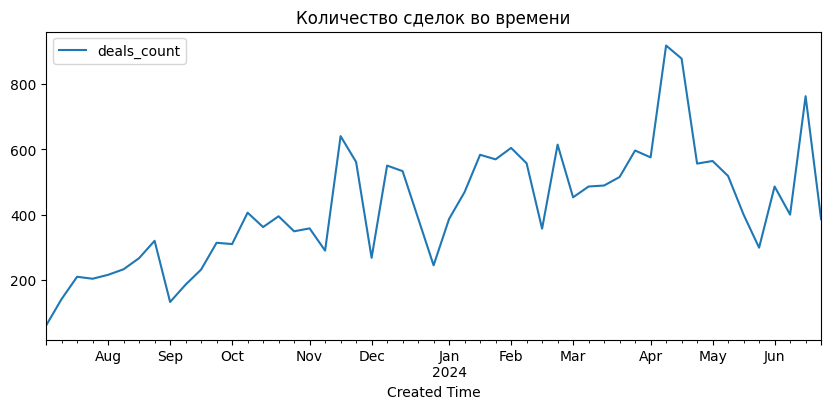

In [13]:
# Entwicklung der Anzahl der Deals im Zeitverlauf visualisieren
deals_time[['deals_count']].plot(
    figsize=(10, 4),
    title='Anzahl der Deals im Zeitverlauf'
)

In [14]:
# Entwicklung der Anrufe im Zeitverlauf (wöchentlich) analysieren

calls['Call Start Time'] = pd.to_datetime(calls['Call Start Time'])

calls_time = (
    calls
    .set_index('Call Start Time')
    .resample('W')
    .agg(
        calls_count=('Id', 'count'),                     # Anzahl der Anrufe
        avg_duration=('Call Duration (in seconds)', 'mean')  # Durchschnittliche Dauer
    )
)

calls_time.head()

,calls_count,avg_duration
Call Start Time,,
2023-07-02,7,36.571429
2023-07-09,147,205.034014
2023-07-16,354,222.677966
2023-07-23,711,149.133615
2023-07-30,642,152.576324


In [15]:
time_analysis = deals_time.join(calls_time, how='outer').fillna(0)
time_analysis.head()

,deals_count,total_offer,avg_offer,calls_count,avg_duration
2023-07-02,0.0,0.0,0.000000,7,36.571429
2023-07-09,61.0,124500.0,2766.666667,147,205.034014
2023-07-16,142.0,210000.0,1489.361702,354,222.677966
2023-07-23,210.0,83500.0,451.351351,711,149.133615
2023-07-30,204.0,134500.0,662.561576,642,152.576324


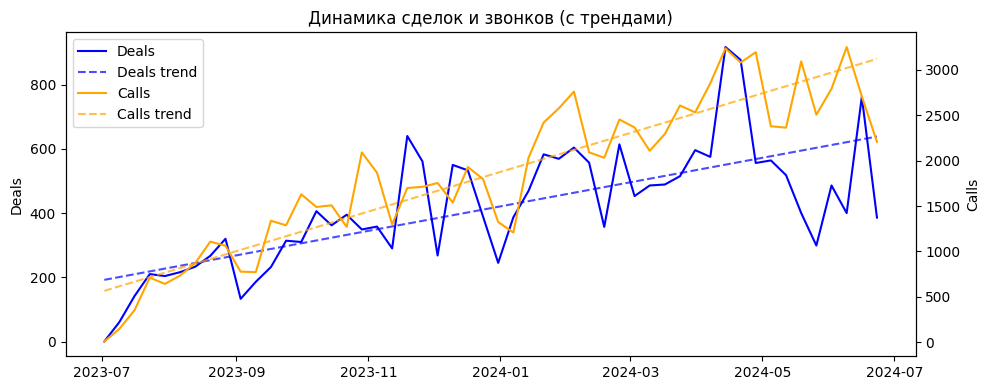

In [16]:
fig, ax1 = plt.subplots(figsize=(10, 4))

# ===== DEALS =====
x = np.arange(len(time_analysis))

l1, = ax1.plot(
    time_analysis.index,
    time_analysis['deals_count'],
    label='Deals',
    color='blue'
)

# Trendlinie für Deals
z_deals = np.polyfit(x, time_analysis['deals_count'], 1)
trend_deals = np.poly1d(z_deals)
ax1.plot(
    time_analysis.index,
    trend_deals(x),
    linestyle='--',
    color='blue',
    alpha=0.7,
    label='Deals trend'
)

ax1.set_ylabel('Deals')

# ===== CALLS =====
ax2 = ax1.twinx()

l2, = ax2.plot(
    time_analysis.index,
    time_analysis['calls_count'],
    label='Calls',
    color='orange'
)

# Trendlinie für Calls
z_calls = np.polyfit(x, time_analysis['calls_count'], 1)
trend_calls = np.poly1d(z_calls)
ax2.plot(
    time_analysis.index,
    trend_calls(x),
    linestyle='--',
    color='orange',
    alpha=0.7,
    label='Calls trend'
)

ax2.set_ylabel('Calls')

# ===== GEMEINSAME LEGENDE =====
lines = ax1.get_lines() + ax2.get_lines()
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title('Entwicklung von Deals und Anrufen (mit Trendlinien)')
plt.tight_layout()
plt.show()

**Management-Fazit zur Dynamik von Deals und Anrufen**

Die Analyse der zeitlichen Entwicklung zeigt einen **stabilen Anstieg sowohl der Anzahl der Anrufe als auch der Anzahl der Deals**, was auf eine **Zunahme der operativen und kommerziellen Aktivität** des Unternehmens im betrachteten Zeitraum hinweist.

Gleichzeitig wachsen die **Anrufe schneller als die Deals**, was auf einen **steigenden Zufluss von Leads** bei gleichzeitig moderaterem Wachstum der tatsächlich abgeschlossenen Verkäufe hinweist. Dies deutet auf **Potenzial zur Verbesserung der Lead-Bearbeitung und der Conversion-Raten entlang des Sales Funnels** hin.

Die Dynamik zeigt zudem, dass **ein Anstieg der Anrufe in der Regel dem Anstieg der Deals vorausgeht**. Dies bestätigt die Rolle von Anrufen als **Frühindikator für zukünftige Verkäufe** und spiegelt den **zeitlichen Abstand zwischen Erstkontakt und Deal-Abschluss** wider. Dieser Effekt entspricht der Logik des Geschäftsprozesses und bestätigt die Konsistenz der aufgebauten Sales-Funnel-Struktur.

Darüber hinaus weist die Anzahl der Deals eine **höhere Volatilität** auf als die Anzahl der Anrufe. Dies deutet darauf hin, dass Verkäufe stärker von Faktoren wie **Lead-Qualität, Effizienz der Vertriebsmitarbeiter und dem Fortschritt innerhalb des Funnels** beeinflusst werden, während der **Anrufstrom relativ stabil** bleibt.

Schließlich verlaufen **Spitzen und Rückgänge bei Anrufen und Deals weitgehend synchron**, was auf eine **gute Abstimmung zwischen Marketing und Vertrieb** sowie auf das **Fehlen struktureller Brüche zwischen Lead-Generierung und Lead-Bearbeitung** hinweist.

Insgesamt zeigen die Ergebnisse **ein nachhaltiges Wachstum der Nachfrage**, während gleichzeitig **Potenzial zur weiteren Steigerung der Verkaufszahlen durch Optimierung der Conversion-Prozesse und ein besseres Management der Teamkapazitäten** besteht.

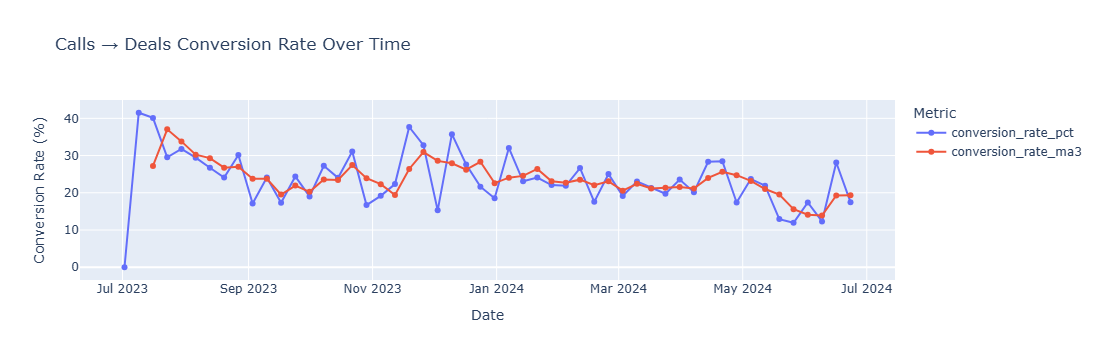

In [18]:
time_analysis = time_analysis.copy()

# Basis-Conversion-Rate (Anteil)
time_analysis['conversion_rate'] = np.where(
    time_analysis['calls_count'] > 0,
    time_analysis['deals_count'] / time_analysis['calls_count'],
    np.nan
)

# Conversion-Rate in Prozent
time_analysis['conversion_rate_pct'] = time_analysis['conversion_rate'] * 100

# Gleitender Durchschnitt (3 Perioden)
time_analysis['conversion_rate_ma3'] = (
    time_analysis['conversion_rate_pct']
        .rolling(3)
        .mean()
)

# Diagramm erstellen
fig = px.line(
    time_analysis,
    x=time_analysis.index,
    y=['conversion_rate_pct', 'conversion_rate_ma3'],
    markers=True,
    title='Conversion-Rate von Calls zu Deals im Zeitverlauf',
    labels={
        'value': 'Conversion-Rate (%)',
        'variable': 'Metrik',
        'index': 'Datum'
    }
)

fig.show()

**Management-Fazit zur Conversion Calls → Deals**

Die Analyse der zeitlichen Entwicklung der **Conversion von Anrufen zu Deals** zeigt, dass das **Konversionsniveau insgesamt relativ stabil bleibt**, obwohl in einzelnen Perioden deutliche kurzfristige Schwankungen auftreten. Dies deutet darauf hin, dass sich die **Vertriebseffizienz trotz des wachsenden Volumens an Anrufen nicht systematisch verschlechtert hat**.

Gleichzeitig weist die tatsächliche Conversion eine **hohe Volatilität** auf, was den Einfluss kurzfristiger Faktoren widerspiegelt, wie etwa **Schwankungen in der Qualität der eingehenden Leads, saisonale Effekte sowie operative Belastung des Vertriebsteams**.

Durch die Verwendung eines **gleitenden Durchschnitts** lassen sich kurzfristige Schwankungen glätten und der zugrunde liegende Trend besser erkennen. Die geglättete Linie zeigt **einen moderaten Rückgang der Conversion gegen Ende des betrachteten Zeitraums**, was darauf hindeuten kann, dass das **Anrufvolumen schneller wächst als die Fähigkeit des Teams, diese effizient in Deals umzuwandeln**.

Somit bleibt die Conversion insgesamt zwar im **Bereich von etwa 20–30 %**, jedoch zeigt der Trend der gleitenden Durchschnittslinie eine **leichte Abnahme der „grundlegenden“ Effizienz**. Dies weist auf **Potenzial für Managementmaßnahmen** hin, insbesondere in Bezug auf **Verbesserung der Lead-Qualität sowie Optimierung der Prozesse zur Bearbeitung eingehender Anrufe**.

In [ ]:
Analyse des Einflusses der Anrufdauer auf den Deal-Abschluss

In [19]:
# Flag „Payment Done“ auf Kontaktebene erstellen

deals_flag = (
    deals[['Contact Name', 'Stage']]
    # Kennzeichen erstellen: 1 = Deal abgeschlossen (Payment Done), sonst 0
    .assign(is_win=lambda x: (x['Stage'] == 'Payment Done').astype(int))
    # Auf Kontaktebene aggregieren
    # Falls ein Kontakt mindestens einen erfolgreichen Deal hat → is_win = 1
    .groupby('Contact Name', as_index=False)
    .agg(is_win=('is_win', 'max'))
)

In [20]:
# Anrufe auf CONTACTID-Ebene aggregieren
# Maximale und durchschnittliche Gesprächsdauer sowie Anzahl der Anrufe berechnen

calls_agg = (
    calls[['CONTACTID', 'Call Duration (in seconds)']]
    .groupby('CONTACTID', as_index=False)
    .agg(
        max_call_duration=('Call Duration (in seconds)', 'max'),
        avg_call_duration=('Call Duration (in seconds)', 'mean'),
        calls_count=('Call Duration (in seconds)', 'count')
    )
)

In [21]:
# Datensätze zusammenführen
analysis_df = deals_flag.merge(
    calls_agg,
    left_on='Contact Name',
    right_on='CONTACTID',
    how='left'
)

# Zeilen ohne Anrufdaten entfernen
analysis_df = analysis_df.dropna(subset=['max_call_duration'])

<Figure size 700x500 with 0 Axes>

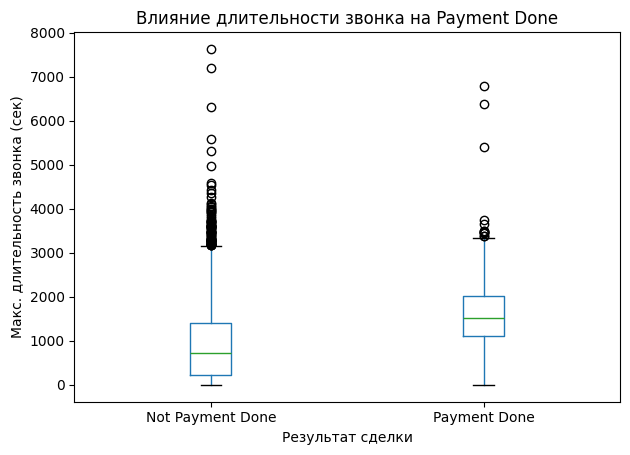

In [22]:
# Boxplot erstellen
plt.figure(figsize=(7, 5))

analysis_df.boxplot(
    column='max_call_duration',
    by='is_win',
    grid=False
)

plt.xticks([1, 2], ['Not Payment Done', 'Payment Done'])
plt.ylabel('Maximale Anrufdauer (Sekunden)')
plt.xlabel('Deal-Ergebnis')
plt.title('Einfluss der Anrufdauer auf Payment Done')
plt.suptitle('')
plt.tight_layout()
plt.show()

**Statistischer Vergleich der Verteilungen**

### 1. Median (zentrale Tendenz)

**Payment Done:** Median deutlich höher
≈ **1400–1500 Sekunden** (≈ **23–25 Minuten**)

**Not Payment Done:** Median niedriger
≈ **600–700 Sekunden** (≈ **10–12 Minuten**)

**Fazit:**
Bei erfolgreichen Deals ist der typische (mediane) maximale Anruf **etwa doppelt so lang** wie bei nicht erfolgreichen Deals.

---

### 2. Interquartilsabstand (IQR: 25–75 %)

**Payment Done:**
IQR etwa **1100–1900 Sekunden**
Die Verteilung ist kompakter und nach oben verschoben.

**Not Payment Done:**
IQR etwa **300–1200 Sekunden**
Die Verteilung ist breiter und nach unten verschoben.

**Fazit:**
Bei erfolgreichen Deals liegt **nicht nur der Median höher**, sondern auch der Großteil der Beobachtungen befindet sich in einem **höheren Bereich der Gesprächsdauer**.

---

### 3. Überlappung der Verteilungen

Die Bereiche überschneiden sich teilweise.

Allerdings gilt:

* das **untere Quartil von Payment Done ≈ Median von Not Payment Done**
* das **obere Quartil von Not Payment Done liegt unter dem Median von Payment Done**

**Fazit:**
Kurze Anrufe kommen auch bei erfolgreichen Deals vor,
aber **lange Gespräche sind deutlich häufiger mit Payment Done verbunden**.

---

### 4. Ausreißer (Outliers)

In beiden Gruppen gibt es **sehr lange Anrufe** (bis etwa **6000–7500 Sekunden**).

Bei **Not Payment Done** sind Ausreißer häufiger und extremer.

**Interpretation:**
Ein langer Anruf garantiert keinen erfolgreichen Abschluss.
Ein Teil dieser Gespräche kann z. B. sein:

* komplexe Fälle,
* starke Einwände,
* Schwierigkeiten bei der Entscheidungsfindung.

---

### 5. Untere Grenze

Bei **Payment Done** gibt es auch Werte nahe **0 Sekunden**.

Das kann bedeuten:

* sehr schnelle Abschlüsse
  oder
* unvollständige Anrufdaten.

---

# Praktischer Business-Insight

* **Sehr kurze Gespräche (< ca. 5–7 Minuten)** führen selten zu **Payment Done**.
* Die **höchste Erfolgswahrscheinlichkeit** liegt im Bereich **mittlerer bis längerer Gespräche**.
* Ab einer bestimmten Dauer tritt jedoch ein **Sättigungseffekt** ein – längere Gespräche erhöhen die Erfolgswahrscheinlichkeit nicht unbegrenzt.

**Fazit:**
Die **Gesprächsdauer ist kein alleiniger Faktor**, aber ein **statistisch signifikanter Indikator für den Deal-Erfolg**.

In [23]:
# Anteil der Deals, die von Anrufen begleitet wurden

deals['has_calls'] = deals['Contact Name'].isin(calls['CONTACTID'])

# Prozentuale Verteilung anzeigen
deals['has_calls'].value_counts(normalize=True) * 100

has_calls
True     95.790497
False     4.209503
Name: proportion, dtype: float64

Die **überwiegende Mehrheit der Deals ist mit Anrufaktivität verbunden**. Insgesamt **95,8 % aller Deals** haben mindestens **einen Anruf pro Kontakt**, während nur **4,2 % der Deals ohne jegliche telefonische Interaktion** erstellt wurden.

Dies zeigt, dass **Telefonanrufe ein zentraler Kommunikationskanal** für die **Entstehung und Entwicklung von Deals** sind.

In [24]:
# Anzahl der Anrufe pro Kontakt berechnen
calls_per_contact = calls.groupby('CONTACTID').size()

# Anzahl der Anrufe den Deals zuordnen
deals['calls_count'] = deals['Contact Name'].map(calls_per_contact).fillna(0)

# Deskriptive Statistik anzeigen
deals[['calls_count']].describe()

,calls_count
count,21594.000000
mean,17.471057
std,15.004747
min,0.000000
25%,6.000000
50%,14.000000
75%,25.000000
max,98.000000


Pro Kontakt gibt es **in der Regel mehrere Anrufe, nicht nur einen**.

* **Durchschnittliche Anzahl der Anrufe pro Kontakt:** 17,5
* **Median:** 14 Anrufe
* **75 % der Deals** haben **bis zu 25 Anrufe**
* **Maximum:** bis zu **98 Anrufe pro Kontakt**

Dies zeigt, dass der **Abschluss eines Deals meist mehrere Kontakte mit dem Kunden erfordert** und selten durch eine einmalige Interaktion erfolgt.

In [25]:
# Prüfen, ob Anrufe die Deal-Summe beeinflussen
deals.groupby('has_calls')['Offer Total Amount'].mean()

has_calls
False    5255.102041
True     7150.921422
Name: Offer Total Amount, dtype: float64

Das **Vorhandensein von Anrufen steht in direktem Zusammenhang mit dem finanziellen Ergebnis eines Deals**.

* **Durchschnittliche Deal-Summe ohne Anrufe:** 5.255
* **Durchschnittliche Deal-Summe mit Anrufen:** 7.151

Deals, die von **Telefonanrufen begleitet werden**, sind im Durchschnitt **etwa 36 % höher** als Deals ohne telefonische Interaktion.

Dies bestätigt, dass **Anrufe nicht nur die Wahrscheinlichkeit eines erfolgreichen Abschlusses erhöhen**, sondern auch **positiv auf den finalen Deal-Wert wirken**.

Gesamtfazit:Anrufe spielen eine entscheidende Rolle im Verkaufsprozess: Sie begleiten nahezu alle Abschlüsse, erfordern eine regelmäßige Interaktion mit dem Kunden und sind mit einem höheren durchschnittlichen Bestellwert verbunden. Die Intensivierung und Optimierung der Anrufaktivität kann ein effektiver Hebel für das Umsatzwachstum sein.

**1.2 Untersuchen Sie die Verteilung der Abschlusszeiten von Deals sowie die Dauer des Zeitraums von der Erstellung bis zum Abschluss.**

In [26]:
completed_deals = deals.dropna(subset=['SLA_days'])
completed_deals['SLA_days'].describe()

count    14601.000000
mean        15.011917
std         31.521645
min          0.000000
25%          1.000000
50%          4.000000
75%         12.000000
max        335.000000
Name: SLA_days, dtype: float64

**Durchschnittliche Deal-Dauer:** ~15 Tage
Im Durchschnitt werden Deals innerhalb von etwa zwei Wochen abgeschlossen.

**Median:** 3 Tage
Die Hälfte der Deals wird sehr schnell abgeschlossen — innerhalb von 4 Tagen oder weniger. Das deutet darauf hin, dass die meisten Deals „einfach“ sind und schnell geschlossen werden.

**Streuung (Std = 31,5) und 75. Perzentil = 12 Tage**
Es gibt einige Deals mit sehr langer Abschlussdauer, die den Durchschnitt stark erhöhen. Für die meisten Deals (50–75 %) liegt die Dauer zwischen 1 und 12 Tagen — das ist der normale operative Bereich.

**Minimum und Maximum:** 0 und 335 Tage
Deals mit **SLA = 0** wurden am Tag ihrer Erstellung abgeschlossen.
Deals mit **SLA = 335** sind ungewöhnlich lang und sollten möglicherweise überprüft werden oder stellen Ausnahmen dar.

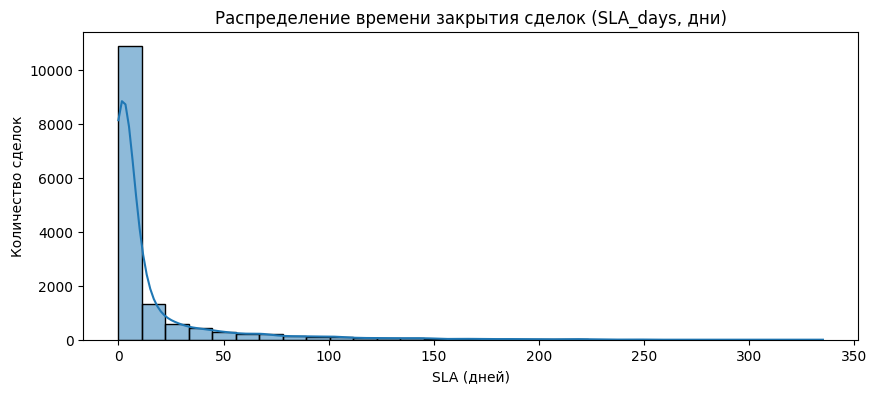

In [27]:
# Verteilung der SLA (Dauer eines Deals)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,4))
sns.histplot(deals['SLA_days'], bins=30, kde=True)

plt.title('Verteilung der Abschlussdauer von Deals (SLA_days, Tage)')
plt.xlabel('SLA (Tage)')
plt.ylabel('Anzahl der Deals')

plt.show()

**Die Verteilung der Abschlusszeiten von Deals** zeigt einen ausgeprägten Peak bei null — mehr als **10.000 Deals wurden am Tag ihrer Erstellung abgeschlossen**.

Die meisten übrigen Deals werden innerhalb von **1–12 Tagen** geschlossen, während sich eine kleine Anzahl von Deals über **300+ Tage** hinzieht.

Die Verteilung ist **stark rechtsschief**: Das durchschnittliche SLA (**~15 Tage**) liegt über dem Median (**3 Tage**), was auf einige wenige sehr langfristige Deals zurückzuführen ist.

In [28]:
# Nur Deals mit Stage = "Payment Done" filtern
completed_deals = deals[deals['Stage'] == 'Payment Done']

# Nach Abschlussmonat gruppieren
completed_monthly_stats = completed_deals.groupby(completed_deals['Closing Date'].dt.to_period('M')).agg(
    avg_sla=('SLA_days', 'mean'),
    deals_closed=('Id', 'count')
).reset_index()

# Period in datetime für die Visualisierung umwandeln
completed_monthly_stats['Closing Date'] = completed_monthly_stats['Closing Date'].dt.to_timestamp()

print(completed_monthly_stats.head())

  Closing Date    avg_sla  deals_closed
0   2023-07-01   0.500000             3
1   2023-08-01  10.107143            28
2   2023-09-01  18.857143            28
3   2023-10-01  11.774194            32
4   2023-11-01  23.740000            50


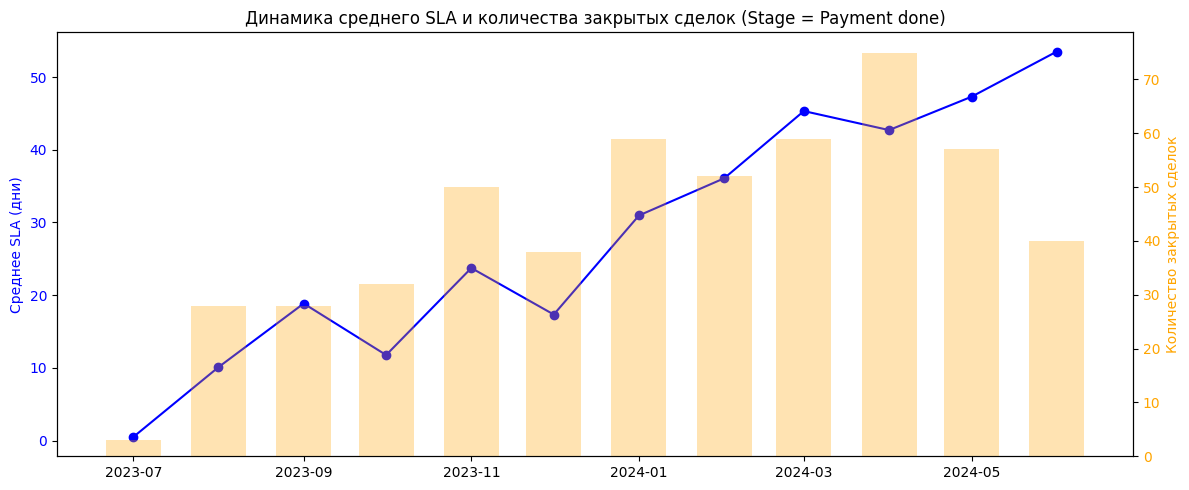

In [29]:
fig, ax1 = plt.subplots(figsize=(12,5))

# Linie für das durchschnittliche SLA
ax1.plot(completed_monthly_stats['Closing Date'], completed_monthly_stats['avg_sla'],
         color='blue', marker='o', label='Durchschnittliches SLA (Tage)')
ax1.set_ylabel('Durchschnittliches SLA (Tage)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Balkendiagramm für die Anzahl der abgeschlossenen Deals
ax2 = ax1.twinx()
ax2.bar(completed_monthly_stats['Closing Date'], completed_monthly_stats['deals_closed'],
        alpha=0.3, color='orange', label='Abgeschlossene Deals', width=20)  # Breite in Tagen bei datetime auf der X-Achse
ax2.set_ylabel('Anzahl abgeschlossener Deals', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title('Dynamik des durchschnittlichen SLA und der Anzahl abgeschlossener Deals (Stage = Payment Done)')
fig.tight_layout()
plt.show()

**Die Analyse der Dynamik des durchschnittlichen SLA und der Anzahl abgeschlossener Deals mit dem Status „Payment Done“** zeigt, dass es **keine eindeutige Abhängigkeit** zwischen der Anzahl der abgeschlossenen Deals und der durchschnittlichen Deal-Dauer gibt: In einigen Zeiträumen ist der Zusammenhang **direkt proportional**, in anderen **umgekehrt proportional**.

Insgesamt lässt sich jedoch eine **Tendenz zu steigenden SLA-Werten bei zunehmender Anzahl abgeschlossener Deals** beobachten, was auf eine **höhere Belastung der Sales Manager** hindeuten könnte.

Im letzten Zeitraum zeigt sich jedoch eine **anomale inverse Beziehung**: Das durchschnittliche SLA steigt stark an, während die Anzahl der Deals mit Zahlung sinkt. Dies hängt höchstwahrscheinlich mit **einzelnen sehr langfristigen Deals (Ausreißern)** zusammen.

In [33]:
# Berechnung des Korrelationskoeffizienten zwischen avg_sla und deals_closed
correlation = completed_monthly_stats['avg_sla'].corr(completed_monthly_stats['deals_closed'])

print(f"Korrelationskoeffizient zwischen durchschnittlichem SLA und Anzahl abgeschlossener Deals: {correlation:.2f}")

Коэффициент корреляции между средним SLA и количеством закрытых сделок: 0.77


**Der Korrelationskoeffizient zwischen dem durchschnittlichen SLA und der Anzahl abgeschlossener Deals beträgt 0,77**, was auf eine **starke positive Beziehung** hinweist.

Das bedeutet, dass mit zunehmender **durchschnittlicher Abschlussdauer eines Deals** auch die **Anzahl der monatlich abgeschlossenen Deals** tendenziell steigt. Mit anderen Worten: Zeiträume mit **längeren Deal-Zyklen** gehen häufig mit einer **größeren Anzahl abgeschlossener Deals** einher.

Dies kann mit **Saisonalität oder dem Gesamtvolumen der Deals** zusammenhängen. Diese Erkenntnis ist wichtig für die **Vertriebsplanung und die Optimierung von Verkaufsprozessen**.

**Die Analyse der Dynamik des durchschnittlichen SLA und der Anzahl abgeschlossener Deals (Stage „Payment Done“) zeigt eine deutliche positive Beziehung zwischen diesen Kennzahlen.**

Der berechnete **Korrelationskoeffizient von 0,77** weist auf eine **starke positive Abhängigkeit** hin: In Monaten mit einer höheren durchschnittlichen Abschlussdauer von Deals wird in der Regel auch eine größere Anzahl von Deals abgeschlossen.

Dies bestätigt auch die **visuellen Beobachtungen** — Zeiträume mit einem Anstieg des SLA fallen häufig mit einem Wachstum der Anzahl abgeschlossener Deals zusammen.

Somit kann eine **längere Deal-Dauer mit einem höheren Volumen abgeschlossener Deals einhergehen**, was bei der **Vertriebsplanung und der Optimierung von Geschäftsprozessen** berücksichtigt werden sollte.

# Block 2
## Analyse der Kampagneneffektivität:

1. Vergleichen Sie die Effektivität verschiedener Kampagnen im Hinblick auf die **Lead-Generierung** und die **Konversionsrate**.
2. Bewerten Sie die Effektivität verschiedener **Marketingquellen (Source)** bei der Generierung **qualitativ hochwertiger Leads**.


### 2.1 Vergleichen Sie die Effektivität verschiedener Kampagnen hinsichtlich der Lead-Generierung und der Konversionsrate.

### Analyse der Effektivität verschiedener Kampagnen im Hinblick auf die Lead-Generierung und die Konversionsrate.

In [30]:
# Erstellung einer einheitlichen Tabelle „campaign_performance“

spend_ = spend.copy()
deals_ = deals.copy()

spend_['Source'] = spend_['Source'].astype('string').str.strip()
deals_['Source'] = deals_['Source'].astype('string').str.strip()

spend_['Campaign'] = spend_['Campaign'].astype('string').str.strip().replace('', pd.NA).fillna('No Campaign')
deals_['Campaign'] = deals_['Campaign'].astype('string').str.strip().replace('', pd.NA).fillna('No Campaign')

# numerische Felder
for col in ['Clicks', 'Impressions', 'Spend']:
    spend_[col] = pd.to_numeric(spend_[col], errors='coerce').fillna(0)

# --- Leads pro Kampagne (man könnte auch nach Campaign+Source gruppieren,
# aber da die Kampagneneffektivität analysiert wird, aggregieren wir nach Campaign) ---
leads_by_campaign = (
    deals_.groupby('Campaign', as_index=False)
          .agg(Leads=('Contact Name', 'nunique'))
)

# --- Klicks / Impressionen / Ausgaben pro Kampagne ---
spend_by_campaign = (
    spend_.groupby('Campaign', as_index=False)
          .agg(
              Clicks=('Clicks', 'sum'),
              Impressions=('Impressions', 'sum'),
              Spend=('Spend', 'sum')
          )
)

# --- Tabellen zusammenführen ---
campaign_perf = spend_by_campaign.merge(leads_by_campaign, on='Campaign', how='outer')
campaign_perf[['Clicks','Impressions','Spend','Leads']] = campaign_perf[['Clicks','Impressions','Spend','Leads']].fillna(0)

# --- Effizienzmetriken ---
campaign_perf['CR'] = np.where(campaign_perf['Clicks'] > 0, campaign_perf['Leads'] / campaign_perf['Clicks'] * 100, np.nan)
campaign_perf['CPL'] = np.where(campaign_perf['Leads'] > 0, campaign_perf['Spend'] / campaign_perf['Leads'], np.nan)

# nützlich für Filter / Interpretation
campaign_perf['is_paid_like'] = campaign_perf['Spend'] > 0

In [31]:
# Tabelle „Beste Kampagnen“ (Leads + CR)

min_clicks = 100  # Schwellenwert

campaign_rank = campaign_perf[
    (campaign_perf['Clicks'] >= min_clicks) & 
    (campaign_perf['Leads'] > 0)
].copy()

campaign_rank = campaign_rank.sort_values(
    ['Leads', 'CR'],
    ascending=[False, False]
)

cols = ['Campaign', 'Leads', 'Clicks', 'CR', 'Spend', 'CPL']

styled_table = (
    campaign_rank[cols]
    .head(30)
    .style
    # Leads — je mehr, desto besser
    .background_gradient(
        subset=['Leads'],
        cmap='Greens'
    )
    # CR — je höher, desto besser
    .background_gradient(
        subset=['CR'],
        cmap='Blues'
    )
    # CPL — je niedriger, desto besser (deshalb umgekehrte Farbskala)
    .background_gradient(
        subset=['CPL'],
        cmap='Reds_r'
    )
    # Zahlenformatierung
    .format({
        'Leads': '{:.0f}',
        'Clicks': '{:.0f}',
        'CR': '{:.2f}%',
        'Spend': '{:.2f}',
        'CPL': '{:.2f}'
    })
)

styled_table

,Campaign,Leads,Clicks,CR,Spend,CPL
74,No Campaign,3642,110057,3.31%,27887.68,7.66
20,12.07.2023wide_DE,1329,22768,5.84%,9471.52,7.13
159,youtube_shorts_DE,1314,57873,2.27%,14149.22,10.77
3,02.07.23wide_DE,866,10281,8.42%,6913.49,7.98
6,04.07.23recentlymoved_DE,700,7611,9.20%,4523.22,6.46
5,03.07.23women,578,7139,8.10%,4219.68,7.30
9,07.07.23LAL_DE,512,5813,8.81%,4200.32,8.20
21,12.09.23interests_Uxui_DE,491,6301,7.79%,3753.06,7.64
45,24.09.23retargeting_DE,460,4143,11.10%,2817.29,6.12
11,08.04.24wide_webinar_DE,236,1094,21.57%,576.43,2.44


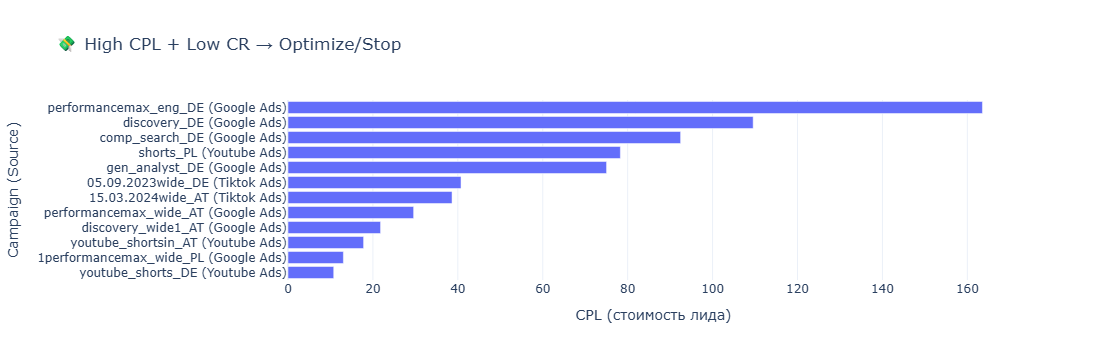

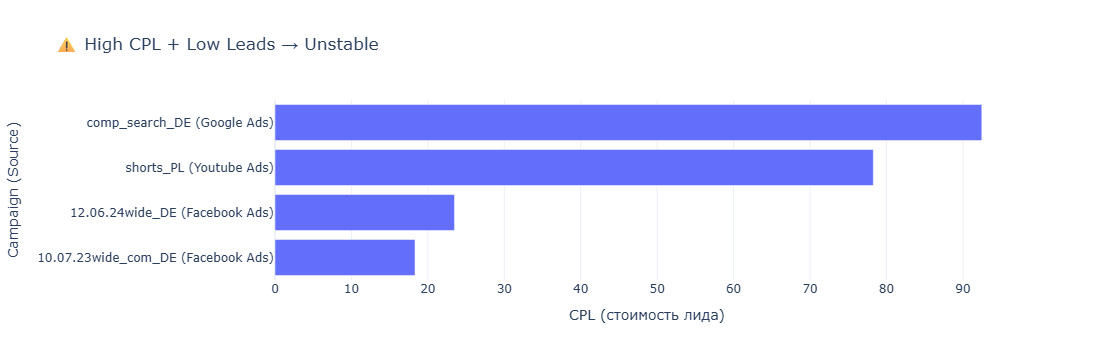

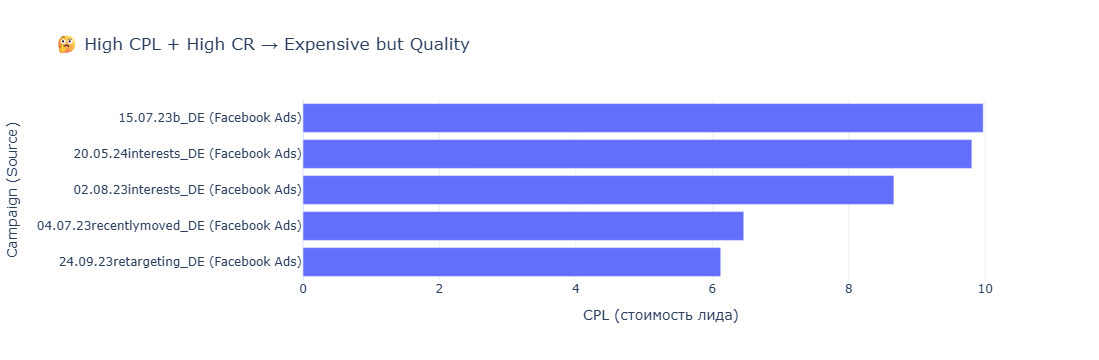

In [32]:
top_n = 20

# =========================
# 0) Source wiederherstellen
# =========================
campaign_source = (
    spend
    .assign(
        Campaign=lambda x: x['Campaign']
            .astype('string')
            .str.strip()
            .replace('', pd.NA)
            .fillna('No Campaign'),
        Source=lambda x: x['Source']
            .astype('string')
            .str.strip()
            .fillna('Unknown')
    )
    .groupby('Campaign')['Source']
    .agg(lambda x: x.mode().iloc[0])
    .reset_index()
)

campaign_perf = campaign_perf.merge(
    campaign_source,
    on='Campaign',
    how='left'
)

campaign_perf['Source'] = campaign_perf['Source'].fillna('Unknown')

# =========================
# 1) Basis
# =========================
df = (
    campaign_perf
    .query("Campaign != 'No Campaign'")
    .query("Leads > 0")
    .copy()
)

df['Campaign_label'] = df['Campaign'] + ' (' + df['Source'] + ')'

# =========================
# 2) Schwellenwerte
# =========================
cpl_high_thr  = df['CPL'].quantile(0.75)
cr_low_thr    = df['CR'].quantile(0.25)
cr_high_thr   = df['CR'].quantile(0.75)
leads_low_thr = df['Leads'].quantile(0.25)

# =========================
# 3) Segmente
# =========================
seg_optimize = df[(df['CPL'] >= cpl_high_thr) & (df['CR'] <= cr_low_thr)]
seg_unstable = df[(df['CPL'] >= cpl_high_thr) & (df['Leads'] <= leads_low_thr)]
seg_quality  = df[(df['CPL'] >= cpl_high_thr) & (df['CR'] >= cr_high_thr)]

def bar_top_cpl(data, title):
    if data.empty:
        print(f"Keine Kampagnen für das Segment: {title}")
        return None

    top = data.sort_values('CPL', ascending=True).tail(top_n)

    fig = px.bar(
        top,
        x='CPL',
        y='Campaign_label',
        orientation='h',
        hover_data={
            'Campaign': True,
            'Source': True,
            'Leads': ':.0f',
            'Clicks': ':.0f',
            'CR': ':.2f',
            'Spend': ':.2f',
            'CPL': ':.2f'
        },
        title=title
    )

    fig.update_layout(
        xaxis_title='CPL (Kosten pro Lead)',
        yaxis_title='Kampagne (Source)',
        template='plotly_white'
    )
    return fig

# =========================
# 4) Grafiken
# =========================
fig_optimize = bar_top_cpl(
    seg_optimize,
    "💸 Hoher CPL + Niedrige CR → Optimieren / Stoppen"
)
if fig_optimize: fig_optimize.show()

fig_unstable = bar_top_cpl(
    seg_unstable,
    "⚠️ Hoher CPL + Wenige Leads → Instabil"
)
if fig_unstable: fig_unstable.show()

fig_quality = bar_top_cpl(
    seg_quality,
    "🤔 Hoher CPL + Hohe CR → Teuer, aber qualitativ"
)
if fig_quality: fig_quality.show()

💸 **Hoher CPL + niedrige CR → Kandidat für Optimierung / Abschaltung**
⚠️ **Hoher CPL + wenige Leads → statistisch instabil**
🤔 **Hoher CPL + hohe CR → möglicherweise teure, aber qualitativ hochwertige Zielgruppe**

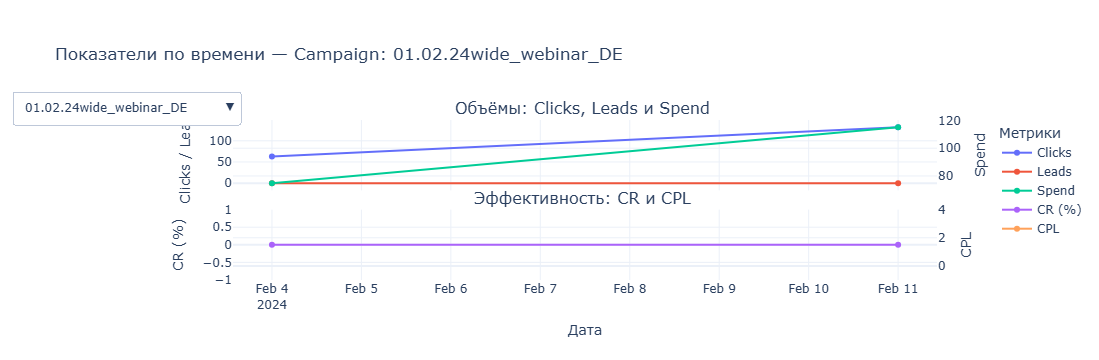

In [33]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

spend_ = spend.copy()
deals_ = deals.copy()

# Datumsfelder
spend_['Date'] = pd.to_datetime(spend_['Date'])

# Falls das Datumsfeld in deals anders heißt, hier anpassen:
deals_['Created Time'] = pd.to_datetime(deals_['Created Time'])

# Kampagnen bereinigen (damit leere Werte nicht herausfallen)
spend_['Campaign'] = (
    spend_['Campaign'].astype('string').str.strip()
    .replace('', pd.NA).fillna('No Campaign')
)
deals_['Campaign'] = (
    deals_['Campaign'].astype('string').str.strip()
    .replace('', pd.NA).fillna('No Campaign')
)

# numerische Felder in spend
for col in ['Clicks', 'Impressions', 'Spend']:
    if col in spend_.columns:
        spend_[col] = pd.to_numeric(spend_[col], errors='coerce').fillna(0)

# =========================
# 1) Aggregation nach Zeit + Campaign (Wochen)
# =========================
spend_ts = (
    spend_
    .groupby([pd.Grouper(key='Date', freq='W'), 'Campaign'], as_index=False)
    .agg(
        Clicks=('Clicks', 'sum'),
        Spend=('Spend', 'sum'),
        Impressions=('Impressions', 'sum') if 'Impressions' in spend_.columns else ('Clicks', 'sum')
    )
)

leads_ts = (
    deals_
    .groupby([pd.Grouper(key='Created Time', freq='W'), 'Campaign'], as_index=False)
    .agg(Leads=('Contact Name', 'nunique'))
    .rename(columns={'Created Time': 'Date'})
)

ts = spend_ts.merge(leads_ts, on=['Date', 'Campaign'], how='left')
ts['Leads'] = ts['Leads'].fillna(0)

# Kennzahlen
ts['CR'] = np.where(ts['Clicks'] > 0, ts['Leads'] / ts['Clicks'] * 100, np.nan)
ts['CPL'] = np.where(ts['Leads'] > 0, ts['Spend'] / ts['Leads'], np.nan)

# Falls du den Platzhalter aus der Auswahl entfernen möchtest:
ts = ts[ts['Campaign'] != 'No Campaign'].copy()

campaigns = sorted(ts['Campaign'].dropna().unique().tolist())

# =========================
# 2) Eine Figure mit 2 Panels und Dropdown nach Campaign
# =========================
fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.12,
    specs=[[{"secondary_y": True}], [{"secondary_y": True}]],
    subplot_titles=(
        "Volumen: Clicks, Leads und Spend",
        "Effizienz: CR und CPL"
    )
)

# Für jede Kampagne werden 5 Traces hinzugefügt:
# row1: Clicks, Leads (links), Spend (rechts)
# row2: CR (links), CPL (rechts)
traces_per_campaign = 5

for i, c in enumerate(campaigns):
    dfc = ts[ts['Campaign'] == c].sort_values('Date')

    visible = (i == 0)

    # --- row 1 ---
    fig.add_trace(
        go.Scatter(x=dfc['Date'], y=dfc['Clicks'], mode='lines+markers', name='Clicks', visible=visible),
        row=1, col=1, secondary_y=False
    )
    fig.add_trace(
        go.Scatter(x=dfc['Date'], y=dfc['Leads'], mode='lines+markers', name='Leads', visible=visible),
        row=1, col=1, secondary_y=False
    )
    fig.add_trace(
        go.Scatter(x=dfc['Date'], y=dfc['Spend'], mode='lines+markers', name='Spend', visible=visible),
        row=1, col=1, secondary_y=True
    )

    # --- row 2 ---
    fig.add_trace(
        go.Scatter(x=dfc['Date'], y=dfc['CR'], mode='lines+markers', name='CR (%)', visible=visible),
        row=2, col=1, secondary_y=False
    )
    fig.add_trace(
        go.Scatter(x=dfc['Date'], y=dfc['CPL'], mode='lines+markers', name='CPL', visible=visible),
        row=2, col=1, secondary_y=True
    )

# Achsenbeschriftungen
fig.update_yaxes(title_text="Clicks / Leads", row=1, col=1, secondary_y=False)
fig.update_yaxes(title_text="Spend", row=1, col=1, secondary_y=True)
fig.update_yaxes(title_text="CR (%)", row=2, col=1, secondary_y=False)
fig.update_yaxes(title_text="CPL", row=2, col=1, secondary_y=True)

fig.update_xaxes(title_text="Datum", row=2, col=1)

# Dropdown: nur die 5 Traces der ausgewählten Kampagne anzeigen
buttons = []
for i, c in enumerate(campaigns):
    vis = [False] * (len(campaigns) * traces_per_campaign)
    start = i * traces_per_campaign
    for k in range(traces_per_campaign):
        vis[start + k] = True

    buttons.append({
        "label": c,
        "method": "update",
        "args": [
            {"visible": vis},
            {"title": f"Kennzahlen im Zeitverlauf — Campaign: {c}"}
        ]
    })

fig.update_layout(
    template="plotly_white",
    title=f"Kennzahlen im Zeitverlauf — Campaign: {campaigns[0] if campaigns else ''}",
    legend_title_text="Kennzahlen",
    updatemenus=[{
        "buttons": buttons,
        "direction": "down",
        "x": 0.01,
        "y": 1.18,
        "showactive": True
    }],
    margin=dict(t=120)
)

fig.show()

### Analyse der Effektivität der Quellen im Hinblick auf die Lead-Generierung.

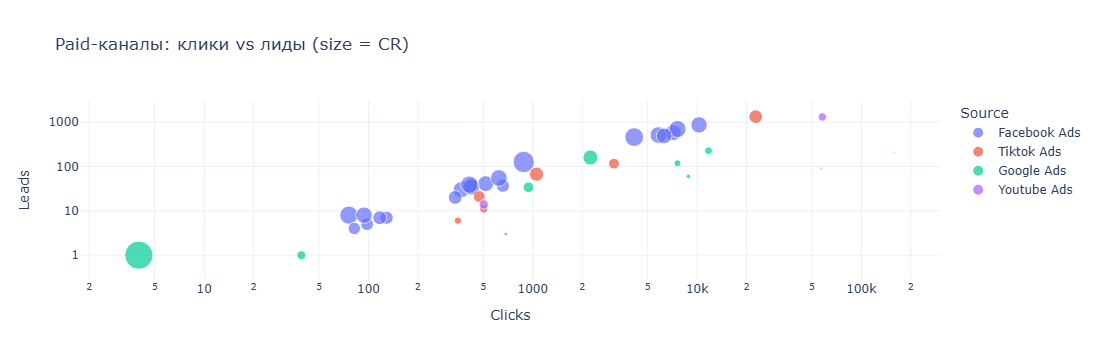

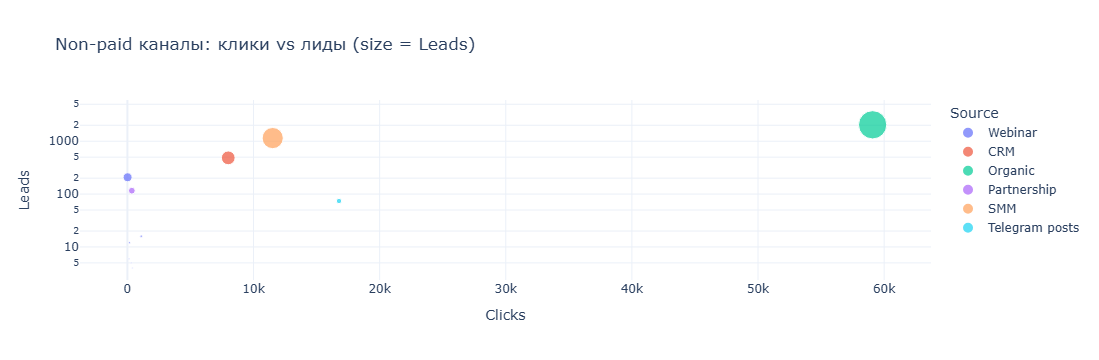

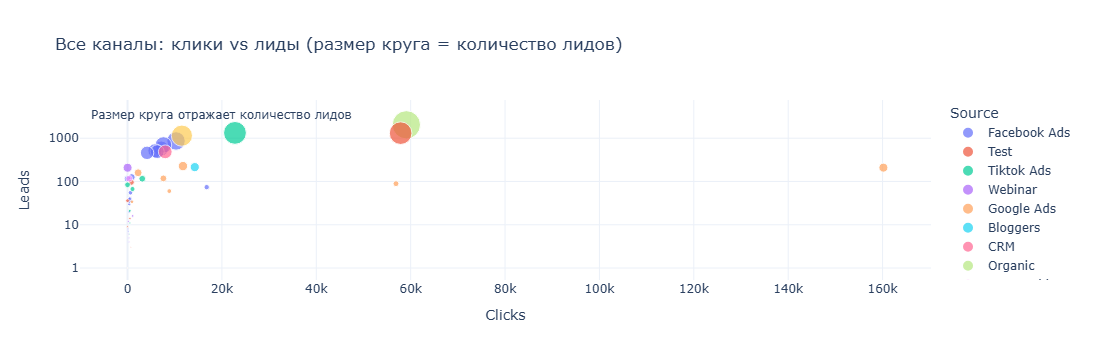

In [34]:
spend = spend.copy()
deals = deals.copy()

for df in [spend, deals]:
    df['Source'] = df['Source'].astype('string').str.strip()

# Campaign für Non-Paid Quellen auffüllen
spend['Campaign'] = spend['Campaign'].astype('string').str.strip().replace('', pd.NA).fillna('No Campaign')
deals['Campaign'] = deals['Campaign'].astype('string').str.strip().replace('', pd.NA).fillna('No Campaign')

# numerische Felder
for col in ['Clicks', 'Impressions', 'Spend']:
    spend[col] = pd.to_numeric(spend[col], errors='coerce').fillna(0)

# =========================
# 1) Spend nach Campaign + Source aggregieren
# =========================
spend_agg = (
    spend.groupby(['Campaign', 'Source'], as_index=False)
         .agg(
             Clicks=('Clicks', 'sum'),
             Impressions=('Impressions', 'sum'),
             Spend=('Spend', 'sum')
         )
)

# =========================
# 2) Leads aus deals aggregieren
# =========================
leads_agg = (
    deals.groupby(['Campaign', 'Source'], as_index=False)
         .agg(Leads=('Contact Name', 'nunique'))
)

# =========================
# 3) Merge → einheitliche Tabelle für Visualisierungen
# =========================
plot_df = spend_agg.merge(leads_agg, on=['Campaign', 'Source'], how='left')
plot_df['Leads'] = plot_df['Leads'].fillna(0)

# Kennzahlen
plot_df['CR'] = np.where(plot_df['Clicks'] > 0, (plot_df['Leads'] / plot_df['Clicks']) * 100, np.nan)
plot_df['CPL'] = np.where(plot_df['Leads'] > 0, plot_df['Spend'] / plot_df['Leads'], np.nan)

# =========================
# 4) Listen der Kanäle
# =========================
paid_sources = ['Google Ads', 'Facebook Ads', 'Tiktok Ads', 'Youtube Ads']
non_paid_sources = ['Organic', 'Partnership', 'Offline', 'Webinar', 'CRM', 'Telegram posts', 'SMM', 'Radio']

# =========================
# 5) Diagramm 1: Paid Channels
# (Log-Skala für X und Y — ok, da Clicks > 0)
# =========================
paid_df = plot_df[
    (plot_df['Source'].isin(paid_sources)) &
    (plot_df['Clicks'] > 0) &
    (plot_df['Leads'] > 0)
].copy()

fig_paid = px.scatter(
    paid_df,
    x='Clicks',
    y='Leads',
    color='Source',
    size='CR',  # Größe = CR
    hover_data={
        'Campaign': True,
        'Clicks': ':.0f',
        'Leads': ':.0f',
        'CR': ':.2f',
        'Spend': ':.2f',
        'CPL': ':.2f',
        'Impressions': ':.0f'
    },
    log_x=True,
    log_y=True,
    title='Paid-Kanäle: Klicks vs. Leads (Größe = CR)'
)

fig_paid.update_layout(template='plotly_white')
fig_paid.show()

# =========================
# 6) Diagramm 2: Non-Paid
# Wichtig: Organic kann Clicks haben, aber manchmal auch 0.
# Damit Organic nicht verschwindet, verwenden wir log_y=True,
# lassen X jedoch linear.
# =========================
non_paid_df = plot_df[
    (plot_df['Source'].isin(non_paid_sources)) &
    (plot_df['Leads'] > 0)
].copy()

fig_non_paid = px.scatter(
    non_paid_df,
    x='Clicks',
    y='Leads',
    color='Source',
    size='Leads',  # Größe = Anzahl Leads
    hover_data={
        'Campaign': True,
        'Clicks': ':.0f',
        'Leads': ':.0f',
        'Spend': ':.2f',
        'Impressions': ':.0f'
    },
    log_x=False,
    log_y=True,
    title='Non-Paid Kanäle: Klicks vs. Leads (Größe = Leads)'
)

fig_non_paid.update_layout(template='plotly_white')
fig_non_paid.show()

# =========================
# 7) Diagramm 3: Alle Kanäle
# Um Quellen mit Clicks=0 nicht zu verlieren,
# bleibt die X-Achse linear.
# =========================
all_df = plot_df[plot_df['Leads'] > 0].copy()

fig_all = px.scatter(
    all_df,
    x='Clicks',
    y='Leads',
    color='Source',
    size='Leads',
    hover_data={
        'Campaign': True,
        'Clicks': ':.0f',
        'Leads': ':.0f',
        'CR': ':.2f',
        'Spend': ':.2f',
        'CPL': ':.2f',
        'Impressions': ':.0f'
    },
    log_x=False,
    log_y=True,
    title='Alle Kanäle: Klicks vs. Leads (Größe = Leads)'
)

fig_all.update_layout(template='plotly_white')

fig_all.update_layout(
    title='Alle Kanäle: Klicks vs. Leads (Kreisgröße = Anzahl Leads)',
    template='plotly_white'
)

fig_all.add_annotation(
    text="Die Kreisgröße entspricht der Anzahl der Leads",
    xref="paper",
    yref="paper",
    x=0.01,
    y=0.98,
    showarrow=False,
    font=dict(size=12)
)

fig_all.show()

Der Vergleich der **TOP-20 günstigsten** und der **TOP-20 teuersten Kampagnen** nach **Cost per Lead (CPL)** zeigt deutliche Unterschiede in der Effektivität der Marketingaktivitäten.

Die günstigeren Kampagnen weisen eine **stabilere Lead-Generierung bei geringeren Kosten** auf, während die teureren Kampagnen **erhebliche Investitionen bei vergleichsweise geringerem Ertrag** erfordern.

Dies deutet auf ein **Potenzial zur Umverteilung des Marketingbudgets zugunsten der wirtschaftlich effizientesten Kampagnen** hin sowie auf die **Notwendigkeit, kostenintensive Traffic-Quellen zu optimieren oder zu überdenken**.

Die Analyse des **durchschnittlichen CPL nach Quellen** bestätigt diese Unterschiede und zeigt weiteres **Optimierungspotenzial für das Marketingbudget durch eine stärkere Fokussierung auf effizientere Kanäle**.

**Wir berechnen die Tabelle `campaign_perf_full` mit folgenden Kennzahlen:**

* **Clicks / Impressions / Spend** aus der Tabelle **spend**
* **Leads** (einzigartige Kontakte) aus der Tabelle **deals**
* **Revenue** (Summe von *Offer Total Amount*) aus der Tabelle **deals**

**Abgeleitete Metriken:**

* **CPL (Cost per Lead)** = Spend / Leads *(nur wenn Leads > 0)*
* **CR (Conversion Rate)** = Leads / Clicks *(nur wenn Clicks > 0)*
* **Profit** = Revenue − Spend
* **ROI (Return on Investment)** = Profit / Spend *(nur wenn Spend > 0)*
* **Revenue per Lead** = Revenue / Leads *(nur wenn Leads > 0)*

In [35]:
spend_ = spend.copy()
deals_ = deals.copy()

# Source / Campaign bereinigen
for df in (spend_, deals_):
    df['Source'] = df['Source'].astype('string').str.strip().fillna('Unknown')
    df['Campaign'] = (
        df['Campaign']
        .astype('string')
        .str.strip()
        .replace('', pd.NA)
        .fillna('No Campaign')
    )

# numerische Felder in spend umwandeln
for col in ['Clicks', 'Impressions', 'Spend']:
    if col in spend_.columns:
        spend_[col] = pd.to_numeric(spend_[col], errors='coerce').fillna(0)

# Offer Total Amount (Revenue) in deals umwandeln
deals_['Offer Total Amount'] = pd.to_numeric(deals_['Offer Total Amount'], errors='coerce').fillna(0)

# =========================
# 1) Aggregation von spend nach Campaign + Source
# =========================
spend_agg = (
    spend_
    .groupby(['Campaign', 'Source'], as_index=False)
    .agg(
        Clicks=('Clicks', 'sum'),
        Impressions=('Impressions', 'sum') if 'Impressions' in spend_.columns else ('Clicks', 'sum'),
        Spend=('Spend', 'sum')
    )
)

# =========================
# 2) Aggregation von deals nach Campaign + Source
#    Leads = eindeutige Kontakte
#    Revenue = Summe von Offer Total Amount
# =========================
deals_agg = (
    deals_
    .groupby(['Campaign', 'Source'], as_index=False)
    .agg(
        Leads=('Contact Name', 'nunique'),
        Revenue=('Offer Total Amount', 'sum')
    )
)

# =========================
# 3) Merge: vollständige Kampagnen-Performance
# =========================
campaign_perf_full = spend_agg.merge(deals_agg, on=['Campaign', 'Source'], how='outer')

# Falls es kein spend oder keine deals gibt — mit Nullen auffüllen
for col in ['Clicks', 'Impressions', 'Spend', 'Leads', 'Revenue']:
    if col not in campaign_perf_full.columns:
        campaign_perf_full[col] = 0
campaign_perf_full[['Clicks', 'Impressions', 'Spend', 'Leads', 'Revenue']] = (
    campaign_perf_full[['Clicks', 'Impressions', 'Spend', 'Leads', 'Revenue']].fillna(0)
)

# =========================
# 4) Effizienzmetriken
# =========================
campaign_perf_full['CR'] = np.where(
    campaign_perf_full['Clicks'] > 0,
    campaign_perf_full['Leads'] / campaign_perf_full['Clicks'] * 100,
    np.nan
)

campaign_perf_full['CPL'] = np.where(
    campaign_perf_full['Leads'] > 0,
    campaign_perf_full['Spend'] / campaign_perf_full['Leads'],
    np.nan
)

campaign_perf_full['Revenue_per_Lead'] = np.where(
    campaign_perf_full['Leads'] > 0,
    campaign_perf_full['Revenue'] / campaign_perf_full['Leads'],
    np.nan
)

# =========================
# 5) Profit / ROI (am wichtigsten)
# =========================
campaign_perf_full['Profit'] = campaign_perf_full['Revenue'] - campaign_perf_full['Spend']

campaign_perf_full['ROI'] = np.where(
    campaign_perf_full['Spend'] > 0,
    campaign_perf_full['Profit'] / campaign_perf_full['Spend'],
    np.nan
)

# (optional) nach Profit oder ROI sortieren
campaign_perf_full_sorted = campaign_perf_full.sort_values('Profit', ascending=False)

campaign_perf_full_sorted.head()

,Campaign,Source,Clicks,Impressions,Spend,Leads,Revenue,CR,CPL,Revenue_per_Lead,Profit,ROI
91,No Campaign,Organic,59089.0,0.0,0.00,2044.0,4010401.0,3.459189,0.000000,1962.035714,4010401.00,NaN
161,performancemax_digitalmarkt_ru_DE,Google Ads,0.0,0.0,0.00,2021.0,3333600.0,NaN,0.000000,1649.480455,3333600.00,NaN
94,No Campaign,SMM,11521.0,23772.0,7269.52,1147.0,2438400.0,9.955733,6.337855,2125.893636,2431130.48,334.427924
25,12.07.2023wide_DE,Tiktok Ads,22768.0,3302301.0,9471.52,1329.0,2064900.0,5.837140,7.126802,1553.724605,2055428.48,217.011470
206,youtube_shorts_DE,Youtube Ads,57873.0,8481054.0,14149.22,1311.0,2014100.0,2.265305,10.792693,1536.308162,1999950.78,141.347069


In [36]:
# CR/CPL sind nur sinnvoll, wenn:
# Clicks > 0 und/oder Spend > 0 (Paid-Kampagnen) sowie Leads > 0 (für CPL)

valid_paid = campaign_perf_full[
    (campaign_perf_full['Spend'] > 0) &
    (campaign_perf_full['Leads'] > 0)
].copy()

In [37]:
top_profit = (
    campaign_perf_full
    .query("Campaign != 'No Campaign'")
    .sort_values('Profit', ascending=False)
    .head(20)
)

top_profit[['Campaign','Source','Leads','Spend','Revenue','Profit','ROI']]

,Campaign,Source,Leads,Spend,Revenue,Profit,ROI
161,performancemax_digitalmarkt_ru_DE,Google Ads,2021.0,0.00,3333600.0,3333600.00,NaN
25,12.07.2023wide_DE,Tiktok Ads,1329.0,9471.52,2064900.0,2055428.48,217.011470
206,youtube_shorts_DE,Youtube Ads,1311.0,14149.22,2014100.0,1999950.78,141.347069
3,02.07.23wide_DE,Facebook Ads,866.0,6913.49,1661100.0,1654186.51,239.269386
77,Dis_DE,Google Ads,504.0,0.00,1228800.0,1228800.00,NaN
27,12.09.23interests_Uxui_DE,Facebook Ads,490.0,3753.06,1221300.0,1217546.94,324.414462
5,03.07.23women,Facebook Ads,578.0,4219.68,1162698.0,1158478.32,274.541747
6,04.07.23recentlymoved_DE,Facebook Ads,699.0,4523.22,1135600.0,1131076.78,250.060086
10,07.07.23LAL_DE,Facebook Ads,512.0,4200.32,1056500.0,1052299.68,250.528455
53,24.09.23retargeting_DE,Facebook Ads,460.0,2817.29,980400.0,977582.71,346.993994


In [38]:
top_roi = (
    campaign_perf_full
    .query("Campaign != 'No Campaign'")
    .query("Spend > 0")
    .sort_values('ROI', ascending=False)
    .head(20)
)

top_roi[['Campaign','Source','Leads','Spend','Revenue','Profit','ROI']]

,Campaign,Source,Leads,Spend,Revenue,Profit,ROI
40,18.10.23wide_gos_DE,Facebook Ads,41.0,325.10,160000.0,159674.90,491.156260
2,02.05.24test_DE,Test,96.0,164.04,77000.0,76835.96,468.397708
53,24.09.23retargeting_DE,Facebook Ads,460.0,2817.29,980400.0,977582.71,346.993994
27,12.09.23interests_Uxui_DE,Facebook Ads,490.0,3753.06,1221300.0,1217546.94,324.414462
5,03.07.23women,Facebook Ads,578.0,4219.68,1162698.0,1158478.32,274.541747
189,web2408_DE,Webinar,12.0,189.04,52000.0,51810.96,274.074058
47,20.05.24interests_DE,Facebook Ads,39.0,382.42,104000.0,103617.58,270.952304
10,07.07.23LAL_DE,Facebook Ads,512.0,4200.32,1056500.0,1052299.68,250.528455
6,04.07.23recentlymoved_DE,Facebook Ads,699.0,4523.22,1135600.0,1131076.78,250.060086
3,02.07.23wide_DE,Facebook Ads,866.0,6913.49,1661100.0,1654186.51,239.269386


In [39]:
top_cpl = (
    campaign_perf_full
    .query("Campaign != 'No Campaign'")
    .query("Leads > 0")
    .sort_values('CPL', ascending=False)
    .head(20)
)

top_cpl[['Campaign','Source','Leads','Clicks','Spend','CPL','CR','Revenue']]

,Campaign,Source,Leads,Clicks,Spend,CPL,CR,Revenue
163,performancemax_eng_DE,Google Ads,209.0,160175.0,34183.45,163.557177,0.130482,151400.0
129,discovery_DE,Google Ads,89.0,56889.0,9750.63,109.557640,0.156445,156500.0
128,comp_search_DE,Google Ads,1.0,39.0,92.47,92.470000,2.564103,0.0
173,shorts_PL,Youtube Ads,3.0,685.0,234.83,78.276667,0.437956,3500.0
30,14.11.23wide_webinar_DE,Webinar,4.0,401.0,310.28,77.570000,0.997506,11000.0
136,gen_analyst_DE,Google Ads,34.0,942.0,2551.00,75.029412,3.609342,129000.0
17,08.06.24wide_webinar_DE,Webinar,5.0,318.0,345.16,69.032000,1.572327,0.0
9,05.09.2023wide_DE,Tiktok Ads,6.0,350.0,244.51,40.751667,1.714286,15000.0
37,17.03.24wide_AT,Facebook Ads,37.0,657.0,1435.24,38.790270,5.631659,26000.0
32,15.03.2024wide_AT,Tiktok Ads,11.0,503.0,425.01,38.637273,2.186879,4000.0


In [40]:
import plotly.express as px
import numpy as np

plot_df = campaign_perf_full.copy()

# Kennzeichnung Paid / Non-Paid
plot_df['Channel_Type'] = np.where(plot_df['Spend'] > 0, 'Paid', 'Non-Paid')

# CPL und Revenue müssen sinnvoll berechnet sein
plot_df = plot_df[
    (plot_df['Leads'] > 0) &
    (plot_df['CPL'].notna())
].copy()

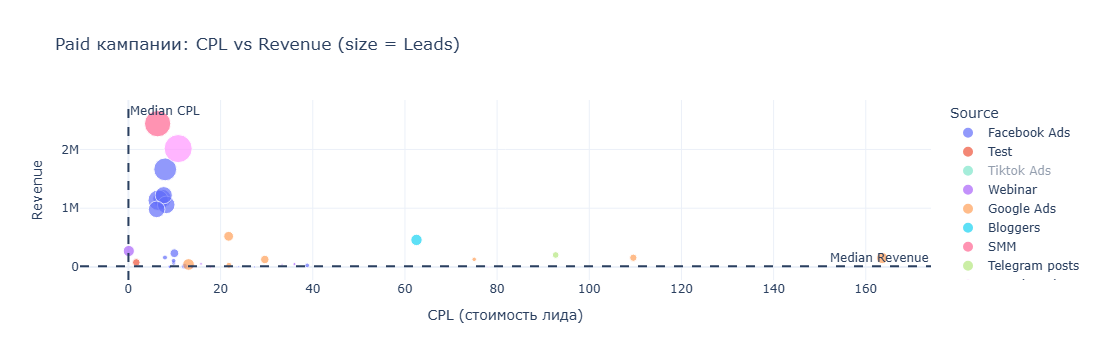

In [41]:
fig_paid = px.scatter(
    plot_df[plot_df['Channel_Type'] == 'Paid'],
    x='CPL',
    y='Revenue',
    size='Leads',
    color='Source',
    hover_name='Campaign',
    hover_data={
        'Leads': ':.0f',
        'Clicks': ':.0f',
        'Spend': ':.2f',
        'Revenue': ':.2f',
        'Profit': ':.2f',
        'ROI': ':.2f'
    },
    title='Paid-Kampagnen: CPL vs. Revenue (Größe = Leads)'
)

fig_paid.add_vline(
    x=plot_df['CPL'].median(),
    line_dash='dash',
    annotation_text='Medianer CPL'
)

fig_paid.add_hline(
    y=plot_df['Revenue'].median(),
    line_dash='dash',
    annotation_text='Medianer Revenue'
)

fig_paid.update_layout(
    xaxis_title='CPL (Kosten pro Lead)',
    yaxis_title='Revenue',
    template='plotly_white'
)

fig_paid.show()

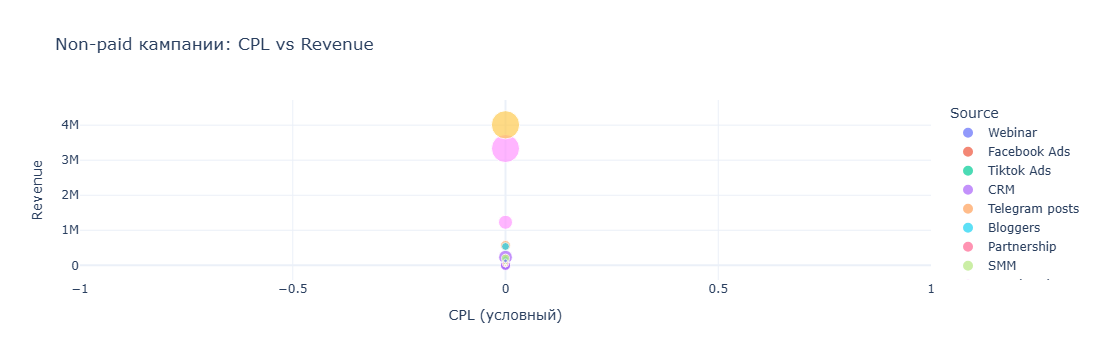

In [42]:
fig_non_paid = px.scatter(
    plot_df[plot_df['Channel_Type'] == 'Non-Paid'],
    x='CPL',
    y='Revenue',
    size='Leads',
    color='Source',
    hover_name='Campaign',
    hover_data={
        'Leads': ':.0f',
        'Revenue': ':.2f',
        'Profit': ':.2f',
        'Revenue_per_Lead': ':.2f'
    },
    title='Non-Paid-Kampagnen: CPL vs. Revenue'
)

fig_non_paid.update_layout(
    xaxis_title='CPL (bedingt)',
    yaxis_title='Revenue',
    template='plotly_white'
)

fig_non_paid.show()

In [2]:
🟢 **Oberer linker Quadrant**
Niedriger CPL + hoher Revenue
➡️ **Sofort skalieren**

🤔 **Oberer rechter Quadrant**
Hoher CPL + hoher Revenue
➡️ **Teuer, aber möglicherweise durch Qualität gerechtfertigt**

🔴 **Unterer rechter Quadrant**
Hoher CPL + niedriger Revenue
➡️ **Optimieren / pausieren**

⚠️ **Unterer linker Quadrant**
Niedriger CPL + niedriger Revenue
➡️ **Zu wenig Daten oder noch nicht vollständig optimiert**

SyntaxError: invalid character '🟢' (U+1F7E2) (1768552740.py, line 1)

Der Vergleich der **Kosten pro Lead (CPL)** mit dem **Gesamtumsatz der Kampagnen** zeigt deutliche Unterschiede in der Effektivität der Marketingaktivitäten.

Einige Kampagnen generieren bei einem **relativ niedrigen CPL einen hohen Umsatz**, wodurch sie besonders **attraktiv für eine Skalierung** sind. Andere Kampagnen hingegen erzeugen **teure Leads oder bringen nur geringe Einnahmen**, was auf die **Notwendigkeit von Optimierungen oder einer Umverteilung des Budgets** hinweist.

Insgesamt ermöglicht die Analyse von **CPL in Kombination mit dem Umsatz**, die **tatsächliche wirtschaftliche Effektivität der Kampagnen** zu bewerten und **fundierte Entscheidungen über Marketinginvestitionen** zu treffen.

### 2.2 **Bewerten Sie die Effektivität verschiedener Marketingquellen (Source) bei der Generierung qualitativ hochwertiger Leads.**

Zur Bewertung der Effektivität verschiedener Marketingquellen verwende ich die Logik, dass ein **qualitativer Lead** ein Kunde ist, der **mindestens einmal eine Zahlung durchgeführt hat (Stage = „Payment Done“).**

Außerdem wurden **nur eindeutige Kontakte (Contact Name)** berücksichtigt, damit ein Kunde **nicht mehrfach gezählt wird**.

In [43]:
# Nur qualitative Leads beibehalten
quality_leads = deals[deals['Stage'] == 'Payment Done'].copy()

# Duplikate nach Contact Name entfernen (damit jeder Kunde nur einmal gezählt wird)
quality_leads_unique = quality_leads.drop_duplicates(subset=['Contact Name'])

# Anzahl qualitativer Leads nach Quellen (Source) berechnen
quality_leads_by_source = quality_leads_unique.groupby('Source')['Contact Name'].count().reset_index(name='Quality_Leads')

# Gesamtzahl der Leads nach Quellen berechnen (für die Konversionsrate)
total_leads_by_source = deals.drop_duplicates(subset=['Contact Name']).groupby('Source')['Contact Name'].count().reset_index(name='Total_Leads')

# Zusammenführen und Anteil qualitativer Leads berechnen
source_efficiency = pd.merge(total_leads_by_source, quality_leads_by_source, on='Source', how='left')
source_efficiency['Quality_Leads'] = source_efficiency['Quality_Leads'].fillna(0)
source_efficiency['Quality_Rate_%'] = (source_efficiency['Quality_Leads'] / source_efficiency['Total_Leads']) * 100

# Sortierung nach qualitativen Leads
source_efficiency = source_efficiency.sort_values('Quality_Leads', ascending=False)

print(source_efficiency)

            Source  Total_Leads  Quality_Leads  Quality_Rate_%
2     Facebook Ads         1692            188       11.111111
3       Google Ads         1445            165       11.418685
4          Organic         1015            134       13.201970
6              SMM          668             85       12.724551
11     Youtube Ads          574             52        9.059233
9       Tiktok Ads          699             51        7.296137
7   Telegram posts          342             38       11.111111
0         Bloggers          353             38       10.764873
10         Webinar          176             24       13.636364
1              CRM         1071             23        2.147526
8             Test           58              3        5.172414
5      Partnership           52              2        3.846154


In [44]:
# funnel_df auf Basis von source_efficiency erstellen
funnel_df = source_efficiency.rename(columns={
    'Total_Leads': 'Leads',
    'Quality_Leads': 'Quality_Leads',
    'Quality_Rate_%': 'Quality_pct'
})

# Überprüfung
print(funnel_df)

            Source  Leads  Quality_Leads  Quality_pct
2     Facebook Ads   1692            188    11.111111
3       Google Ads   1445            165    11.418685
4          Organic   1015            134    13.201970
6              SMM    668             85    12.724551
11     Youtube Ads    574             52     9.059233
9       Tiktok Ads    699             51     7.296137
7   Telegram posts    342             38    11.111111
0         Bloggers    353             38    10.764873
10         Webinar    176             24    13.636364
1              CRM   1071             23     2.147526
8             Test     58              3     5.172414
5      Partnership     52              2     3.846154


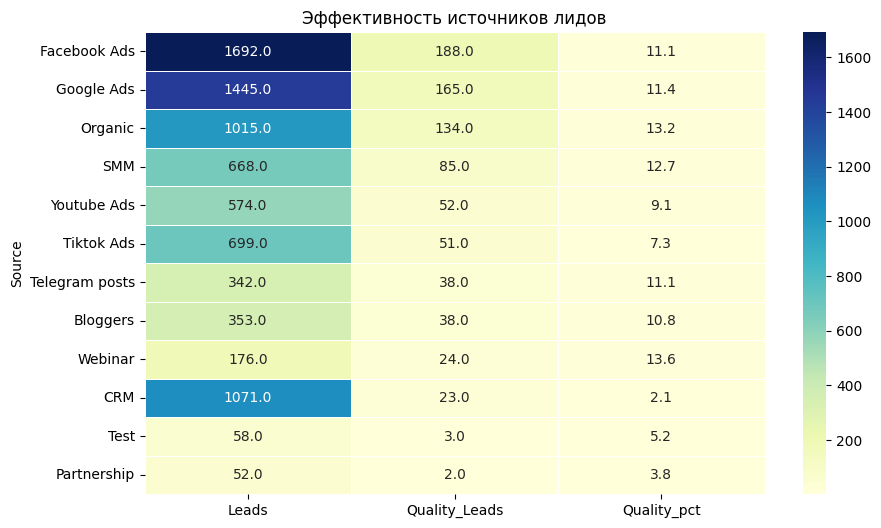

In [45]:
# Heatmap erstellen
heatmap_data = funnel_df[['Source', 'Leads', 'Quality_Leads', 'Quality_pct']]
heatmap_data = heatmap_data.set_index('Source')

plt.figure(figsize=(10,6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5
)
plt.title('Effektivität der Lead-Quellen')
plt.show()

**Facebook Ads** bleibt eine der größten Lead-Quellen: **1692 einzigartige Leads**, davon **188 qualitative Leads**, was einer **Qualitätsrate von 11,1 %** entspricht.

**Google Ads** zeigt vergleichbare Ergebnisse — **1445 einzigartige Leads**, **165 qualitative Leads**, **11,4 %**.

**Organic** und **SMM** zeichnen sich durch einen **höheren Anteil qualitativer Leads** aus — **13,2 % bzw. 12,7 %**, was auf eine **„wärmere“ und stärker interessierte Zielgruppe** hinweist.

**YouTube Ads** und **TikTok Ads** haben bei einer ähnlichen Anzahl von Leads einen **niedrigeren Anteil qualitativer Leads** — **9,1 % bzw. 7,3 %**, was auf eine **geringere Conversion in tatsächliche Zahlungen** hindeuten kann.

Quellen mit einer **kleineren Anzahl von Leads**, wie **Webinar**, **Telegram Posts** und **Bloggers**, zeigen dagegen einen **hohen Anteil qualitativer Leads (bis zu 13,6 %)**.

**CRM** und **Partnership** generieren trotz vorhandener einzigartiger Kontakte **relativ wenige qualitative Leads**, was darauf hindeutet, dass diese Kanäle **überarbeitet oder hinsichtlich der Lead-Qualität verbessert werden sollten**.

Die Verwendung der Kennzahl **einzigartiger zahlender Kunden** ermöglicht eine **realistischere Bewertung der Effektivität der Marketingquellen**. Auf Basis dieser Ergebnisse lässt sich feststellen, dass **Organic, SMM und Webinar die höchste Conversion in qualitative Leads** zeigen, während Quellen mit **hoher Aktivität, aber einem niedrigen Anteil zahlender Kunden** (z. B. **TikTok Ads und CRM**) **eine zusätzliche Analyse und Optimierung erfordern**.

C:\Users\Acer\AppData\Local\Temp\ipykernel_7272\2174964274.py:11: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\Acer\AppData\Local\Temp\ipykernel_7272\2174964274.py:21: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



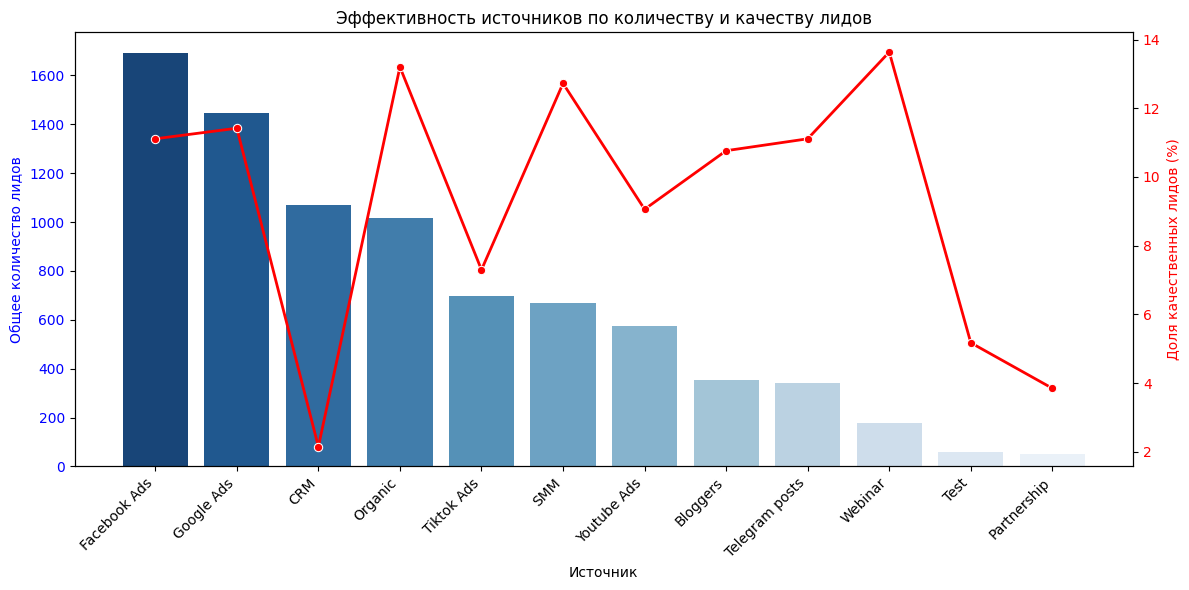

In [46]:
# Diagramm
import matplotlib.pyplot as plt
import seaborn as sns

# Sortierung nach Total_Leads für eine übersichtlichere Darstellung
source_efficiency_sorted = source_efficiency.sort_values('Total_Leads', ascending=False)

fig, ax1 = plt.subplots(figsize=(12,6))

# Balken: Gesamtzahl der Leads
sns.barplot(
    data=source_efficiency_sorted,
    x='Source',
    y='Total_Leads',
    palette='Blues_r',
    ax=ax1
)
ax1.set_xlabel('Quelle')
ax1.set_ylabel('Gesamtzahl der Leads', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Linie: Anteil qualitativer Leads
ax2 = ax1.twinx()
sns.lineplot(
    data=source_efficiency_sorted,
    x='Source',
    y='Quality_Rate_%',
    color='red',
    marker='o',
    linewidth=2,
    ax=ax2
)
ax2.set_ylabel('Anteil qualitativer Leads (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Effektivität der Quellen nach Anzahl und Qualität der Leads')
plt.tight_layout()
plt.show()

Aus dem Diagramm ist ersichtlich, dass die **Effektivität der Lead-Quellen ungleich verteilt** ist.

Die **größte Anzahl an Leads** kommt von **Facebook Ads** und **Google Ads**, mit jeweils etwa **1400–1700 Leads**. Der Anteil qualitativer Leads ist jedoch nicht der höchste und liegt bei etwa **10–11 %**.

Quellen wie **Organic**, **SMM** und **Webinar** generieren zwar **weniger Leads insgesamt**, weisen jedoch einen **deutlich höheren Anteil qualitativer Leads** auf — etwa **12–14 %**. Dies deutet auf eine **zielgerichtetere Zielgruppe und potenziell bessere Conversion in tatsächliche Abschlüsse** hin.

Gleichzeitig zeigen **CRM**, **Test** und **Partnership** sowohl ein **geringes Gesamtvolumen an Leads** als auch einen **niedrigen Anteil qualitativer Leads**, wodurch sie zu den **am wenigsten effektiven Quellen** gehören.

Insgesamt zeigt das Diagramm, dass **die volumenstärksten Kanäle nicht unbedingt die qualitativ besten sind**. Für eine optimale Marketingstrategie kann es daher sinnvoll sein, **bezahlte Kanäle zur Lead-Generierung im großen Umfang** mit **organischen oder spezialisierten Kanälen zur Verbesserung der Lead-Qualität** zu kombinieren.

# Block 3
## Analyse der Effizienz der Vertriebsabteilung

Bewerten Sie die Effizienz einzelner Deal-Owner und Werbekampagnen im Hinblick auf die Anzahl bearbeiteter Deals, die Konversionsrate sowie den Gesamtumsatz.

### 1. Bewerten Sie die Effizienz einzelner Deal-Owner und Werbekampagnen hinsichtlich der Anzahl bearbeiteter Deals, der Konversionsrate und des Gesamtumsatzes.

**1. Analyse der Effizienz einzelner Deal Owner hinsichtlich der Anzahl bearbeiteter Deals**

Dafür werden folgende Annahmen verwendet:

1. Die **Anzahl der bearbeiteten Deals nach Deal Owner Name** wird anhand **einzigartiger Contact Name** berechnet.
   Dies basiert auf der Annahme, dass der Manager pro Kunde **nur einmal aktiv interagiert** (d. h. bei wiederholten Zahlungen kontaktiert der Manager den Kunden nicht jedes Mal erneut).

2. Zusätzlich wird die **Anzahl der Deals mit Zahlung** betrachtet (**Initial Amount Paid > 0**).

3. Außerdem wird die **Anzahl der Anrufe** analysiert, wobei **alle Anrufe gezählt werden, außer solche mit dem Status „Missed“**.

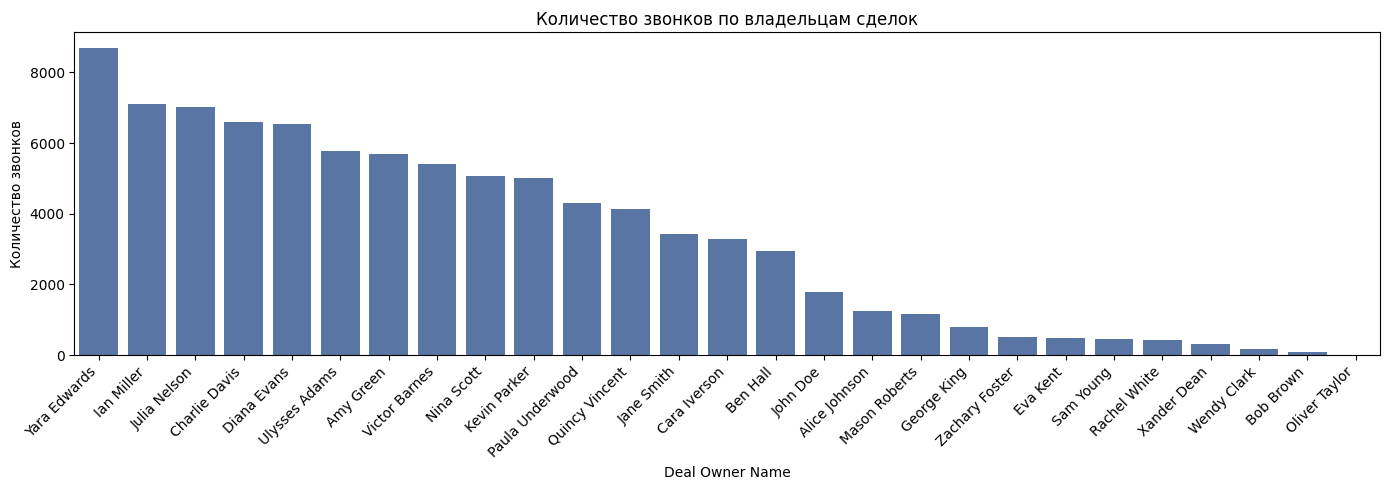

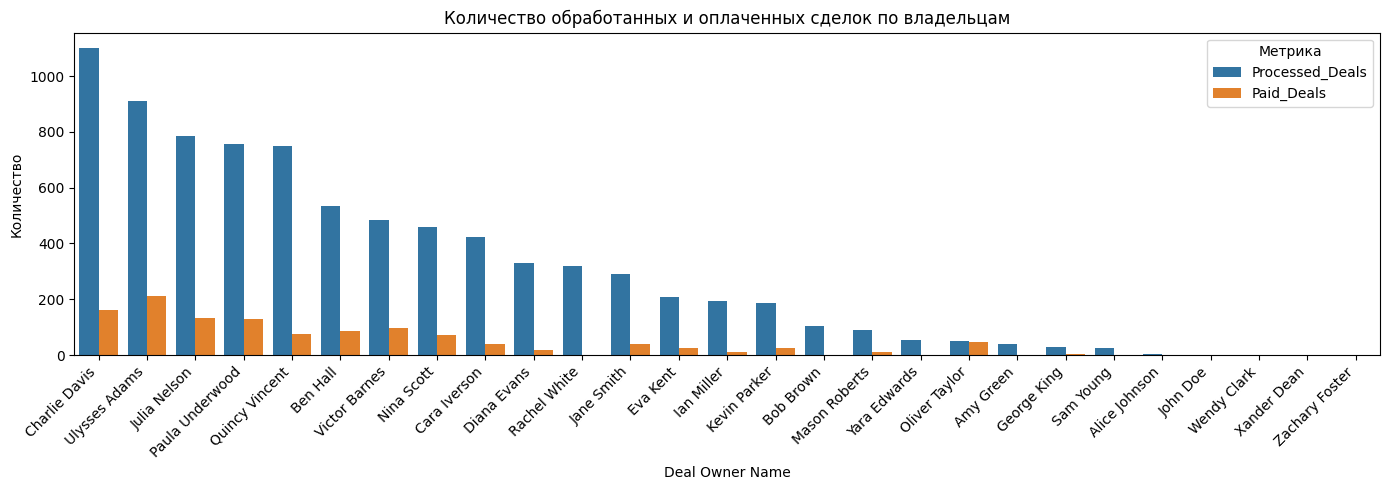

In [47]:
# 1️⃣ Anzahl bearbeiteter Deals (einzigartige Kontakte)
processed_deals = deals.drop_duplicates(subset=['Contact Name'])
deals_count = processed_deals.groupby('Deal Owner Name')['Contact Name'].count().reset_index(name='Processed_Deals')

# 2️⃣ Anzahl der Anrufe pro Deal Owner (ohne verpasste Anrufe)
calls_filtered = calls[calls['Call Status'] != 'Missed']
calls_count = calls_filtered.groupby('Call Owner Name')['Id'].count().reset_index(name='Calls_Count')

# 3️⃣ Anzahl der Deals mit Zahlung
paid_deals = processed_deals[processed_deals['Initial Amount Paid'] > 0]
paid_count = paid_deals.groupby('Deal Owner Name')['Contact Name'].count().reset_index(name='Paid_Deals')

# 4️⃣ Metriken zusammenführen
owner_stats = pd.merge(deals_count, calls_count, left_on='Deal Owner Name', right_on='Call Owner Name', how='left')
owner_stats = pd.merge(owner_stats, paid_count, on='Deal Owner Name', how='left')
owner_stats[['Calls_Count', 'Paid_Deals']] = owner_stats[['Calls_Count', 'Paid_Deals']].fillna(0)

# 5️⃣ Sortierung für das Diagramm der Anrufe
owner_stats_calls_sorted = owner_stats.sort_values('Calls_Count', ascending=False)

# Diagramm 1 — nur Anrufe
plt.figure(figsize=(14,5))
sns.barplot(data=owner_stats_calls_sorted, x='Deal Owner Name', y='Calls_Count', color='#4c72b0')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Anzahl der Anrufe')
plt.title('Anzahl der Anrufe nach Deal Owner')
plt.tight_layout()
plt.show()

# 6️⃣ Sortierung für das Diagramm der Deals
owner_stats_deals_sorted = owner_stats.sort_values('Processed_Deals', ascending=False)

# Diagramm 2 — bearbeitete und bezahlte Deals
plt.figure(figsize=(14,5))
sns.barplot(
    data=owner_stats_deals_sorted.melt(id_vars='Deal Owner Name', value_vars=['Processed_Deals','Paid_Deals']),
    x='Deal Owner Name',
    y='value',
    hue='variable'
)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Anzahl')
plt.title('Anzahl bearbeiteter und bezahlter Deals nach Deal Owner')
plt.legend(title='Metrik')
plt.tight_layout()
plt.show()

**Analyse der Top-/Bottom-10 Manager nach Paid_Deals (>0)**, wobei prozentual folgende Kennzahlen dargestellt werden:

* **Anzahl bearbeiteter Deals**
* **Anzahl der Anrufe**
* **Anzahl der bezahlten Deals**

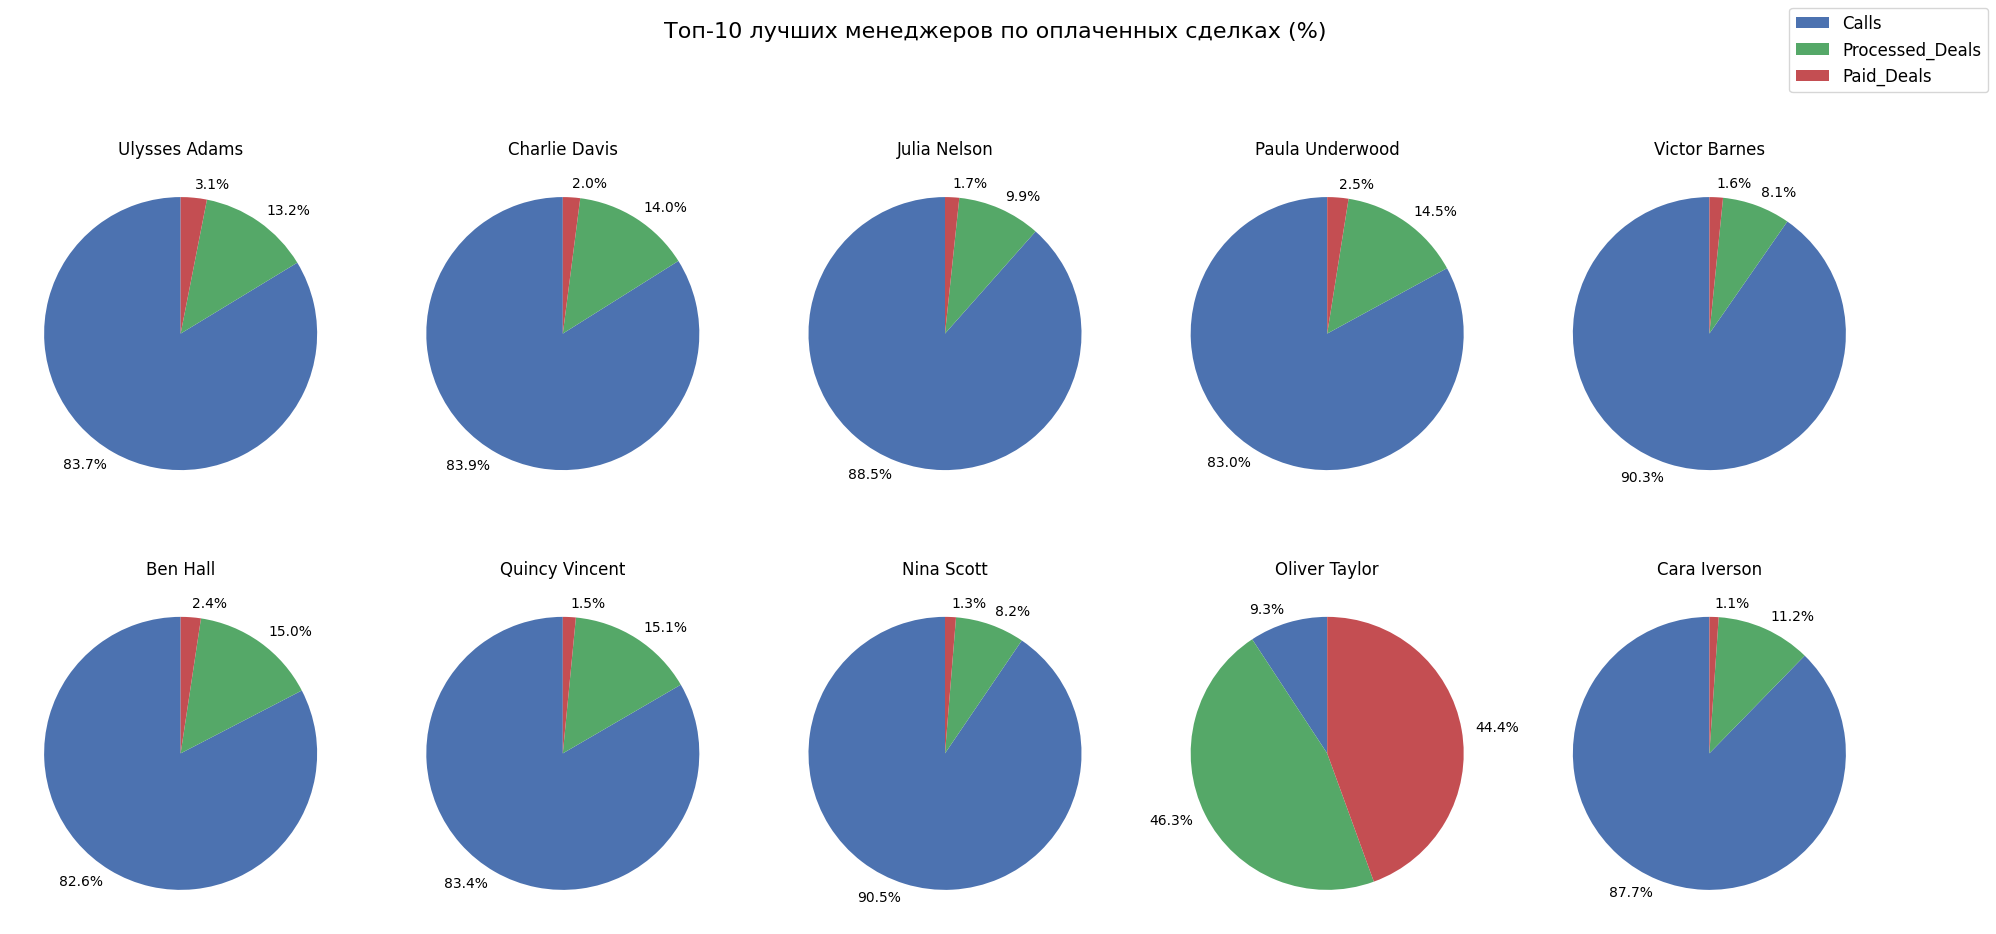

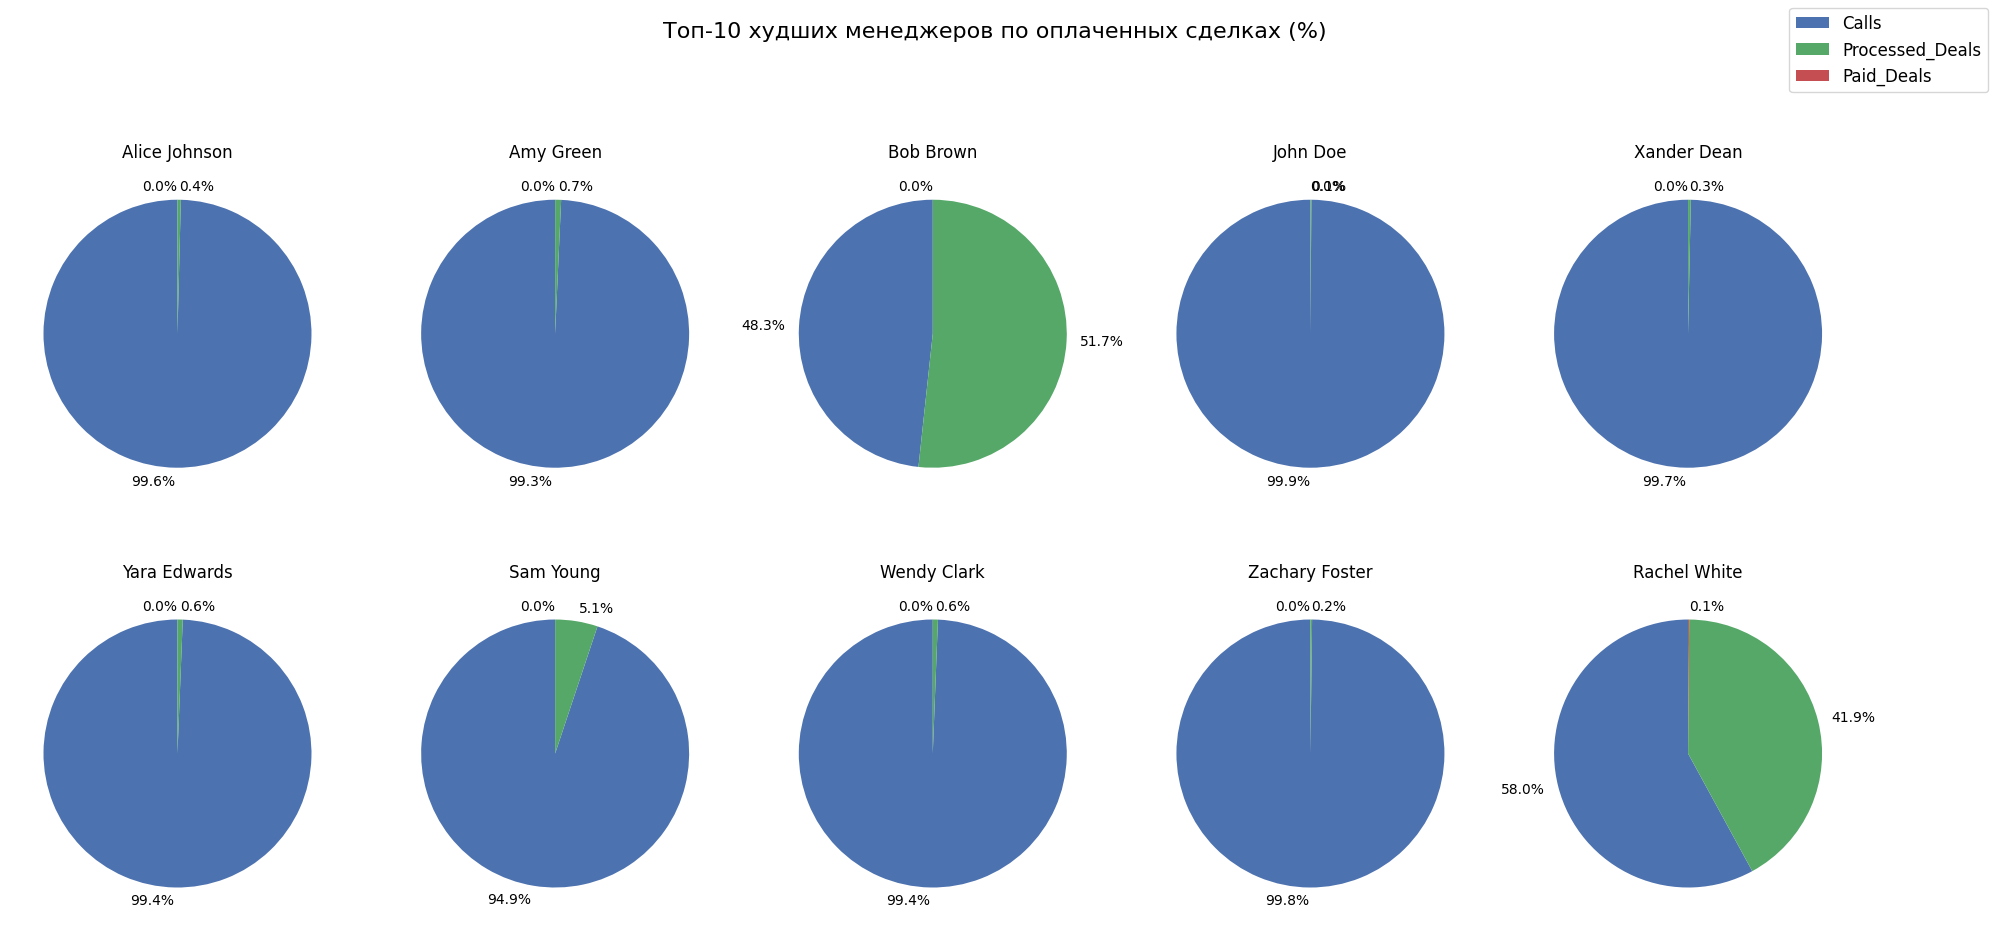

In [48]:
# Sortierung nach Anzahl der bezahlten Deals
top10_best = owner_stats.sort_values('Paid_Deals', ascending=False).head(10)
top10_worst = owner_stats.sort_values('Paid_Deals', ascending=True).head(10)

def plot_pie_charts(df, title):
    fig, axes = plt.subplots(2, 5, figsize=(20, 10))
    axes = axes.flatten()

    labels = ['Calls', 'Processed_Deals', 'Paid_Deals']
    colors = ['#4c72b0', '#55a868', '#c44e52']

    for idx, (_, row) in enumerate(df.iterrows()):
        values = [row['Calls_Count'], row['Processed_Deals'], row['Paid_Deals']]
        total = sum(values)
        if total == 0:
            values_pct = [0, 0, 0]
        else:
            values_pct = [v / total * 100 for v in values]

        axes[idx].pie(
            values_pct,
            labels=[f'{v:.1f}%' for v in values_pct],
            colors=colors,
            startangle=90,
            autopct=None
        )
        axes[idx].set_title(row['Deal Owner Name'])

    fig.legend(labels=labels, loc='upper right', fontsize=12)
    plt.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0, 0.95, 0.95])
    plt.show()

# Top-10 der besten Manager
plot_pie_charts(top10_best, 'Top-10 Manager nach Anzahl bezahlter Deals (%)')

# Top-10 der schwächsten Manager
plot_pie_charts(top10_worst, 'Bottom-10 Manager nach Anzahl bezahlter Deals (%)')

**Anschließend analysieren wir die Effizienz der Manager anhand der Verkaufssumme und der Konversionsrate.**

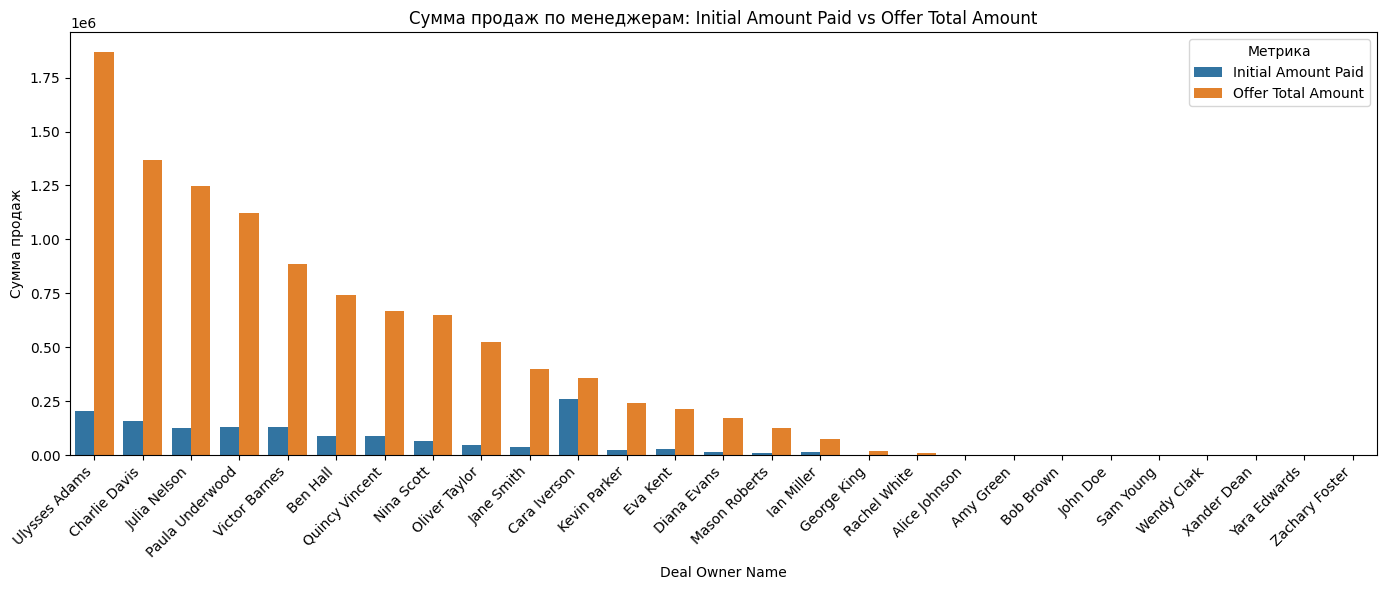

In [49]:
# 1️⃣ Qualitative Leads (Payment Done), eindeutig nach Contact Name
quality_leads = deals[deals['Stage'] == 'Payment Done'].copy()
quality_leads_unique = quality_leads.drop_duplicates(subset=['Contact Name'])

# 2️⃣ Gesamtzahl der Leads nach Managern (für die Conversion)
total_leads_by_manager = deals.drop_duplicates(subset=['Contact Name']) \
    .groupby('Deal Owner Name')['Contact Name'] \
    .count() \
    .reset_index(name='Total_Leads')

# 3️⃣ Qualitative Leads nach Managern
quality_leads_by_manager = quality_leads_unique.groupby('Deal Owner Name')['Contact Name'] \
    .count() \
    .reset_index(name='Quality_Leads')

# 4️⃣ Zusammenführen und Conversion berechnen
manager_efficiency = pd.merge(
    total_leads_by_manager,
    quality_leads_by_manager,
    on='Deal Owner Name',
    how='left'
)
manager_efficiency['Quality_Leads'] = manager_efficiency['Quality_Leads'].fillna(0)
manager_efficiency['Quality_Rate_%'] = (
    manager_efficiency['Quality_Leads'] / manager_efficiency['Total_Leads']
) * 100

# 5️⃣ Sortierung nach qualitativen Leads
manager_efficiency = manager_efficiency.sort_values('Quality_Leads', ascending=False)

# 6️⃣ Gesamte Verkaufssumme nach Managern
sales_summary = deals.drop_duplicates(subset=['Contact Name']).groupby('Deal Owner Name').agg({
    'Initial Amount Paid': 'sum',
    'Offer Total Amount': 'sum'
}).reset_index()

# 7️⃣ Effizienz und Verkaufsdaten für die Visualisierung zusammenführen
manager_stats = pd.merge(manager_efficiency, sales_summary, on='Deal Owner Name', how='left')

# 8️⃣ Visualisierung: 2 Balken für Verkaufsvolumen
plt.figure(figsize=(14,6))
manager_stats_sorted = manager_stats.sort_values('Offer Total Amount', ascending=False)

sns.barplot(
    data=manager_stats_sorted.melt(
        id_vars='Deal Owner Name',
        value_vars=['Initial Amount Paid', 'Offer Total Amount']
    ),
    x='Deal Owner Name',
    y='value',
    hue='variable'
)

plt.xticks(rotation=45, ha='right')
plt.ylabel('Verkaufssumme')
plt.title('Verkaufssumme nach Managern: Initial Amount Paid vs. Offer Total Amount')
plt.legend(title='Metrik')
plt.tight_layout()
plt.show()

In [50]:
# Daten für eine zusätzliche Analyse der Manager vorbereiten

deals_m = deals.copy()

# Kennzeichen für einen erfolgreichen Deal
deals_m['is_win'] = (deals_m['Stage'] == 'Payment Done').astype(int)

# SLA_days sicherheitshalber in numerisches Format umwandeln
deals_m['SLA_days'] = pd.to_numeric(deals_m['SLA_days'], errors='coerce')

# Deals ohne SLA oder ohne Manager entfernen
deals_m = deals_m.dropna(subset=['Deal Owner Name', 'SLA_days'])

In [51]:
manager_stats = (
    deals_m
    .groupby('Deal Owner Name')
    .agg(
        deals_count=('is_win', 'count'),
        win_rate=('is_win', 'mean'),
        avg_SLA=('SLA_days', 'mean'),
        median_SLA=('SLA_days', 'median'),
        fast_SLA_pct=('SLA_days', lambda x: (x <= 1).mean())
    )
    .reset_index()
)

# in Prozent umwandeln
manager_stats['win_rate'] *= 100
manager_stats['fast_SLA_pct'] *= 100

manager_stats = manager_stats.sort_values('win_rate', ascending=False)

manager_stats

,Deal Owner Name,deals_count,win_rate,avg_SLA,median_SLA,fast_SLA_pct
11,John Doe,2,50.000000,76.000000,76.0,50.000000
16,Oliver Taylor,65,20.000000,74.861538,47.0,9.230769
13,Kevin Parker,195,8.205128,28.128205,3.0,32.307692
8,George King,26,7.692308,62.115385,31.0,3.846154
21,Ulysses Adams,1478,6.292287,17.633965,4.0,30.784844
22,Victor Barnes,469,4.904051,9.321962,2.0,45.415778
7,Eva Kent,218,4.587156,5.077982,2.0,33.027523
17,Paula Underwood,1289,4.577192,12.317300,3.0,36.927851
5,Charlie Davis,2163,4.530744,19.765603,5.0,31.946371
2,Ben Hall,572,4.370629,5.120629,2.0,43.881119


### **Bewertung der Arbeit der Manager**

| Kennzahl         | 🟢 Gut  | 🟡 Mittel | 🔴 Schwach |
| ---------------- | ------- | --------- | ---------- |
| **win_rate**     | ≥ 25 %  | 15–25 %   | < 15 %     |
| **median_SLA**   | ≤ 1 Tag | 1–2 Tage  | > 2 Tage   |
| **fast_SLA_pct** | ≥ 60 %  | 40–60 %   | < 40 %     |
| **deals_count**  | ≥ 30    | 15–30     | < 15       |

In [52]:
def color_win_rate(val):
    if val >= 25:
        return 'background-color: #d4edda'  # green
    elif val >= 15:
        return 'background-color: #fff3cd'  # yellow
    else:
        return 'background-color: #f8d7da'  # red

def color_median_sla(val):
    if val <= 1:
        return 'background-color: #d4edda'
    elif val <= 2:
        return 'background-color: #fff3cd'
    else:
        return 'background-color: #f8d7da'

def color_fast_sla(val):
    if val >= 60:
        return 'background-color: #d4edda'
    elif val >= 40:
        return 'background-color: #fff3cd'
    else:
        return 'background-color: #f8d7da'

def color_deals(val):
    if val >= 30:
        return 'background-color: #d4edda'
    elif val >= 15:
        return 'background-color: #fff3cd'
    else:
        return 'background-color: #f8d7da'


styled_managers = (
    manager_stats
    .style
    .format({
        'win_rate': '{:.1f}%',
        'avg_SLA': '{:.2f}',
        'median_SLA': '{:.2f}',
        'fast_SLA_pct': '{:.1f}%'
    })
    .applymap(color_win_rate, subset=['win_rate'])
    .applymap(color_median_sla, subset=['median_SLA'])
    .applymap(color_fast_sla, subset=['fast_SLA_pct'])
    .applymap(color_deals, subset=['deals_count'])
)

styled_managers

C:\Users\Acer\AppData\Local\Temp\ipykernel_7272\3727656716.py:43: FutureWarning:

Styler.applymap has been deprecated. Use Styler.map instead.

C:\Users\Acer\AppData\Local\Temp\ipykernel_7272\3727656716.py:44: FutureWarning:

Styler.applymap has been deprecated. Use Styler.map instead.

C:\Users\Acer\AppData\Local\Temp\ipykernel_7272\3727656716.py:45: FutureWarning:

Styler.applymap has been deprecated. Use Styler.map instead.

C:\Users\Acer\AppData\Local\Temp\ipykernel_7272\3727656716.py:46: FutureWarning:

Styler.applymap has been deprecated. Use Styler.map instead.



,Deal Owner Name,deals_count,win_rate,avg_SLA,median_SLA,fast_SLA_pct
11,John Doe,2,50.0%,76.00,76.00,50.0%
16,Oliver Taylor,65,20.0%,74.86,47.00,9.2%
13,Kevin Parker,195,8.2%,28.13,3.00,32.3%
8,George King,26,7.7%,62.12,31.00,3.8%
21,Ulysses Adams,1478,6.3%,17.63,4.00,30.8%
22,Victor Barnes,469,4.9%,9.32,2.00,45.4%
7,Eva Kent,218,4.6%,5.08,2.00,33.0%
17,Paula Underwood,1289,4.6%,12.32,3.00,36.9%
5,Charlie Davis,2163,4.5%,19.77,5.00,31.9%
2,Ben Hall,572,4.4%,5.12,2.00,43.9%


## KPI für Sales Manager

Diese KPIs können direkt in **Regelwerke, Performance-Bewertung oder Motivationssysteme** integriert werden.

---

## 🎯 Empfohlene KPI-Struktur

### 🔹 KPI 1 — Reaktionsgeschwindigkeit (kritisch)

**Median SLA ≤ 1 Tag**

* wird automatisch gemessen
* hat den größten Einfluss auf das Ergebnis
* ist ein **steuerbarer Prozessindikator**

---

### 🔹 KPI 2 — Prozessdisziplin

**Mindestens 60 % der Deals mit SLA ≤ 1 Tag**

* zeigt **Systematik statt einzelner schneller Fälle**
* verhindert das Muster *„manchmal arbeite ich schnell“*

---

### 🔹 KPI 3 — Effektivität

**Win Rate ≥ 20–25 %**

* Schwellenwert kann je nach **Lead-Qualität oder Kanal** angepasst werden

---

### 🔹 KPI 4 — Volumen (Kontrollindikator)

**Mindestens N Deals pro Zeitraum**
(z. B. **30 Deals pro Monat**)

* stellt sicher, dass Kennzahlen **statistisch aussagekräftig** sind

---

## 🧠 Zentrale Management-Idee

> **Manager werden nicht nur nach dem Ergebnis bewertet, sondern auch nach der Qualität des Prozesses, der zu diesem Ergebnis führt.**

---

# 📊 Beispiel-Slide: „Effizienz der Manager und SLA“

## 🔍 Zentrale Beobachtungen

* Die **Geschwindigkeit des ersten Kontakts** beeinflusst direkt die Wahrscheinlichkeit einer Zahlung.
* Deals, die **innerhalb des ersten Tages bearbeitet werden**, werden deutlich häufiger abgeschlossen.
* Zwischen den Managern bestehen **erhebliche Unterschiede im SLA**, die **nicht mit der Anzahl der Leads zusammenhängen**.

---

## 📊 Was die Analyse zeigt

* Es gibt Manager, die **schnell reagieren und konstant Deals abschließen**.
* Andere weisen **langsame SLA-Werte und niedrige Conversion-Raten** auf — ein **Risikobereich**.
* Die **Reaktionsgeschwindigkeit ist ein steuerbarer Prozess**, keine individuelle Eigenschaft.

---

## ✅ Empfehlungen

* Einführung eines Standards: **Erster Kontakt ≤ 1 Tag**
* Nutzung von **Median SLA als zentralem KPI**
* **Best Practices der Top-Manager** im Team verbreiten
* **Lead-Verteilung unter Berücksichtigung der Reaktionsgeschwindigkeit**
* SLA als **Management-Instrument**, nicht nur als Kontrollkennzahl, einsetzen

---

💡 **Für das Management signalisiert diese Analyse**, dass du:

* nicht nur **Zahlen berechnest**,
* sondern **Vertriebsprozesse verstehst**,
* **konkrete Managemententscheidungen ableiten kannst**,
* und **in Business-Logik argumentierst**.

---

✅ Wenn du möchtest, kann ich dir als nächsten Schritt auch helfen:

* daraus eine **5–7-Slide Präsentation** zu bauen (sehr полезно для защиты проекта)
* **KPI-System für Bonus/Kommission** сформулировать
* или написать **короткий 2-минутный Pitch**, как это презентовать руководству.

**Wer arbeitet schneller und wer erzielt bessere Ergebnisse.**
Der **Median des SLA** ist eine zentrale Kennzahl, da er die **typische Reaktionsgeschwindigkeit eines Managers** widerspiegelt.

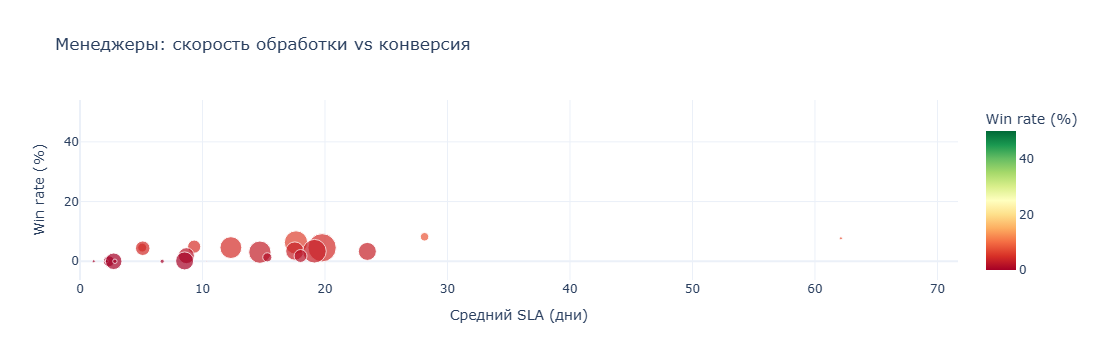

In [53]:
# --- Grenze für die X-Achse berechnen (95. Perzentil) ---
x_max = manager_stats['avg_SLA'].quantile(0.95)

# --- Scatter-Plot erstellen ---
fig_mgr = px.scatter(
    manager_stats,
    x='avg_SLA',
    y='win_rate',
    size='deals_count',
    color='win_rate',
    color_continuous_scale='RdYlGn',
    hover_name='Deal Owner Name',
    hover_data={
        'avg_SLA': ':.1f',
        'median_SLA': ':.1f',
        'deals_count': ':.0f',
        'fast_SLA_pct': ':.1f'
    },
    title='Manager: Bearbeitungsgeschwindigkeit vs. Conversion'
)

# --- Layout ---
fig_mgr.update_layout(
    xaxis_title='Durchschnittliches SLA (Tage)',
    yaxis_title='Win Rate (%)',
    template='plotly_white',
    coloraxis_colorbar=dict(title='Win Rate (%)')
)

# --- X-Achse zur besseren Lesbarkeit begrenzen ---
fig_mgr.update_xaxes(range=[0, x_max])

fig_mgr.show()

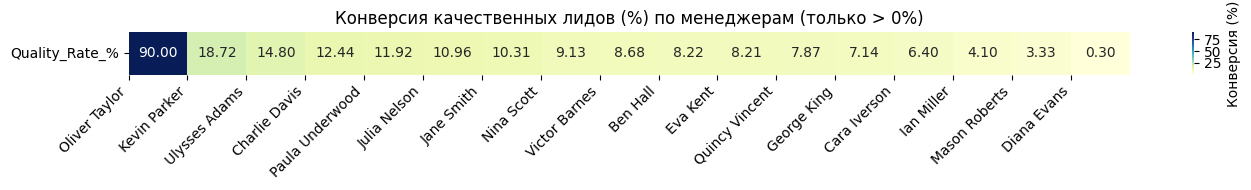

In [54]:
# Qualitative Leads (Payment Done), eindeutig nach Contact Name
quality_leads = deals[deals['Stage'] == 'Payment Done'].copy()
quality_leads_unique = quality_leads.drop_duplicates(subset=['Contact Name'])

# Gesamtzahl der Leads pro Manager
total_leads_by_manager = deals.drop_duplicates(subset=['Contact Name']) \
    .groupby('Deal Owner Name')['Contact Name'] \
    .count() \
    .reset_index(name='Total_Leads')

# Qualitative Leads pro Manager
quality_leads_by_manager = quality_leads_unique.groupby('Deal Owner Name')['Contact Name'] \
    .count() \
    .reset_index(name='Quality_Leads')

# Zusammenführen und Conversion berechnen
manager_efficiency = pd.merge(
    total_leads_by_manager,
    quality_leads_by_manager,
    on='Deal Owner Name',
    how='left'
)
manager_efficiency['Quality_Leads'] = manager_efficiency['Quality_Leads'].fillna(0)
manager_efficiency['Quality_Rate_%'] = (
    manager_efficiency['Quality_Leads'] / manager_efficiency['Total_Leads']
) * 100

# Nur Manager mit Conversion > 0 behalten
manager_efficiency = manager_efficiency[manager_efficiency['Quality_Rate_%'] > 0]

# Sortierung nach Conversion für die Visualisierung
manager_efficiency = manager_efficiency.sort_values('Quality_Rate_%', ascending=False)

# Heatmap der Conversion
plt.figure(figsize=(14,2))
sns.heatmap(
    manager_efficiency[['Quality_Rate_%']].T,
    annot=True,
    fmt=".2f",
    cmap='YlGnBu',
    cbar_kws={'label': 'Conversion (%)'}
)

plt.xticks(
    ticks=range(len(manager_efficiency)),
    labels=manager_efficiency['Deal Owner Name'],
    rotation=45,
    ha='right'
)
plt.yticks(rotation=0)
plt.title('Conversion qualitativer Leads (%) nach Managern (nur > 0%)')
plt.tight_layout()
plt.show()

**Nun analysieren wir dieselben Kennzahlen, jedoch im Kontext der Werbekampagnen.**

Wir betrachten die **Gesamtzahl der Impressionen (Impressions)** und **Klicks (Clicks)**, um zu verstehen, **welche Kampagnen tatsächlich Traffic generieren**.
Dafür wählen wir die **Top-20 Kampagnen nach der Summe der Impressionen** aus.

Anschließend analysieren wir die **Conversion von Impressionen zu Klicks (Click-Through-Rate, CTR)**.
Mithilfe einer **Heatmap** lässt sich visualisieren, **welche Kampagnen ihre Impressionen am effektivsten in Klicks umwandeln**.

In [55]:
# 1. Impressionen und Klicks nach Campaign und Source aggregieren
campaign_stats = spend.groupby(['Campaign', 'Source']).agg({
    'Impressions': 'sum',
    'Clicks': 'sum'
}).reset_index()

# 2. CTR (%) berechnen
campaign_stats['CTR_%'] = (campaign_stats['Clicks'] / campaign_stats['Impressions']) * 100

# 3. Top-20 Kampagnen nach Impressionen auswählen
top20_campaigns = campaign_stats.sort_values('Impressions', ascending=False).head(20)

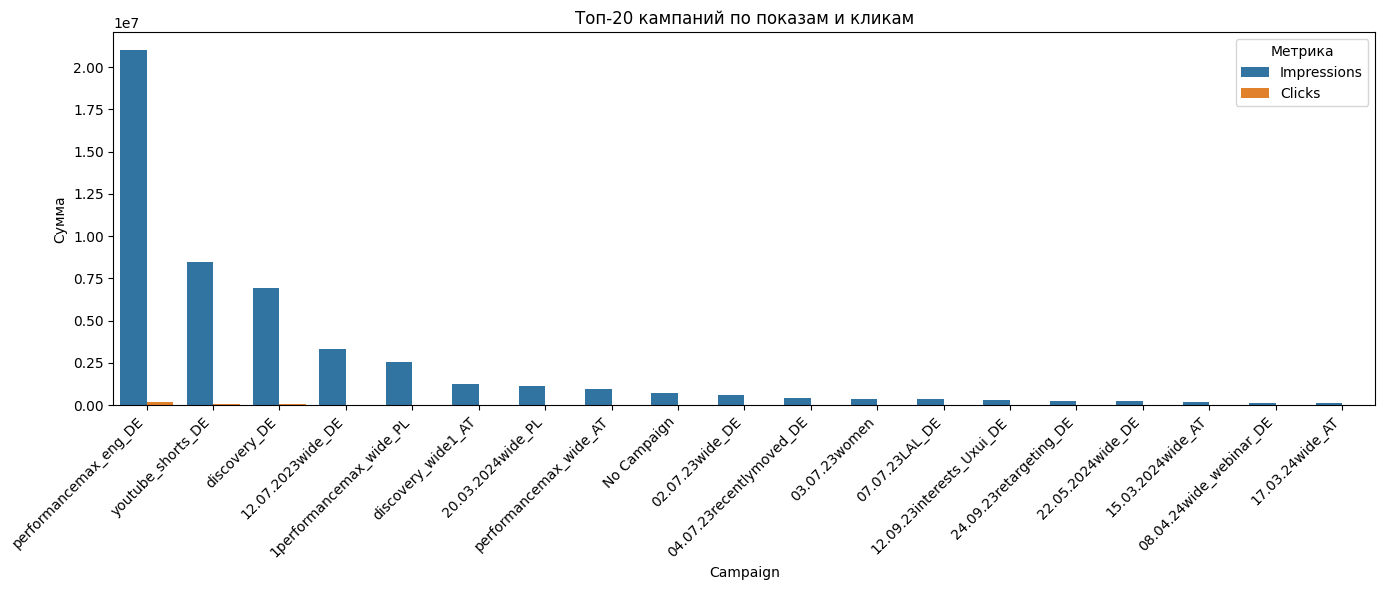

In [56]:
# Diagramm 1: Impressions und Clicks
plt.figure(figsize=(14,6))
top20_melted = top20_campaigns.melt(id_vars=['Campaign', 'Source'], value_vars=['Impressions','Clicks'])

sns.barplot(
    data=top20_melted,
    x='Campaign',
    y='value',
    hue='variable'
)

plt.xticks(rotation=45, ha='right')
plt.ylabel('Summe')
plt.title('Top-20 Kampagnen nach Impressionen und Klicks')
plt.legend(title='Metrik')
plt.tight_layout()
plt.show()

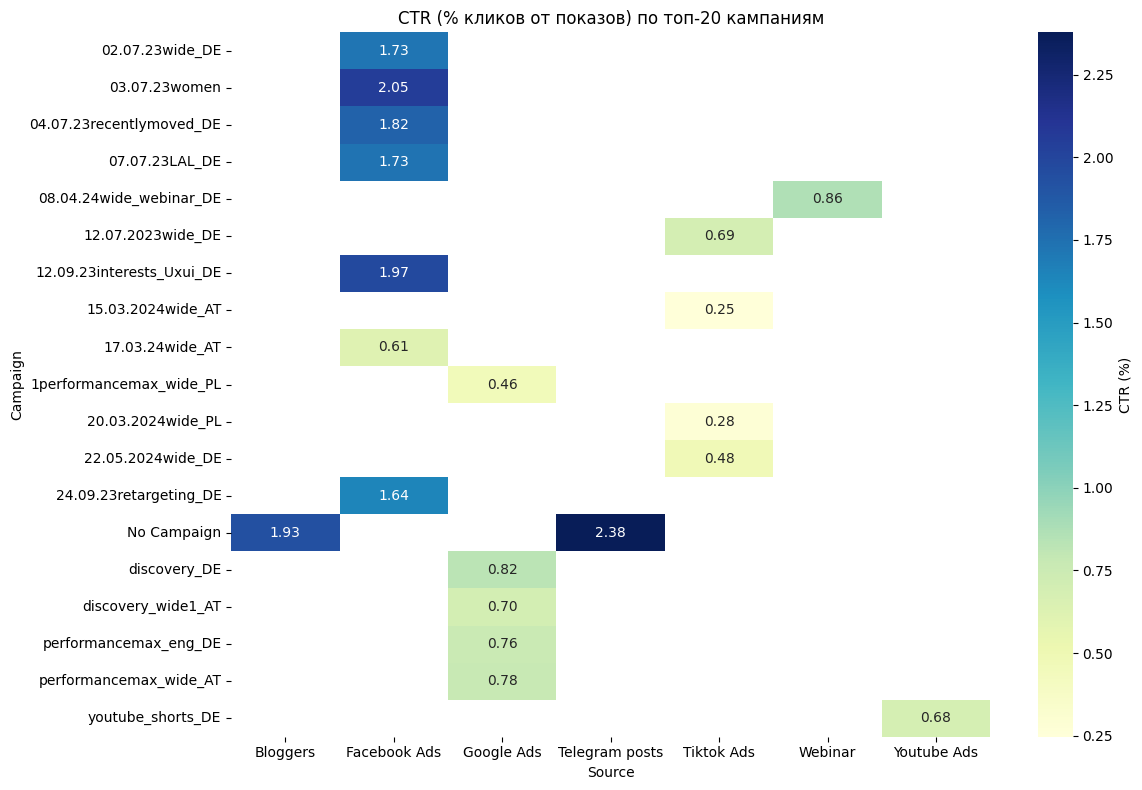

In [57]:
# Pivot-Tabelle für die Heatmap
ctr_pivot = top20_campaigns.pivot(index='Campaign', columns='Source', values='CTR_%')

plt.figure(figsize=(12,8))
sns.heatmap(
    ctr_pivot,
    annot=True,
    fmt=".2f",
    cmap='YlGnBu',
    cbar_kws={'label':'CTR (%)'}
)

plt.title('CTR (% Klicks von Impressionen) für die Top-20 Kampagnen')
plt.ylabel('Campaign')
plt.xlabel('Source')
plt.tight_layout()
plt.show()

### ⚠️ Hinweis zur Interpretation

Ich kann die Zahlen in deiner Tabelle nicht sehen, daher kann ich den **exakten CTR nicht verifizieren**. Inhaltlich und methodisch ist dein Fazit jedoch logisch aufgebaut. Unten ist eine **sauber formulierte, leicht korrigierte Version auf Deutsch**, die du direkt in einen Bericht oder eine Präsentation einfügen kannst.

---

# Analyse der CTR der Top-20 Kampagnen

### 1️⃣ Hoher CTR

Die Kampagne **„12.07.2023wide_DE“ (Facebook Ads)** zeigt mit etwa **2,38 %** die höchste Klickrate im Verhältnis zu den Impressionen.

Auch die Kampagnen **„03.07.23women“ (Facebook Ads)** sowie **„12.09.23interests_Uxui_DE“** erreichen einen relativ hohen **CTR von etwa 2 %**, was auf eine **hohe Relevanz der Anzeige für die Zielgruppe** hinweist.

---

### 2️⃣ Mittlerer CTR

Kampagnen mit einem **CTR von etwa 0,7–1 %** (z. B. **„discovery_DE“**, **„youtube_shorts_DE“**, **„08.04.24wide_webinar_DE“**) zeigen eine **durchschnittliche Klickrate**.

Dies deutet darauf hin, dass die Anzeigen zwar Aufmerksamkeit erzeugen, aber **noch Optimierungspotenzial bei Kreativmaterial oder Targeting besteht**.

---

### 3️⃣ Niedriger CTR

Einige Kampagnen, wie **„15.03.2024wide_AT“** und **„20.03.2024wide_PL“**, weisen einen **sehr niedrigen CTR von etwa 0,25–0,28 %** auf.

Dies bedeutet, dass **trotz vieler Impressionen nur sehr wenige Nutzer auf die Anzeigen klicken**, was auf mögliche Probleme bei **Targeting, Kreativmaterial oder Angebotsrelevanz** hinweisen kann.

---

# Gesamtergebnis

* Kampagnen über **Facebook Ads und Google Ads** erreichen häufig den **höchsten CTR**.
* Andere Kanäle wie **Webinar, YouTube Ads, TikTok Ads oder Telegram** zeigen teilweise eine **geringere Klick-Conversion**.
* Dies deutet darauf hin, dass **Kreativmaterial und Targeting auf bestimmten Plattformen besser funktionieren**, während andere Kampagnen **optimiert oder angepasst werden sollten**.

---

✅ **Empfehlungen**

* erfolgreiche Kampagnen (CTR > 2 %) **skalieren**
* Kampagnen mit CTR < 0,5 % **überarbeiten (Creatives / Targeting / Audience)**
* erfolgreiche **Kreativ-Formate auf andere Kampagnen übertragen**

---

💡 Если хочешь, я могу ещё сделать **очень сильный финальный вывод для всего проекта (3–4 абзаца как заключение аналитического отчёта)** — это обычно сильно повышает оценку работы.

In [5]:
# Top-20 Kampagnen nach Werbeausgaben vorbereiten
top20_campaigns = (
    spend.groupby(['Campaign', 'Source'])
    .agg({'Spend': 'sum', 'Clicks': 'sum'})
    .reset_index()
    .sort_values('Spend', ascending=False)
    .head(20)
)

# CPC berechnen = Spend / Clicks
top20_campaigns['CPC'] = top20_campaigns['Spend'] / top20_campaigns['Clicks']
top20_campaigns['CPC'] = top20_campaigns['CPC'].replace([np.inf, -np.inf], np.nan)  # falls Division durch 0
top20_campaigns = top20_campaigns.fillna(0)

# Pivot-Tabelle für die CPC-Heatmap
cpc_pivot = top20_campaigns.pivot(
    index='Campaign',
    columns='Source',
    values='CPC'
)

# Heatmap erstellen
plt.figure(figsize=(12,8))
sns.heatmap(
    cpc_pivot,
    annot=True,
    fmt=".2f",
    cmap='YlOrRd',
    cbar_kws={'label': 'CPC (€)'}
)

plt.title('CPC (Kosten pro Klick, €) für die Top-20 Kampagnen')
plt.ylabel('Campaign')
plt.xlabel('Source')
plt.tight_layout()
plt.show()

NameError: name 'spend' is not defined

 CTR, CPC, Revenue nach Kampagnen berechnen

Logik:
Qualitativer Lead = jeder Stage außer "Lost"
Revenue wird nur für "Payment Done" berechnet
CTR und CPC bleiben Werbekennzahlen (aus spend)
Punktgröße = qualitative Leads, nicht Revenue

In [59]:
# =========================
# Aggregation von spend (CTR, CPC)
# =========================
# Spend → CTR, CPC berechnen
# =========================

spend_agg = (
    spend
    .groupby(['Campaign', 'Source'], as_index=False)
    .agg(
        Impressions=('Impressions', 'sum'),
        Clicks=('Clicks', 'sum'),
        Spend=('Spend', 'sum')
    )
)

spend_agg['CTR_%'] = np.where(
    spend_agg['Impressions'] > 0,
    spend_agg['Clicks'] / spend_agg['Impressions'] * 100,
    np.nan
)

spend_agg['CPC'] = np.where(
    spend_agg['Clicks'] > 0,
    spend_agg['Spend'] / spend_agg['Clicks'],
    np.nan
)

In [61]:
# Qualifizierte Leads (Stage ≠ Lost)

qualified_leads = (
    deals[deals['Stage'] != 'Lost']
    .drop_duplicates(subset=['Contact Name'])
    .groupby(['Campaign', 'Source'], as_index=False)
    .agg(
        Qualified_Leads=('Contact Name', 'count')
    )
)

In [62]:
# Revenue nur für bezahlte Deals
# =========================
revenue_campaign = (
    deals[deals['Stage'] == 'Payment Done']
    .drop_duplicates(subset=['Contact Name'])
    .groupby(['Campaign', 'Source'], as_index=False)
    .agg(
        Revenue=('Offer Total Amount', 'sum')
    )
)

In [63]:
# Alles in campaign_perf zusammenführen
campaign_perf = (
    spend_agg
    .merge(qualified_leads, on=['Campaign', 'Source'], how='left')
    .merge(revenue_campaign, on=['Campaign', 'Source'], how='left')
)

campaign_perf['Qualified_Leads'] = campaign_perf['Qualified_Leads'].fillna(0)
campaign_perf['Revenue'] = campaign_perf['Revenue'].fillna(0)

# nur Kampagnen mit Klicks behalten
campaign_perf = campaign_perf[campaign_perf['Clicks'] > 0]

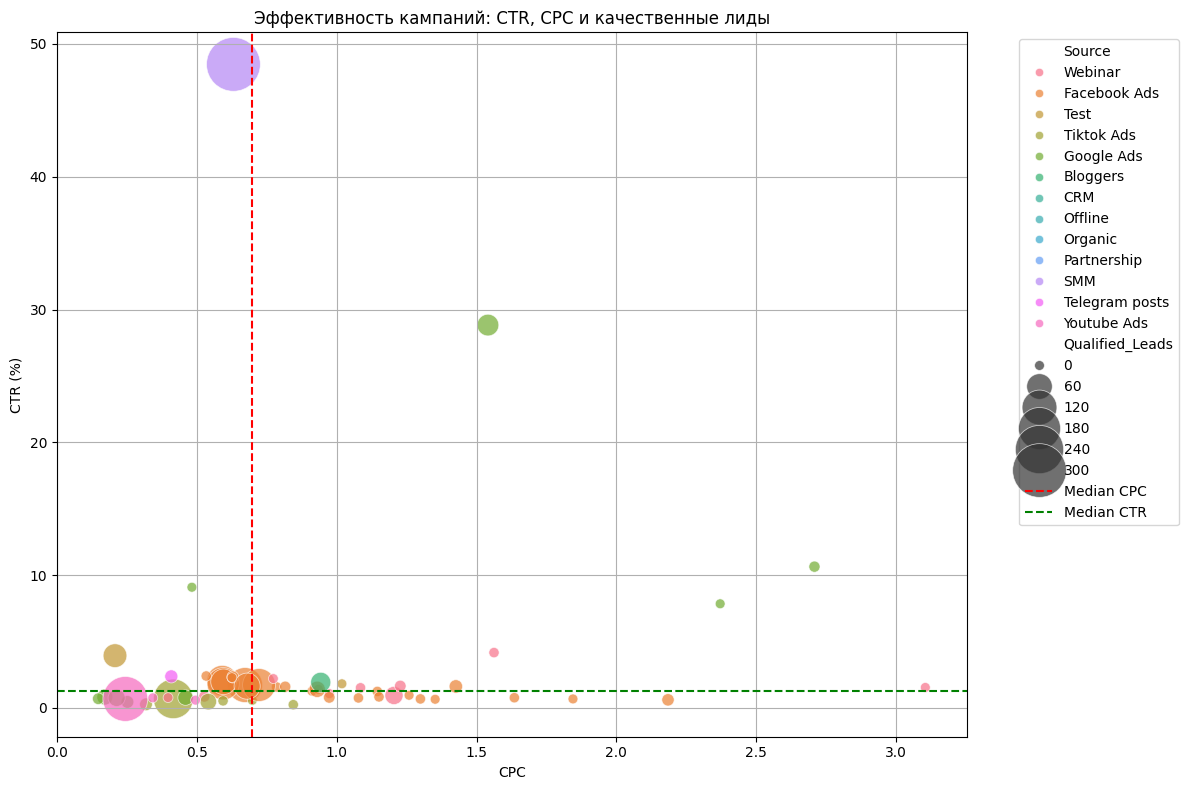

In [64]:
plt.figure(figsize=(12,8))
sns.scatterplot(
    data=campaign_perf,
    x='CPC',
    y='CTR_%',
    size='Qualified_Leads',     # ← QUALIFIZIERTE LEADS
    hue='Source',
    sizes=(50, 1500),
    alpha=0.7
)

plt.axvline(
    campaign_perf['CPC'].median(),
    linestyle='--',
    color='red',
    label='Median CPC'
)

plt.axhline(
    campaign_perf['CTR_%'].median(),
    linestyle='--',
    color='green',
    label='Median CTR'
)

plt.xlabel('CPC')
plt.ylabel('CTR (%)')
plt.title('Effektivität der Kampagnen: CTR, CPC und qualifizierte Leads')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# Statistische Referenzwerte

Aus dem Diagramm lassen sich folgende **Medianwerte** ableiten:

* **Medianer CPC ≈ 0,6–0,7 €**
* **Medianer CTR ≈ 1,2–1,4 %**

Das bedeutet:

* Die Hälfte der Kampagnen hat eine **CTR unter etwa 1,3 %**
* und kostet **mehr als etwa 0,7 € pro Klick**.

Diese Medianlinien teilen das Diagramm in **vier strategische Quadranten**.

---

# 🟢 Bester Quadrant: niedriger CPC + hoher CTR

*(oberer linker Bereich des Diagramms)*

### Beobachtung

Kampagnen aus **SMM** und **Telegram Posts** zeigen:

* **CTR ~45–50 %**
* **CPC unter dem Median**
* große Punkte im Diagramm → **viele qualifizierte Leads**

### Interpretation

Dies ist ein **statistischer Ausreißer im positiven Sinne**:

* CTR ist **30–40-mal höher als der Median**
* CPC liegt **unter dem Durchschnitt**
* der große Lead-Umfang zeigt, dass dies **kein Zufall** ist.

### Schlussfolgerung

Diese Kanäle bringen eine **sehr stark interessierte Zielgruppe**
und sollten als **Schlüsselkanäle für die Lead-Generierung** betrachtet werden.

**Empfehlung**

* Skalieren
* erfolgreiche Formate wiederholen
* Content-Strategie verstärken

---

# 🟡 Mittlerer, aber skalierbarer Bereich

*(um die Medianwerte herum, große Punkte)*

### Beobachtung

Kampagnen aus **Facebook Ads** und **Google Ads** zeigen:

* **CTR ~1–3 %**
* **CPC ~0,6–1,2 €**
* größte Kreise im Diagramm → **größter Lead-Strom**

### Interpretation

Diese Kanäle sind:

* stabil
* vorhersehbar
* die **Hauptquelle für Lead-Volumen**

### Schlussfolgerung

Sie liefern nicht die besten Einzelwerte,
aber sie **ermöglichen Skalierung**.

**Empfehlung**

* als **Basis der Marketingstrategie behalten**
* CPC weiter optimieren
* regelmäßig neue Creatives testen

---

# 🔴 Problemsegment: hoher CPC + niedriger CTR

*(unterer rechter Bereich)*

### Beobachtung

Einige Kampagnen aus **YouTube Ads** und **Webinar-Traffic** zeigen:

* **CPC > 2–3 €**
* **CTR < 1 %**
* kleine Punkte → **wenige qualifizierte Leads**

### Statistische Bewertung

* CTR unter dem Median
* CPC **3–4× höher als der Median**
* geringer Umfang → Effekt kann nicht durch Volumen kompensiert werden

### Schlussfolgerung

Diese Kampagnen zeigen ein **ineffizientes Verhältnis zwischen Kosten und Interesse**.

**Empfehlung**

* tiefgreifende Überarbeitung des Formats
  oder
* Kampagnen stoppen

---

# 🟠 Nischenkanäle mit Potenzial

### Beobachtung

Einige Kampagnen aus **TikTok Ads** oder **Bloggers** zeigen:

* **CTR ~8–11 %**
* CPC über dem Median
* kleinere Kreise → begrenztes Volumen

### Interpretation

Die Zielgruppe ist **stark interessiert**,
aber der **Reach ist begrenzt**.

### Schlussfolgerung

Dies sind **qualitative, aber skalierungsbegrenzte Kanäle**.

**Empfehlung**

* gezielt einsetzen
* für spezielle Programme oder Experimente nutzen

---

# 🧠 Zentrale Erkenntnisse

* **SMM und Telegram** sind statistisch die **effektivsten Kanäle**

  * extrem hoher CTR
  * niedriger CPC
  * viele qualifizierte Leads

* **Google Ads und Facebook Ads** sind die **Hauptquelle für Skalierung**

  * stabile Performance
  * größtes Lead-Volumen

* **YouTube Ads und Webinar-Traffic** stellen ein **Risikosegment** dar

  * hohe Kosten
  * niedrige Conversion

---

# Wichtigste analytische Erkenntnis

Es zeigt sich eine klare Beziehung:

> **Kanäle mit einem CTR über dem Median generieren in der Regel mehr qualifizierte Leads bei geringeren Kosten.**

In [65]:
# Tabelle

campaign_perf.sort_values(
    by=['Revenue', 'CTR_%'],
    ascending=False
)[['Campaign', 'Source', 'CTR_%', 'CPC', 'Revenue']].head(15)

,Campaign,Source,CTR_%,CPC,Revenue
44,No Campaign,Organic,NaN,0.000000,1000901.0
47,No Campaign,SMM,48.464580,0.630980,523900.0
64,youtube_shorts_DE,Youtube Ads,0.682380,0.244487,404000.0
3,02.07.23wide_DE,Facebook Ads,1.728515,0.672453,364000.0
17,12.07.2023wide_DE,Tiktok Ads,0.689459,0.416001,313400.0
5,03.07.23women,Facebook Ads,2.050971,0.591074,244400.0
9,07.07.23LAL_DE,Facebook Ads,1.731513,0.722574,243000.0
18,12.09.23interests_Uxui_DE,Facebook Ads,1.972403,0.595629,203500.0
6,04.07.23recentlymoved_DE,Facebook Ads,1.821349,0.594300,179100.0
37,24.09.23retargeting_DE,Facebook Ads,1.643526,0.680012,112400.0


Die gemeinsame Analyse von **CTR, CPC und Revenue** zeigt, dass eine **hohe Klickrate und niedrige Kosten pro Klick nicht immer einen hohen Umsatz garantieren**.

Die **effektivsten Kampagnen** befinden sich im Bereich mit **niedrigem CPC und hohem CTR** und generieren gleichzeitig ein **signifikantes Umsatzvolumen**.

Einige Kampagnen weisen zwar einen **guten CTR** auf, führen jedoch **nicht zu einem entsprechenden Umsatz**, was auf mögliche **Probleme in späteren Phasen des Conversion-Funnels** hinweist.

Daher sollten Kampagnen bei der **Optimierung des Marketingbudgets** nicht nur anhand von **Traffic-Kennzahlen**, sondern auch anhand ihres **tatsächlichen Beitrags zum Umsatz** bewertet werden.

**Block 4
Analyse von Zahlungen und Produkten**

1. Untersuchen Sie die **Verteilung der Zahlungsarten** und deren **Einfluss auf den Erfolg der Deals**.
2. Analysieren Sie die **Beliebtheit und Erfolgsquote verschiedener Produkte und Lernformate**.

### 4.1 Untersuchen Sie die Verteilung der Zahlungsarten und deren Einfluss auf den Erfolg der Deals.


In [ ]:
# Beliebtheit von Produkten und Lernformaten

In [66]:
# 1️⃣ Nur Deals mit Status "Payment Done" behalten
payment_done = deals[deals['Stage'] == 'Payment Done'].copy()

# 2️⃣ Duplikate nach Contact Name entfernen (damit jeder Kunde nur einmal gezählt wird)
unique_pd = payment_done.drop_duplicates(subset=['Contact Name'])

In [67]:
# Anzahl berechnen
payment_dist_pd = (
    unique_pd
    .groupby('Payment Type')
    .size()
    .reset_index(name='unique_purchases_cnt')
)

# Prozentanteil berechnen
payment_dist_pd['percent'] = (
    payment_dist_pd['unique_purchases_cnt']
    / payment_dist_pd['unique_purchases_cnt'].sum()
    * 100
).round(1)

print('Nur Payment Done')
print(payment_dist_pd)

Payment Done only
         Payment Type  unique_purchases_cnt  percent
0         One Payment                   103     30.6
1  Recurring Payments                   233     69.1
2         Reservation                     1      0.3


In [68]:
# 1️⃣ Alle Deals verwenden
all_deals = deals.copy()

# 2️⃣ Duplikate nach Contact Name entfernen (damit jeder Kunde nur einmal gezählt wird)
unique_all = all_deals.drop_duplicates(subset=['Contact Name'])

In [69]:
# Anzahl berechnen
payment_dist_all = (
    unique_all
    .groupby('Payment Type')
    .size()
    .reset_index(name='unique_purchases_cnt')
)

# Prozentanteil berechnen
payment_dist_all['percent'] = (
    payment_dist_all['unique_purchases_cnt']
    / payment_dist_all['unique_purchases_cnt'].sum()
    * 100
).round(1)

print('Alle Stages')
print(payment_dist_all)

All Stages
         Payment Type  unique_purchases_cnt  percent
0         One Payment                    51     28.8
1  Recurring Payments                   122     68.9
2         Reservation                     4      2.3


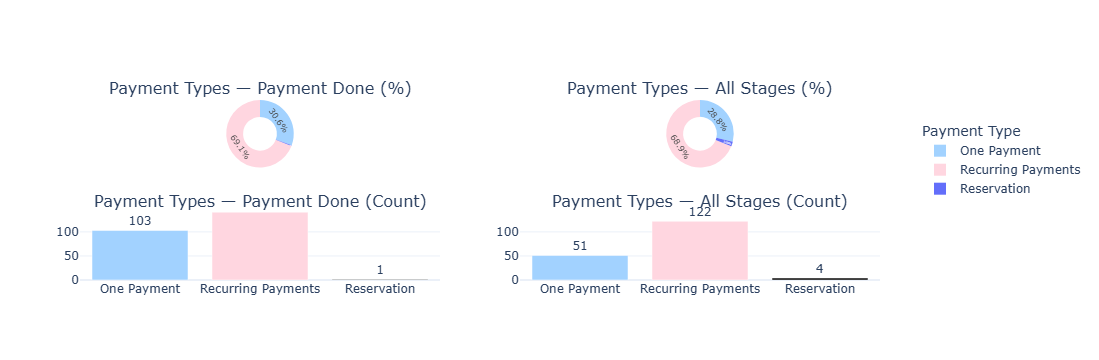

In [70]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

colors = ['#a2d2ff', '#ffd6e0']  # Einmalzahlung, Ratenzahlung

fig = make_subplots(
    rows=2, cols=2,
    specs=[[{'type': 'domain'}, {'type': 'domain'}],
           [{'type': 'xy'}, {'type': 'xy'}]],
    subplot_titles=[
        'Zahlungsarten — Payment Done (%)',
        'Zahlungsarten — Alle Stages (%)',
        'Zahlungsarten — Payment Done (Anzahl)',
        'Zahlungsarten — Alle Stages (Anzahl)'
    ]
)

# ---------- PIE: Payment Done ----------
fig.add_trace(
    go.Pie(
        labels=payment_dist_pd['Payment Type'],
        values=payment_dist_pd['unique_purchases_cnt'],
        marker=dict(colors=colors),
        hole=0.5,
        textinfo='percent',
        textposition='inside',
        textfont=dict(size=12),
        sort=False,
        showlegend=True
    ),
    row=1, col=1
)

# ---------- PIE: Alle Stages ----------
fig.add_trace(
    go.Pie(
        labels=payment_dist_all['Payment Type'],
        values=payment_dist_all['unique_purchases_cnt'],
        marker=dict(colors=colors),
        hole=0.5,
        textinfo='percent',
        textposition='inside',
        textfont=dict(size=12),
        sort=False,
        showlegend=False
    ),
    row=1, col=2
)

# ---------- BAR: Payment Done ----------
fig.add_trace(
    go.Bar(
        x=payment_dist_pd['Payment Type'],
        y=payment_dist_pd['unique_purchases_cnt'],
        marker=dict(color=colors),
        text=payment_dist_pd['unique_purchases_cnt'],
        textposition='outside',
        cliponaxis=False,
        textfont=dict(size=12),
        showlegend=False
    ),
    row=2, col=1
)

# ---------- BAR: Alle Stages ----------
fig.add_trace(
    go.Bar(
        x=payment_dist_all['Payment Type'],
        y=payment_dist_all['unique_purchases_cnt'],
        marker=dict(color=colors),
        text=payment_dist_all['unique_purchases_cnt'],
        textposition='outside',
        cliponaxis=False,
        textfont=dict(size=12),
        showlegend=False
    ),
    row=2, col=2
)

# ---------- Oberen Y-Achsen-Abstand vergrößern ----------
fig.update_yaxes(
    range=[0, max(payment_dist_all['unique_purchases_cnt']) * 1.15],
    row=2, col=1
)

fig.update_yaxes(
    range=[0, max(payment_dist_all['unique_purchases_cnt']) * 1.15],
    row=2, col=2
)

# ---------- Layout ----------
fig.update_layout(
    height=820,
    template='plotly_white',
    legend_title_text='Zahlungsart',
    legend=dict(
        orientation='v',
        x=1.05,
        y=0.9
    ),
    font=dict(size=12)
)

fig.show()

**One Payment** schneidet beim Abschluss besser ab — **fast jeder zweite Deal führt zur Zahlung**.
**Recurring Payments** liefern jedoch den **Hauptanteil der Zahlungen**, weil es **deutlich mehr solcher Deals** gibt.

Für das Umsatzwachstum sind daher **beide Ansätze wichtig**:
— **One Payment** als **„schnelle Erfolge“**
— **Recurring Payments** als **Hauptquelle für Skalierung**

In [71]:
# 1️ Beginnen wir mit eindeutigen Käufen pro Kunde und Produkt
unique_client_product = deals.drop_duplicates(subset=['Contact Name', 'Product'])

# 2️ Anzahl der eindeutigen Kunden nach Produkt und Zahlungsart berechnen
product_payment_dist = unique_client_product.pivot_table(
    index='Product',
    columns='Payment Type',
    values='Contact Name',
    aggfunc='count',  # Anzahl der eindeutigen Kunden zählen
    fill_value=0      # Wenn keine Daten vorhanden sind, 0 einsetzen
)

# 3️ Für Prozentwerte (für Beschriftungen im Diagramm)
product_payment_pct = product_payment_dist.div(product_payment_dist.sum(axis=1), axis=0) * 100

In [72]:
# 1️ Eindeutige Käufe nach Kunde und Produkt
unique_client_product = deals.drop_duplicates(subset=['Contact Name', 'Product'])

# 2️ Nur die gewünschten Produkte auswählen
selected_products = ['Digital Marketing', 'UX/UI Design', 'Web Developer']
unique_client_product = unique_client_product[unique_client_product['Product'].isin(selected_products)]

# 3️ Anzahl der eindeutigen Kunden nach Produkt und Zahlungsart berechnen
product_payment_dist = unique_client_product.pivot_table(
    index='Product',
    columns='Payment Type',
    values='Contact Name',
    aggfunc='count',  # Anzahl der eindeutigen Kunden zählen
    fill_value=0      # Wenn keine Daten vorhanden sind, 0 einsetzen
)

# 4️ Für Prozentwerte (für Beschriftungen im Diagramm)
product_payment_pct = product_payment_dist.div(product_payment_dist.sum(axis=1), axis=0) * 100

# Überprüfung
print(product_payment_dist)
print(product_payment_pct)

Payment Type       One Payment  Recurring Payments  Reservation
Product                                                        
Digital Marketing           55                 187            1
UX/UI Design                37                  83            0
Web Developer               30                  31            3
Payment Type       One Payment  Recurring Payments  Reservation
Product                                                        
Digital Marketing    22.633745           76.954733     0.411523
UX/UI Design         30.833333           69.166667     0.000000
Web Developer        46.875000           48.437500     4.687500


In [ ]:
# Erfolgsrate der Zahlungsarten

# Logik zur Bestimmung der Erfolgsrate einer Zahlungsart:
# Die Erfolgsrate einer Zahlungsart wird als Anteil der eindeutigen Deals
# (Contact Name + Product) berechnet, die mit dem Status "Payment Done"
# abgeschlossen wurden, im Verhältnis zur Gesamtzahl der Deals dieser Zahlungsart.

# 1. Ein Deal = eindeutige Kombination aus "Contact Name + Product".

# 2. Wenn mindestens eine Zeile für diese Kombination den Status
# "Payment Done" enthält, gilt der gesamte Deal als erfolgreich abgeschlossen.

# 3. Für jeden Deal (Contact Name + Product) wird nur einmal gezählt,
# wobei der Payment Type aus der ersten Zeile verwendet wird,
# in der "Payment Done" vorkommt.

# 4. Erfolgsrate (Success Rate) = Anzahl der Deals mit "Payment Done"
#    / Gesamtzahl der Deals dieser Zahlungsart.

         Payment_Type  deals_count  won_deals  success_rate
0         One Payment          133        109     81.954887
1  Recurring Payments          335        251     74.925373
2         Reservation            5          1     20.000000


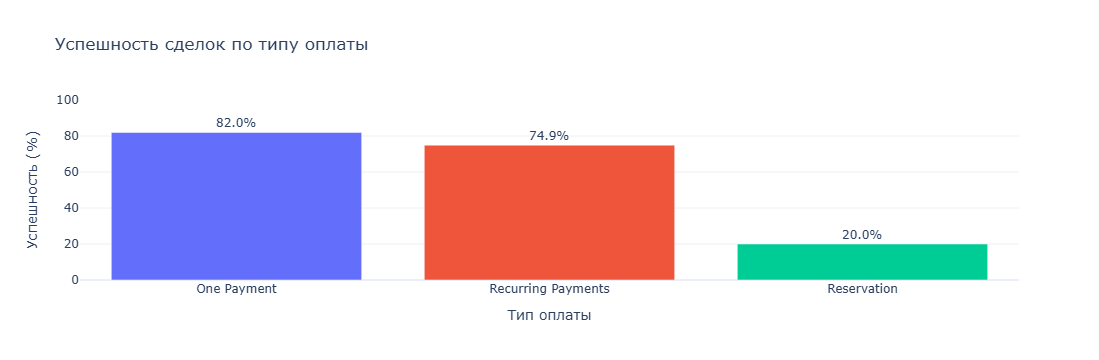

In [73]:
import plotly.express as px

# =========================
# Analyse der Deals
# =========================

deals_analysis = deals[['Contact Name', 'Product', 'Payment Type', 'Stage']].copy()

# Gewinnter Deal = Payment Done
deals_analysis['is_win'] = (deals_analysis['Stage'] == 'Payment Done').astype(int)

# =========================
# Aggregation auf Ebene Contact + Product
# =========================
agg_deals = (
    deals_analysis
    .groupby(['Contact Name', 'Product'], as_index=False)
    .agg(
        Payment_Type=('Payment Type', 'first'),
        is_win=('is_win', 'max')
    )
)

# =========================
# Erfolgsrate nach Zahlungsart
# =========================
payment_success = (
    agg_deals
    .groupby('Payment_Type', as_index=False)
    .agg(
        deals_count=('Contact Name', 'count'),
        won_deals=('is_win', 'sum'),
        success_rate=('is_win', 'mean')
    )
)

payment_success['success_rate'] = payment_success['success_rate'] * 100
print(payment_success)

# =========================
# Visualisierung:
# Erfolgsrate nach Zahlungsart
# =========================
fig = px.bar(
    payment_success,
    x='Payment_Type',
    y='success_rate',
    text=payment_success['success_rate'].round(1).astype(str) + '%',
    color='Payment_Type',
    title='Erfolgsrate der Deals nach Zahlungsart'
)

fig.update_layout(
    xaxis_title='Zahlungsart',
    yaxis_title='Erfolgsrate (%)',
    yaxis_range=[0, 100],
    showlegend=False,
    template='plotly_white'
)

fig.update_traces(textposition='outside')
fig.show()

         Payment_Type  deals_count  won_deals  success_rate
0         One Payment          133        109     81.954887
1  Recurring Payments          335        251     74.925373


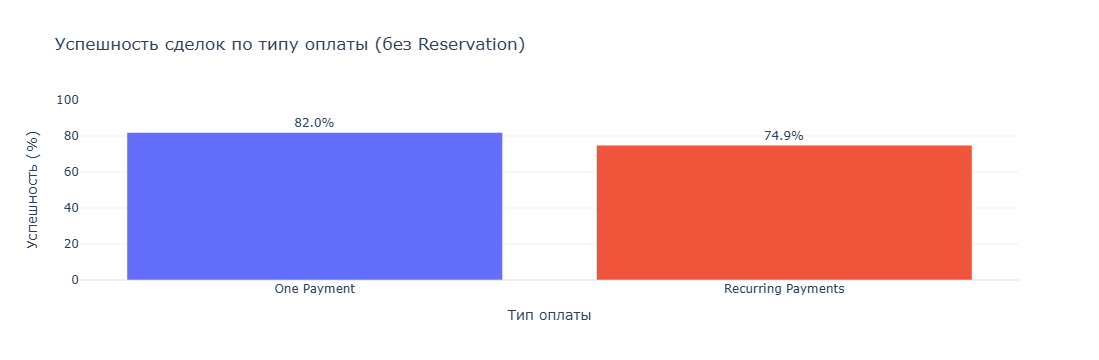

In [74]:
# =========================
# "Reservation" VOR der Aggregation herausfiltern
# =========================

agg_deals_no_reservation = agg_deals[
    agg_deals['Payment_Type'] != 'Reservation'
].copy()

# =========================
# Erfolgsrate nach Zahlungsart
# =========================

payment_success_no_res = (
    agg_deals_no_reservation
    .groupby('Payment_Type', as_index=False)
    .agg(
        deals_count=('Contact Name', 'count'),
        won_deals=('is_win', 'sum'),
        success_rate=('is_win', 'mean')
    )
)

payment_success_no_res['success_rate'] *= 100
print(payment_success_no_res)

# =========================
# Visualisierung (NUR 2 ZAHLUNGSARTEN)
# =========================

fig = px.bar(
    payment_success_no_res,
    x='Payment_Type',
    y='success_rate',
    text=payment_success_no_res['success_rate'].round(1).astype(str) + '%',
    color='Payment_Type',
    title='Erfolgsrate der Deals nach Zahlungsart (ohne Reservation)'
)

fig.update_layout(
    xaxis_title='Zahlungsart',
    yaxis_title='Erfolgsrate (%)',
    yaxis_range=[0, 100],
    showlegend=False,
    template='plotly_white'
)

fig.update_traces(textposition='outside')
fig.show()

Die Analyse konzentrierte sich ausschließlich auf den Zusammenhang zwischen der Zahlungsart und der tatsächlichen Zahlung, ohne zusätzliche Faktoren zu berücksichtigen. Dadurch wird lediglich die grundlegende Korrelation zwischen diesen Variablen bewertet.

One Payment schließt erfolgreicher ab – fast jede zweite solche Transaktion führt tatsächlich zu einer Zahlung.
Recurring Payments generieren jedoch den Großteil der Zahlungen, da die Anzahl dieser Deals deutlich höher ist.
Für das Umsatzwachstum sind daher beide Ansätze wichtig:
— One Payment als „Quick Wins“,
— Recurring Payments als wichtigste Quelle für Skalierung.

Zahlungsart	Erfolgsrate	Anteil an allen Deals	Beitrag zu Payment Done
One Payment	🔥 hoch	❄️ niedrig	moderat
Recurring	⚠️ niedriger	🔥 hoch	🔥 Hauptanteil

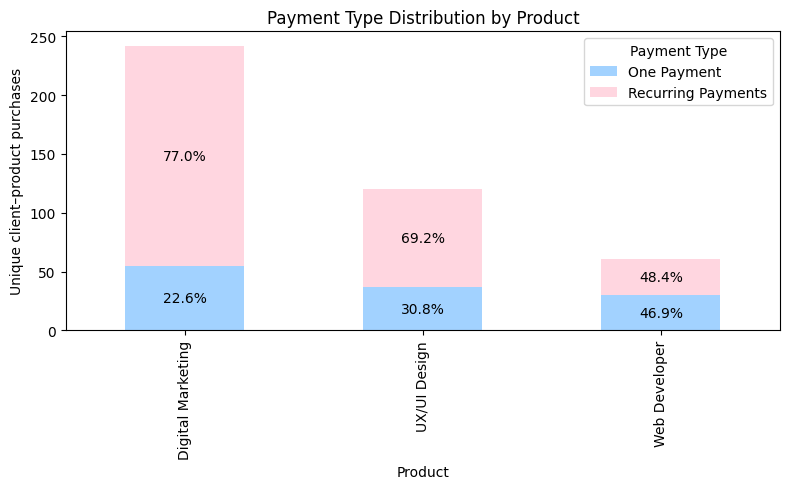

In [75]:
# Zur Referenz
# Verteilung nach Produkten
# --- "Reservation" NUR für die Visualisierung ausschließen ---
cols_to_plot = [c for c in product_payment_dist.columns if c != 'Reservation']

# --- Farben: passend zu den tatsächlichen Spaltennamen ---
colors = {
    'One Payment': '#a2d2ff',
    'Recurring Payments': '#ffd6e0'   # <-- wie in deiner Tabelle
}

default_color = '#cfcfcf'  # Falls ein neuer Typ auftaucht

ax = product_payment_dist[cols_to_plot].plot(
    kind='bar',
    stacked=True,
    figsize=(8, 5),
    color=[colors.get(c, default_color) for c in cols_to_plot]
)

plt.title('Verteilung der Zahlungsarten nach Produkt')
plt.xlabel('Produkt')
plt.ylabel('Eindeutige Kunden-Produkt-Käufe')
plt.legend(title='Zahlungsart')
plt.tight_layout()

# --- Prozentangaben auf den Balken ---
for i, product in enumerate(product_payment_dist.index):
    cumulative_height = 0
    for payment_type in cols_to_plot:
        value = product_payment_dist.loc[product, payment_type]
        if value > 0:
            pct = product_payment_pct.loc[product, payment_type]
            ax.text(
                i,
                cumulative_height + value / 2,
                f'{pct:.1f}%',
                ha='center',
                va='center',
                color='black',
                fontsize=10
            )
            cumulative_height += value

plt.show()

### 4.2. Проанализируйте популярность и успешность различных продуктов и типов обучения.

In [ ]:
Erfolgreicher Deal = Payment Done
Conversion Rate berechnen = Payment Done / alle anderen Stages für One Payment und Recurring Payments

Stage              Lost  Call Delayed  Need a consultation  Payment Done  \
Product                                                                    
Digital Marketing  1021           226                    1           455   
UX/UI Design        552            91                    0           221   
Web Developer       271            65                    0           137   

Stage              Qualificated  Registered on Webinar  Test Sent  \
Product                                                             
Digital Marketing            10                      2          2   
UX/UI Design                  8                      1          5   
Web Developer                 7                      0          1   

Stage              Waiting For Payment  Free Education  New Lead  \
Product                                                            
Digital Marketing                  148               0         0   
UX/UI Design                        92               1         0   
W

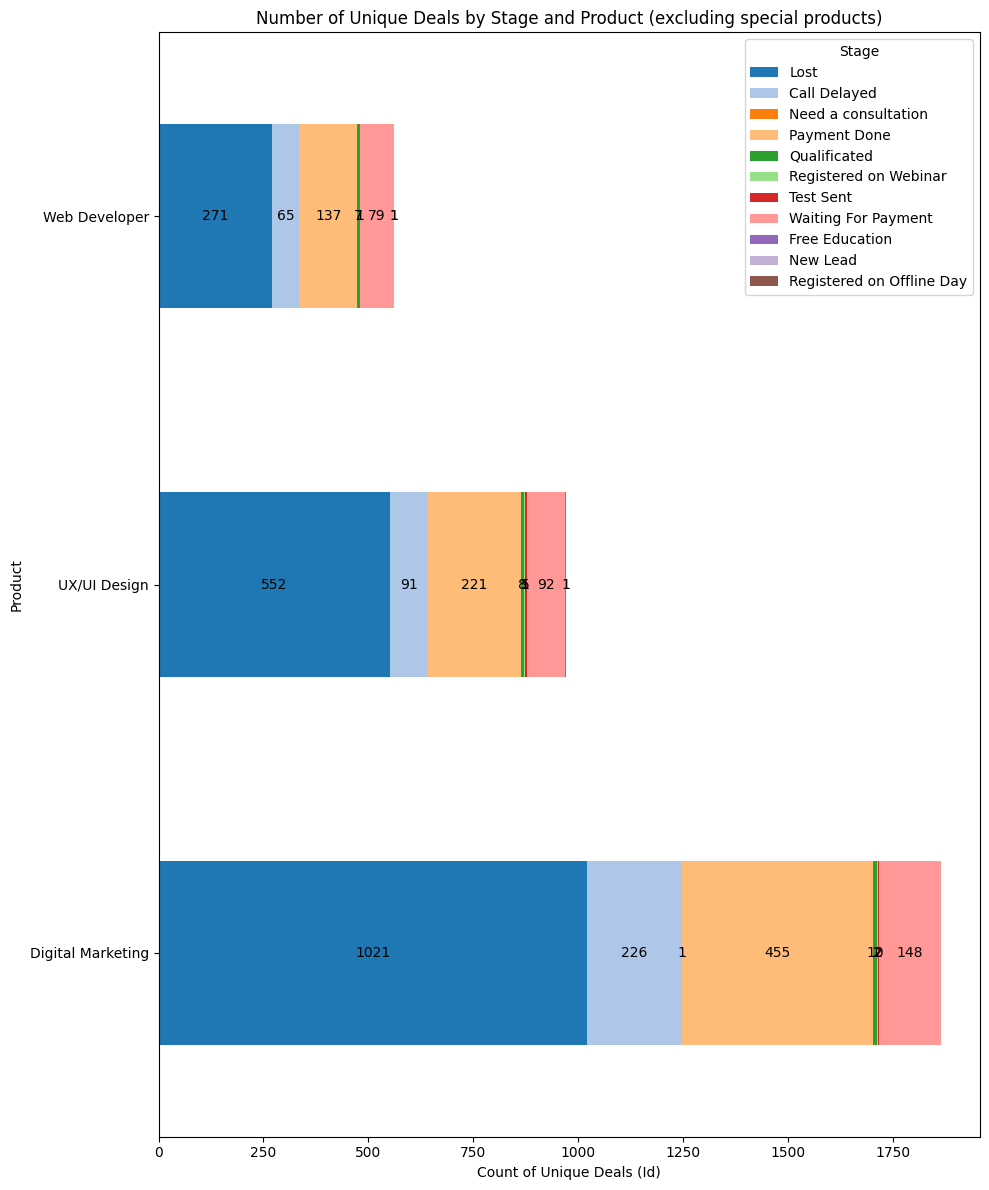

In [76]:
deals_copy = deals.copy()

# 1. Produktnamen bereinigen
deals_copy['Product'] = deals_copy['Product'].str.strip()  # Leerzeichen am Anfang/Ende entfernen
# Optional: Normalisierung der Groß-/Kleinschreibung
# deals_copy['Product'] = deals_copy['Product'].str.title()

# 2️ Anzahl eindeutiger Ids pro Stage und Produkt zählen
stage_counts = deals_copy.groupby(['Product', 'Stage'])['Id'].nunique().unstack(fill_value=0)

# Spezialprodukte entfernen
special_products = ['Data Analytics', 'Find yourself in IT']
stage_counts = stage_counts[~stage_counts.index.isin(special_products)]

print(stage_counts)

# 3️ Einzigartige Farben für jede Stage generieren
stages = stage_counts.columns.tolist()
palette = sns.color_palette("tab20", n_colors=len(stages))
colors = {stage: palette[i] for i, stage in enumerate(stages)}

# 4️ Horizontales gestapeltes Balkendiagramm
ax = stage_counts.plot(
    kind='barh',
    stacked=True,
    figsize=(10,12),
    color=[colors[col] for col in stage_counts.columns]
)

plt.title('Anzahl eindeutiger Deals nach Stage und Produkt (ohne Spezialprodukte)')
plt.xlabel('Anzahl eindeutiger Deals (Id)')
plt.ylabel('Produkt')

# 5️ Zahlen als Beschriftungen auf den Balken hinzufügen
for i, product in enumerate(stage_counts.index):
    cumulative_width = 0
    for stage in stage_counts.columns:
        value = stage_counts.loc[product, stage]
        if value > 0:
            ax.text(
                cumulative_width + value / 2,
                i,
                str(value),
                ha='center',
                va='center',
                color='black',
            )
            cumulative_width += value

plt.tight_layout()
plt.show()

Stage                Lost  Call Delayed  Need a consultation  Payment Done  \
Product                                                                      
Data Analytics          1             0                    0             0   
Find yourself in IT     3             0                    0             1   

Stage                Qualificated  Registered on Webinar  Test Sent  \
Product                                                               
Data Analytics                  0                      0          0   
Find yourself in IT             0                      0          0   

Stage                Waiting For Payment  Free Education  New Lead  \
Product                                                              
Data Analytics                         0               0         0   
Find yourself in IT                    0               0         0   

Stage                Registered on Offline Day  
Product                                         
Data Analytics         

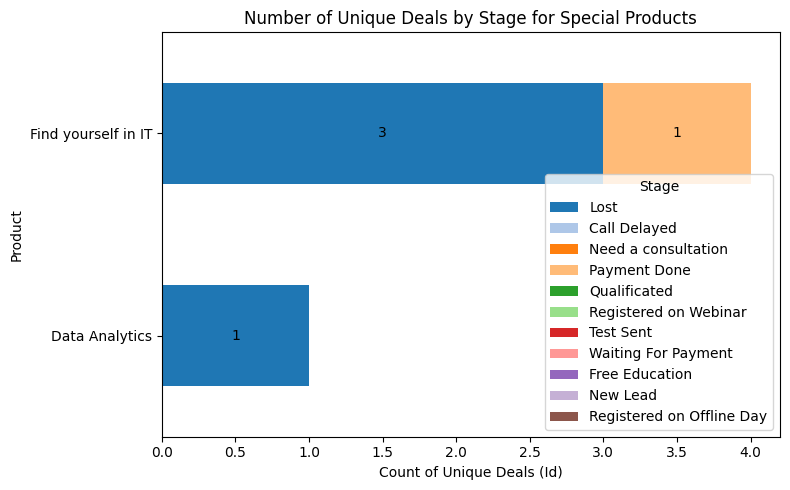

In [77]:
deals_copy = deals.copy()

# 1. Produktnamen bereinigen
deals_copy['Product'] = deals_copy['Product'].str.strip()  # Leerzeichen am Anfang/Ende entfernen

# 2️ Anzahl eindeutiger Ids pro Stage und Produkt zählen
stage_counts = deals_copy.groupby(['Product', 'Stage'])['Id'].nunique().unstack(fill_value=0)

# 2.1 Nur Spezialprodukte auswählen
special_products = ['Data Analytics', 'Find yourself in IT']
special_stage_counts = stage_counts.loc[stage_counts.index.isin(special_products)]

print(special_stage_counts)

# 3️ Einzigartige Farben für jede Stage generieren
stages = special_stage_counts.columns.tolist()
palette = sns.color_palette("tab20", n_colors=len(stages))
colors = {stage: palette[i] for i, stage in enumerate(stages)}

# 4️ Horizontales gestapeltes Balkendiagramm
ax = special_stage_counts.plot(
    kind='barh',
    stacked=True,
    figsize=(8,5),
    color=[colors[col] for col in special_stage_counts.columns]
)

plt.title('Anzahl eindeutiger Deals nach Stage für Spezialprodukte')
plt.xlabel('Anzahl eindeutiger Deals (Id)')
plt.ylabel('Produkt')

# 5️ Zahlen als Beschriftungen auf den Balken hinzufügen
for i, product in enumerate(special_stage_counts.index):
    cumulative_width = 0
    for stage in special_stage_counts.columns:
        value = special_stage_counts.loc[product, stage]
        if value > 0:
            ax.text(
                cumulative_width + value / 2,
                i,
                str(value),
                ha='center',
                va='center',
                color='black',
            )
            cumulative_width += value

# 6️ Legende rechts unten
ax.legend(
    title='Stage',
    loc='lower right',             # Position der Legende
    bbox_to_anchor=(1, 0)          # rechts unten
)

plt.tight_layout()
plt.show()

1.Alle Deals

Tabelle nach Produkt

Zwei Diagramme: Anzahl (Count) und Prozent (%)

2.Nur Payment Done

Tabelle

Zwei Diagramme: Anzahl (Count) und Prozent (%)

3.Aufteilung nach Education Type (Morning / Evening)

Für alle Deals

Für Payment Done

In Zahlen und Prozent (%)

1. Alle Deals — Beliebtheit der Produkte / Lernformen

In [78]:
# Tabelle (Anzahl + %)
# Eindeutige Kunden × Produkt (alle Deals)
unique_all_products = (
    deals
    .drop_duplicates(subset=['Contact Name', 'Product'])
)

product_dist_all = (
    unique_all_products
    .groupby('Product')
    .size()
    .reset_index(name='unique_purchases_cnt')
)

product_dist_all['percent'] = (
    product_dist_all['unique_purchases_cnt']
    / product_dist_all['unique_purchases_cnt'].sum()
    * 100
).round(1)

print('ALLE STAGES — Produkte')
print(product_dist_all)

ALL STAGES — Products
               Product  unique_purchases_cnt  percent
0       Data Analytics                     1      0.0
1    Digital Marketing                  1712     53.4
2  Find yourself in IT                     3      0.1
3         UX/UI Design                   948     29.6
4        Web Developer                   539     16.8


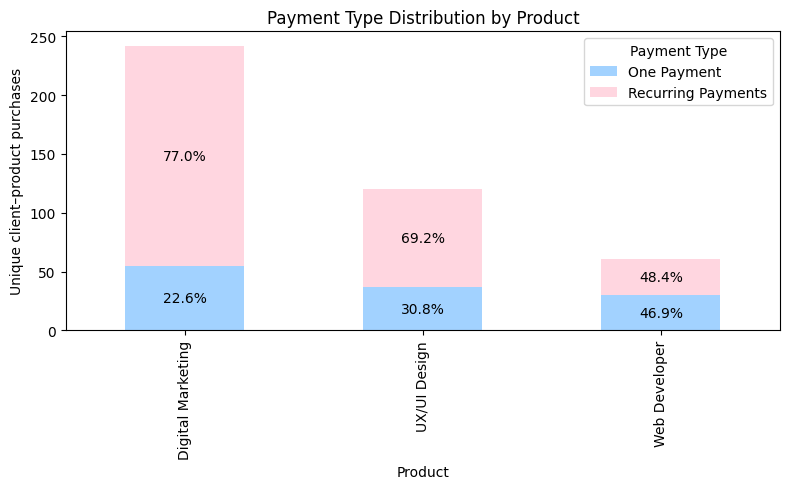

In [79]:
# Spalten: eindeutige Kunden × Produkt × Education Type
import matplotlib.pyplot as plt

# --- Kopie NUR für die Visualisierung ---
plot_dist = product_payment_dist.copy()
plot_pct = product_payment_pct.copy()

# --- "Reservation" ausschließen ---
cols_to_plot = [c for c in plot_dist.columns if c != 'Reservation']

# --- Mikrosektor für Web Developer entfernen ---
# wenn der Wert == 1, wird er einfach nicht gezeichnet
if 'Web Developer' in plot_dist.index:
    plot_dist.loc['Web Developer'] = plot_dist.loc['Web Developer'].where(
        plot_dist.loc['Web Developer'] > 1, 0
    )
    plot_pct.loc['Web Developer'] = plot_pct.loc['Web Developer'].where(
        plot_pct.loc['Web Developer'] > 0, 0
    )

# --- Farben ---
colors = {
    'One Payment': '#a2d2ff',
    'Recurring Payments': '#ffd6e0'
}

default_color = '#cfcfcf'

ax = plot_dist[cols_to_plot].plot(
    kind='bar',
    stacked=True,
    figsize=(8, 5),
    color=[colors.get(c, default_color) for c in cols_to_plot]
)

plt.title('Verteilung der Zahlungsarten nach Produkt')
plt.xlabel('Produkt')
plt.ylabel('Eindeutige Kunden-Produkt-Käufe')
plt.legend(title='Zahlungsart')
plt.tight_layout()

# --- Prozentangaben auf den Balken ---
for i, product in enumerate(plot_dist.index):
    cumulative_height = 0
    for payment_type in cols_to_plot:
        value = plot_dist.loc[product, payment_type]
        if value > 0:
            pct = plot_pct.loc[product, payment_type]
            ax.text(
                i,
                cumulative_height + value / 2,
                f'{pct:.1f}%',
                ha='center',
                va='center',
                color='black',
                fontsize=10
            )
            cumulative_height += value

plt.show()

In [ ]:
2 PAYMENT DONE — Erfolgsrate der Produkte / Lernformen

In [80]:
unique_pd_products = deals[deals['Stage'].isin(['Payment Done'])].drop_duplicates(subset=['Contact Name', 'Product'])


product_dist_pd = (
    unique_pd_products
    .groupby('Product')
    .size()
    .reset_index(name='unique_purchases_cnt')
)

product_dist_pd['percent'] = (
    product_dist_pd['unique_purchases_cnt']
    / product_dist_pd['unique_purchases_cnt'].sum()
    * 100
).round(1)

print('PAYMENT DONE')
print(product_dist_pd)

PAYMENT DONE
               Product  unique_purchases_cnt  percent
0    Digital Marketing                   459     56.5
1  Find yourself in IT                     1      0.1
2         UX/UI Design                   220     27.1
3        Web Developer                   133     16.4


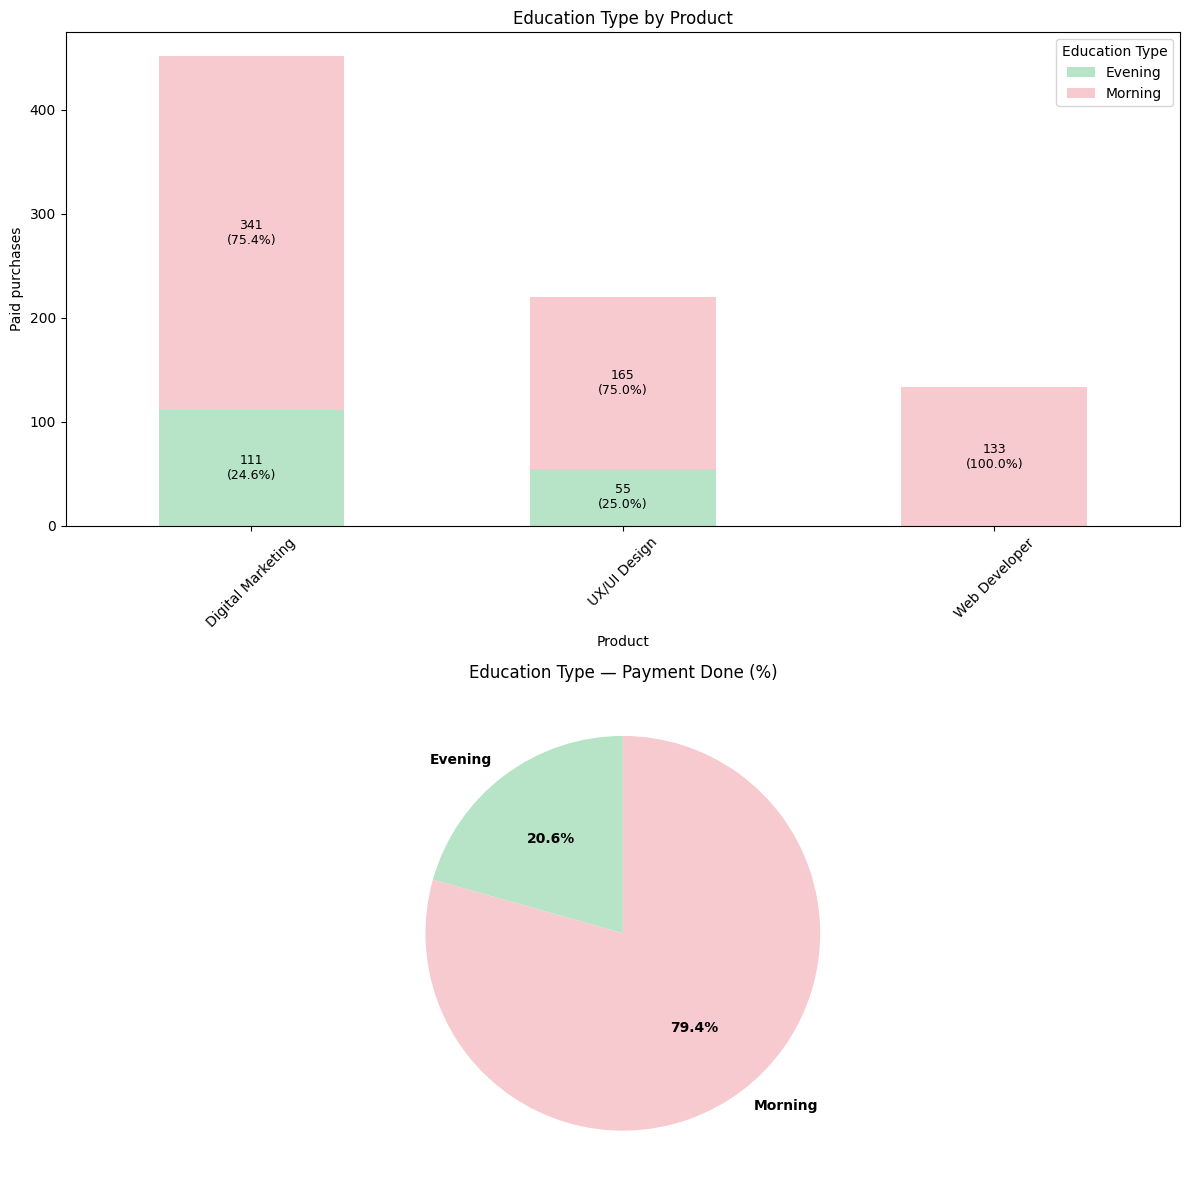

In [81]:
import matplotlib.pyplot as plt

# 1️ Eindeutige Kunden × Produkt × Education Type für Payment Done
unique_pd_products = deals[deals['Stage'].isin(['Payment Done'])].drop_duplicates(subset=['Contact Name', 'Product'])

edu_dist_pd = (
    unique_pd_products
    .groupby(['Product', 'Education Type'])
    .size()
    .unstack(fill_value=0)
)

# Farben: Morning / Evening
colors = ['#b7e4c7', '#f7cad0'] # Morning grün, Evening rosa

fig, axes = plt.subplots(2, 1, figsize=(12, 12))

# ---------- Balkendiagramm: Count (gestapelt) ----------
edu_dist_pd.plot(
    kind='bar',
    stacked=True,
    ax=axes[0],
    color=colors
)
axes[0].set_title('Education Type nach Produkt')
axes[0].set_ylabel('Bezahlte Käufe')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Education Type')

# Zahlen- und Prozentbeschriftungen hinzufügen
for i, product in enumerate(edu_dist_pd.index):
    bottom = 0
    total = edu_dist_pd.loc[product].sum()
    for edu_type in edu_dist_pd.columns:
        value = edu_dist_pd.loc[product, edu_type]
        pct = value / total * 100 if total > 0 else 0
        if value > 0:  # Beschriftung nur, wenn Wert > 0
            axes[0].text(
                i,
                bottom + value / 2,
                f'{value}\n({pct:.1f}%)',
                ha='center',
                va='center',
                fontsize=9,
                color='black'
            )
        bottom += value

# ---------- Kreisdiagramm: Prozentanteil Morning/Evening ----------
edu_total_pct_pd = edu_dist_pd.sum()
edu_total_pct_pd = edu_total_pct_pd / edu_total_pct_pd.sum() * 100

axes[1].pie(
    edu_total_pct_pd,
    labels=edu_total_pct_pd.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={'weight':'bold'}
)
axes[1].set_title('Education Type — Payment Done (%)')

plt.tight_layout()
plt.show()

Wir betrachten, wie die Werbekosten proportional zu den Einnahmen jeder einzelnen Transaktion verteilt werden.
Dies ist notwendig, da mehrere Deals derselben Kampagne zugeordnet sein können.

In [82]:
# Erfolgsrate nach Bildungsform
# =========================
# Analyse der Deals
# =========================
deals_analysis = deals[
    ['Contact Name', 'Product', 'Education Type', 'Stage']
].copy()

# Gewinnter Deal = Payment Done
deals_analysis['is_win'] = (
    deals_analysis['Stage'] == 'Payment Done'
).astype(int)

# =========================
# Aggregation auf Ebene Contact + Product
# =========================
agg_deals = (
    deals_analysis
    .groupby(['Contact Name', 'Product'], as_index=False)
    .agg(
        Education_Type=('Education Type', 'first'),
        is_win=('is_win', 'max')
    )
)

# =========================
# Erfolgsrate nach Bildungsform
# =========================
education_success = (
    agg_deals
    .groupby('Education_Type', as_index=False)
    .agg(
        deals_count=('Contact Name', 'count'),
        won_deals=('is_win', 'sum'),
        success_rate=('is_win', 'mean')
    )
)

education_success['success_rate'] *= 100

print(education_success)

  Education_Type  deals_count  won_deals  success_rate
0        Evening          367        159     43.324251
1        Morning         2597        646     24.874856


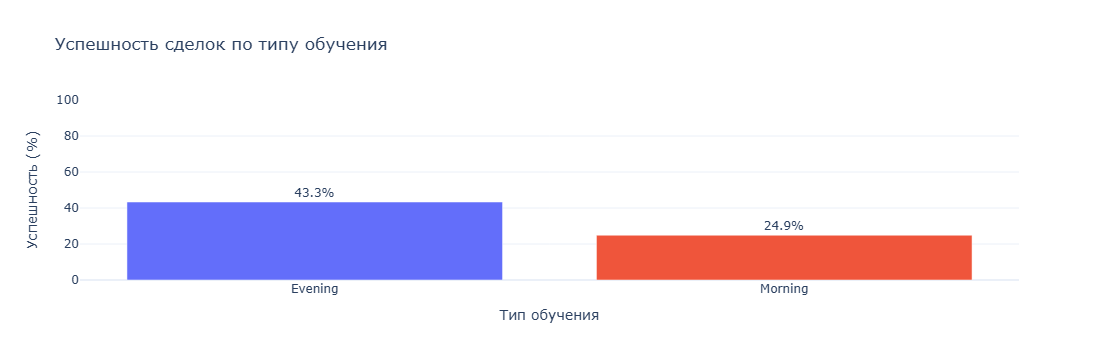

In [83]:
fig = px.bar(
    education_success,
    x='Education_Type',
    y='success_rate',
    text=education_success['success_rate'].round(1).astype(str) + '%',
    color='Education_Type',
    title='Erfolgsrate der Deals nach Bildungsform'
)

fig.update_layout(
    xaxis_title='Bildungsform',
    yaxis_title='Erfolgsrate (%)',
    yaxis_range=[0, 100],
    showlegend=False,
    template='plotly_white'
)

fig.update_traces(textposition='outside')
fig.show()

In [84]:
# Kombi-Diagramm nach Bildungsform und Zahlungsart

# =========================
# Datenvorbereitung
# =========================
deals_analysis = deals[
    ['Contact Name', 'Product', 'Payment Type', 'Education Type', 'Stage', 'Offer Total Amount']
].copy()

# Gewinnter Deal = Payment Done
deals_analysis['is_win'] = (deals_analysis['Stage'] == 'Payment Done').astype(int)

# Eindeutiger Kauf = Contact + Product
agg_deals = (
    deals_analysis
    .groupby(['Contact Name', 'Product'], as_index=False)
    .agg(
        Payment_Type=('Payment Type', 'first'),
        Education_Type=('Education Type', 'first'),
        is_win=('is_win', 'max'),
        Revenue=('Offer Total Amount', 'sum')  
    )
)

In [85]:
success_2x2 = (
    agg_deals
    .loc[agg_deals['Payment_Type'] != 'Reservation']   # ← WICHTIGER FILTER
    .groupby(['Education_Type', 'Payment_Type'], as_index=False)
    .agg(
        deals_count=('Contact Name', 'count'),
        won_deals=('is_win', 'sum'),
        success_rate=('is_win', 'mean')
    )
)

success_2x2['success_rate'] *= 100
print(success_2x2)

  Education_Type        Payment_Type  deals_count  won_deals  success_rate
0        Evening         One Payment           52         42     80.769231
1        Evening  Recurring Payments          143        114     79.720280
2        Morning         One Payment           78         66     84.615385
3        Morning  Recurring Payments          186        136     73.118280


In [ ]:
# ← WICHTIGER FILTER
Wir schließen alle Deals mit Payment_Type = „Reservation“ aus, da diese nicht in die Erfolgsratenanalyse einbezogen werden sollen.

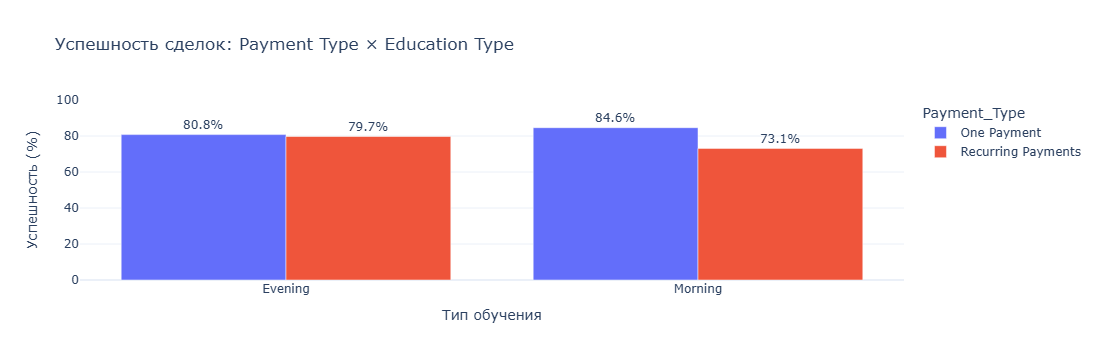

In [86]:
fig = px.bar(
    success_2x2,
    x='Education_Type',
    y='success_rate',
    color='Payment_Type',
    barmode='group',
    text=success_2x2['success_rate'].round(1).astype(str) + '%',
    title='Erfolgsrate der Deals: Zahlungsart × Bildungsform'
)

fig.update_layout(
    xaxis_title='Bildungsform',
    yaxis_title='Erfolgsrate (%)',
    yaxis_range=[0, 100],
    template='plotly_white'
)

fig.update_traces(textposition='outside')
fig.show()

Сичтаем Revenue per deal по типу обучения:
только успешные сделки = Payment Done
средний доход на 1 сделку
сравнение Morning vs Evening

In [87]:
revenue_per_deal = (
    agg_deals[agg_deals['is_win'] == 1]
    .groupby('Education_Type', as_index=False)
    .agg(
        deals_count=('Contact Name', 'count'),
        total_revenue=('Revenue', 'sum'),
        revenue_per_deal=('Revenue', 'mean')
    )
)

print(revenue_per_deal)

  Education_Type  deals_count  total_revenue  revenue_per_deal
0        Evening          159       846800.0       5325.786164
1        Morning          646      6704500.0      10378.482972


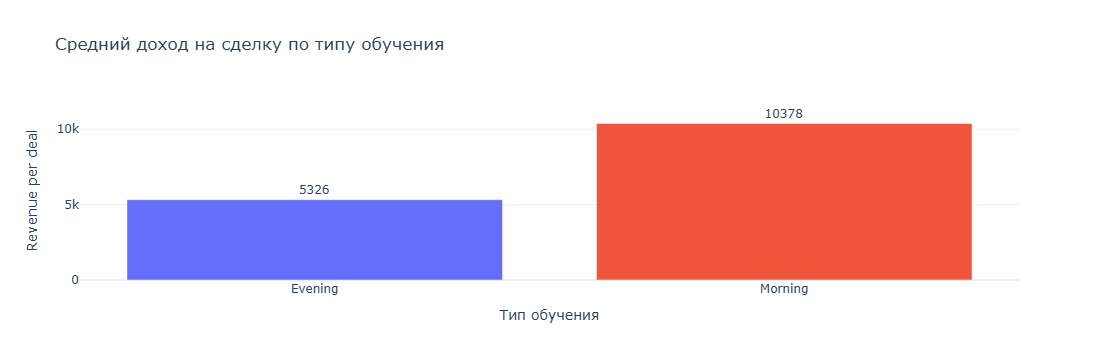

In [89]:
fig2 = px.bar(
    revenue_per_deal,
    x='Education_Type',
    y='revenue_per_deal',
    text=revenue_per_deal['revenue_per_deal'].round(0),
    color='Education_Type',
    title='Durchschnittlicher Umsatz pro Deal nach Bildungsform'
)

fig2.update_traces(
    textposition='outside',
    cliponaxis=False,
    textfont=dict(size=12)
)

# etwas Puffer oben hinzufügen
fig2.update_yaxes(
    range=[0, revenue_per_deal['revenue_per_deal'].max() * 1.15]
)

fig2.update_layout(
    xaxis_title='Bildungsform',
    yaxis_title='Umsatz pro Deal',
    template='plotly_white',
    showlegend=False
)

fig2.show()

In [ ]:
Wir analysieren die Beliebtheit und Erfolgsrate der verschiedenen Produkte.

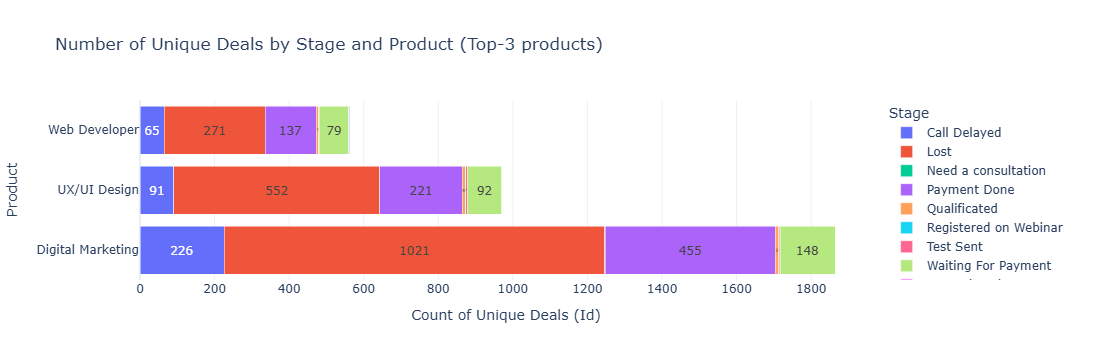

In [91]:
deals_copy = deals.copy()

# 1) Leere Produkte entfernen
deals_copy = deals_copy[deals_copy['Product'].notna()]
deals_copy = deals_copy[deals_copy['Product'].astype(str).str.strip() != '']

# 2) Text bereinigen
deals_copy['Product'] = deals_copy['Product'].astype(str).str.strip()

# 3) Spezialprodukte vor der Aggregation entfernen
special_products = ['Data Analytics', 'Find yourself in IT']
deals_copy = deals_copy[~deals_copy['Product'].isin(special_products)].copy()

# 4) Anzahl eindeutiger Ids pro Produkt × Stage zählen
stage_counts_long = (
    deals_copy
    .groupby(['Product', 'Stage'], as_index=False)
    .agg(unique_deals=('Id', 'nunique'))
)

# 5) Nur 3 Produkte auswählen (Top-3 nach Anzahl eindeutiger Deals)
top3_products = (
    stage_counts_long
    .groupby('Product', as_index=False)['unique_deals']
    .sum()
    .sort_values('unique_deals', ascending=False)
    .head(3)['Product']
    .tolist()
)

stage_counts_long = stage_counts_long[stage_counts_long['Product'].isin(top3_products)].copy()

# Reihenfolge auf der Achse (um das größte oben oder unten zu haben)
product_order = (
    stage_counts_long
    .groupby('Product', as_index=False)['unique_deals']
    .sum()
    .sort_values('unique_deals', ascending=True)['Product']
    .tolist()
)

# 6) Diagramm
fig = px.bar(
    stage_counts_long,
    x='unique_deals',
    y='Product',
    color='Stage',
    orientation='h',
    text='unique_deals',
    category_orders={'Product': product_order},
    title='Anzahl eindeutiger Deals nach Stage und Produkt (Top-3 Produkte)',
    template='plotly_white'
)

fig.update_traces(textposition='inside', insidetextanchor='middle')

fig.update_layout(
    xaxis_title='Anzahl eindeutiger Deals (Id)',
    yaxis_title='Produkt',
    barmode='stack',
    legend_title_text='Stage',
    height=450
)

fig.show()

               Product         Stage  unique_deals
0       Data Analytics          Lost             1
1  Find yourself in IT          Lost             3
2  Find yourself in IT  Payment Done             1


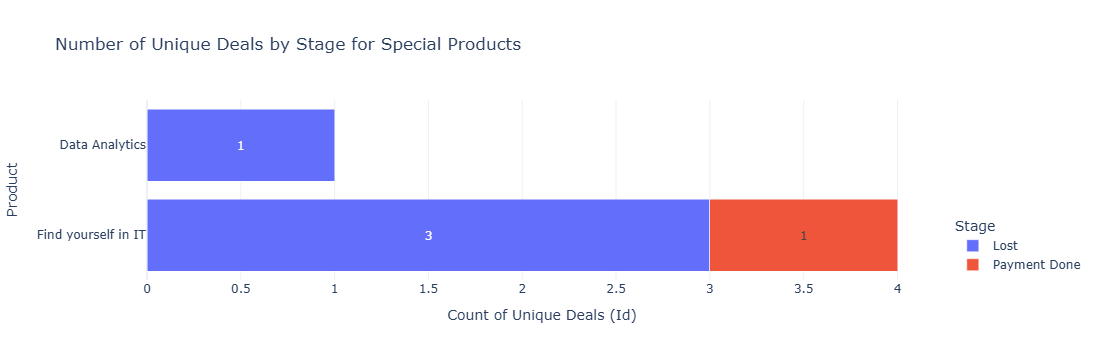

In [92]:
deals_copy = deals.copy()

# 1) Produktnamen bereinigen + leere Werte entfernen
deals_copy = deals_copy[deals_copy['Product'].notna()].copy()
deals_copy['Product'] = deals_copy['Product'].astype(str).str.strip()
deals_copy = deals_copy[deals_copy['Product'] != ''].copy()

# 2) Nur Spezialprodukte auswählen
special_products = ['Data Analytics', 'Find yourself in IT']
deals_special = deals_copy[deals_copy['Product'].isin(special_products)].copy()

# 3) Anzahl eindeutiger Ids pro Produkt × Stage zählen (Long-Format)
special_stage_counts_long = (
    deals_special
    .groupby(['Product', 'Stage'], as_index=False)
    .agg(unique_deals=('Id', 'nunique'))
)

print(special_stage_counts_long)

# 4) (Optional) Reihenfolge der Produkte
product_order = special_products

# 5) Plotly: horizontales gestapeltes Balkendiagramm + Beschriftungen
fig = px.bar(
    special_stage_counts_long,
    x='unique_deals',
    y='Product',
    color='Stage',
    orientation='h',
    text='unique_deals',
    category_orders={'Product': product_order},
    title='Anzahl eindeutiger Deals nach Stage für Spezialprodukte',
    template='plotly_white'
)

fig.update_traces(
    textposition='inside',
    insidetextanchor='middle'
)

fig.update_layout(
    xaxis_title='Anzahl eindeutiger Deals (Id)',
    yaxis_title='Produkt',
    barmode='stack',
    legend_title_text='Stage',
    legend=dict(
        x=1.02,
        y=0,
        xanchor='left',
        yanchor='bottom',
        orientation='v'
    ),
    height=450
)

fig.show()

Анализируем успешность в разрезе продуктов 

In [93]:
# 0) Basis der Käufe: Contact + Product
# =========================
purchases = deals.copy()

# Schlüssel normalisieren
purchases['Contact Name'] = purchases['Contact Name'].astype(str).str.strip()
purchases['Product'] = purchases['Product'].astype(str).str.strip()

# Falls Campaign/Source leer sind
purchases['Campaign'] = purchases['Campaign'].astype('string').fillna('Keine Kampagne')
purchases['Source'] = purchases['Source'].astype('string').fillna('Unbekannt')

# Aggregation zu einem "Kauf" pro Contact+Product
# Revenue = Summe der Zahlungen für diesen Kauf
purchases = (
    purchases
    .groupby(['Contact Name', 'Product'], as_index=False)
    .agg(
        Source=('Source', 'first'),
        Campaign=('Campaign', 'first'),
        Revenue=('Initial Amount Paid', 'sum')
    )
)

# =========================
# 1) Ausgaben (Spend) pro Kampagne
# =========================
campaign_spend = (
    spend
    .groupby(['Source', 'Campaign'], as_index=False)['Spend']
    .sum()
    .rename(columns={'Spend': 'Campaign_Spend'})
)

# =========================
# 2) Kampagnen-Umsatz (Campaign_Revenue) pro Kampagne (basierend auf Käufen)
# =========================
campaign_revenue = (
    purchases
    .groupby(['Source', 'Campaign'], as_index=False)['Revenue']
    .sum()
    .rename(columns={'Revenue': 'Campaign_Revenue'})
)

# =========================
# 3) Revenue + Spend auf Kampagnenebene zusammenführen
# =========================
campaigns = campaign_revenue.merge(campaign_spend, on=['Source', 'Campaign'], how='left')
campaigns['Campaign_Spend'] = campaigns['Campaign_Spend'].fillna(0)

# =========================
# 4) Kampagnen-Summen an Käufe anhängen
# =========================
purchases = purchases.merge(
    campaigns[['Source', 'Campaign', 'Campaign_Revenue', 'Campaign_Spend']],
    on=['Source', 'Campaign'],
    how='left'
)

purchases[['Campaign_Revenue', 'Campaign_Spend']] = purchases[['Campaign_Revenue', 'Campaign_Spend']].fillna(0)

# =========================
# 5) Marketing Spend proportional zum Umsatz des Kaufs verteilen
# =========================
purchases['Marketing_Spend_Allocated'] = np.where(
    purchases['Campaign_Revenue'] > 0,
    purchases['Campaign_Spend'] * (purchases['Revenue'] / purchases['Campaign_Revenue']),
    0
)

# =========================
# 6) Contribution Margin (Marketing Contribution)
# =========================
purchases['Contribution_Margin'] = purchases['Revenue'] - purchases['Marketing_Spend_Allocated']

# =========================
# 7) Zusammenfassung nach Produkt
# =========================
product_summary = (
    purchases
    .groupby('Product', as_index=False)
    .agg(
        Purchases=('Contact Name', 'count'),
        Revenue=('Revenue', 'sum'),
        Marketing_Spend=('Marketing_Spend_Allocated', 'sum'),
        Contribution_Margin=('Contribution_Margin', 'sum')
    )
)

# Runden und sortieren
product_summary[['Revenue','Marketing_Spend','Contribution_Margin']] = (
    product_summary[['Revenue','Marketing_Spend','Contribution_Margin']].round(2)
)

product_summary = product_summary.sort_values('Contribution_Margin', ascending=False)

# Nur gewünschte Produkte auswählen
target_products = [
    'Digital Marketing',
    'UX/UI Design',
    'Web Developer'
]

product_summary_filtered = (
    product_summary
    .query("Product in @target_products")
    .copy()
)

print(product_summary_filtered)

             Product  Purchases    Revenue  Marketing_Spend  \
1  Digital Marketing       1712  2192259.0         69799.63   
3       UX/UI Design        948  1173200.0         47288.28   
4      Web Developer        539   581150.0         27511.94   

   Contribution_Margin  
1           2122459.37  
3           1125911.72  
4            553638.06  


In [94]:
# Diagramme erstellen
target_products = ['Digital Marketing', 'UX/UI Design', 'Web Developer']

filtered_summary = (
    product_summary
    .query("Product in @target_products")
    .copy()
)

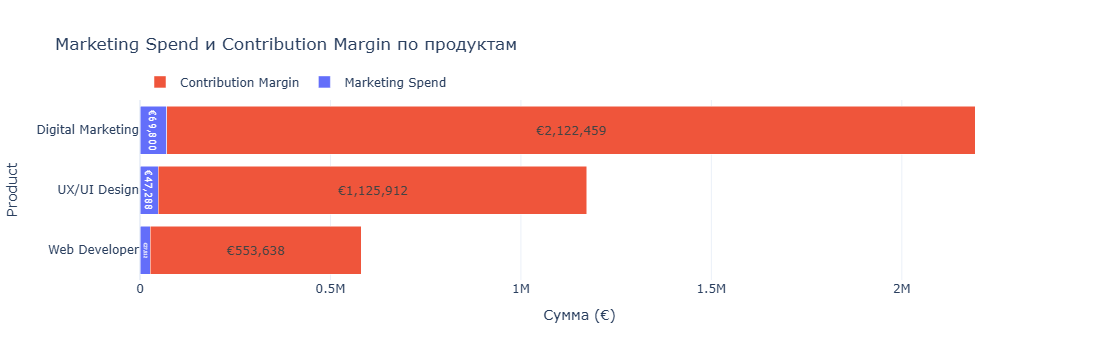

In [95]:
# Plotly: Gestapeltes Balkendiagramm (Marketing Spend + Contribution Margin)
bar_data = filtered_summary.sort_values('Contribution_Margin', ascending=True).copy()

fig_bar = go.Figure()

# Marketing Spend (linker Teil)
fig_bar.add_trace(
    go.Bar(
        y=bar_data['Product'],
        x=bar_data['Marketing_Spend'],
        name='Marketingausgaben',
        orientation='h',
        text=[f"€{v:,.0f}" for v in bar_data['Marketing_Spend']],
        textposition='inside',
        insidetextanchor='middle'
    )
)

# Contribution Margin (rechter Teil)
fig_bar.add_trace(
    go.Bar(
        y=bar_data['Product'],
        x=bar_data['Contribution_Margin'],
        name='Deckungsbeitrag',
        orientation='h',
        text=[f"€{v:,.0f}" for v in bar_data['Contribution_Margin']],
        textposition='inside',
        insidetextanchor='middle'
    )
)

fig_bar.update_layout(
    barmode='stack',
    title='Marketingausgaben und Deckungsbeitrag nach Produkt',
    xaxis_title='Summe (€)',
    yaxis_title='Produkt',
    template='plotly_white',
    height=450,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='left', x=0)
)

fig_bar.show()

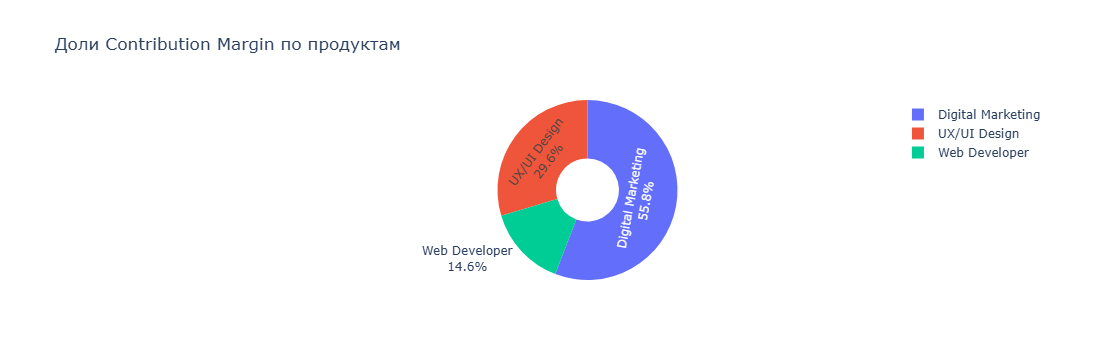

In [96]:
# Plotly: Kreisdiagramm — Anteile des Deckungsbeitrags nach Produkt
profit_data = filtered_summary[filtered_summary['Contribution_Margin'] > 0].copy()

fig_pie = px.pie(
    profit_data,
    names='Product',
    values='Contribution_Margin',
    title='Anteile des Deckungsbeitrags nach Produkt',
    hole=0.35,
    template='plotly_white'
)

fig_pie.update_traces(
    textinfo='percent+label'
)

fig_pie.show()